# AutoProspect AI

## Agentic Sales Intelligence Platform for Automotive Analytics Consulting

### INTTRVU AI Innovation Hackathon 2026

---

## Objective

AutoProspect AI is a multi-agent sales intelligence solution designed for XYZ Analytics Consulting.

The goal is to identify and prioritize the Top 10–15 Indian automotive companies that are the strongest prospects for XYZ Analytics Consulting's offerings:

1. Warranty Analytics  
2. Supply Chain Risk Prediction  
3. Dealer & Field Service Intelligence  

The solution uses an agentic workflow to perform market understanding, company research, pain signal detection, product-solution fit mapping, opportunity scoring, validation, and executive recommendation generation.

## Solution Approach

This notebook is designed as a complete end-to-end AI agent demonstration.

The workflow follows these stages:

1. Load product knowledge from XYZ Analytics Consulting's solution handbook.
2. Build a candidate universe of Indian automotive OEMs, Tier-1 suppliers, and component manufacturers.
3. Register the public data-source categories suggested in the hackathon problem statement.
4. Perform controlled live web research from public company websites and Google News RSS for evidence enrichment.
5. Run a multi-agent workflow:
   - Source Intelligence Agent
   - Live Web Research Agent
   - Evidence Enrichment Agent
   - Market Intelligence Agent
   - Company Discovery Agent
   - Company Research Agent
   - Pain Signal Detection Agent
   - Product Knowledge Agent
   - Solution Fit Agent
   - Opportunity Scoring Agent
   - Critic / Validation Agent
   - Executive Report Agent
   - GPT-4o mini Narrative Enhancement Agent
6. Generate a ranked opportunity pipeline.
7. Recommend the Top 10–15 target companies.
8. Use GPT-4o mini for LLM-powered executive narrative enhancement.
9. Export final reports, source evidence, recommendation cards, architecture diagram, and agent trace outputs.

The notebook uses deterministic scoring for explainability and GPT-4o mini for business narrative generation. API keys are handled only through Google Colab Secrets.


In [1]:
# ============================================================
# AutoProspect AI - Setup and Imports
# ============================================================

import os
import json
import textwrap
import datetime
from typing import Dict, List, Any, Optional

import pandas as pd
import numpy as np

from IPython.display import display, Markdown, HTML

print("AutoProspect AI setup completed successfully.")
print("Execution timestamp:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

AutoProspect AI setup completed successfully.
Execution timestamp: 2026-07-04 05:15:47


In [2]:
# ============================================================
# Global Configuration
# ============================================================
#
# Production note:
# - The notebook is Colab-first and can run end-to-end with no hardcoded secrets.
# - Live web research is enabled by default to prove public-source enrichment.
# - GPT-4o mini is enabled automatically only when OPENAI_API_KEY exists in
#   Google Colab Secrets. The LLM stage does not cache results; a fresh Run All
#   triggers fresh GPT-4o mini calls for the Top 15 companies.
# ============================================================

CONFIG = {
    "project_name": "AutoProspect AI",
    "hackathon": "INTTRVU AI Innovation Hackathon 2026",
    "client_company": "XYZ Analytics Consulting",
    "industry_focus": "Indian Automotive Industry",
    "target_company_count": 15,

    # DEMO mode keeps the notebook reviewer-friendly while still generating
    # all required artifacts. Live web research and LLM enhancement are controlled
    # through the flags below.
    "run_mode": "DEMO",

    # LLM configuration. This is switched to True in Section 9.5 only when
    # OPENAI_API_KEY is found in Colab Secrets.
    "use_llm": False,
    "llm_provider": "OpenAI",
    "model_name": "gpt-4o-mini",

    # Fresh-run proof. Keep True for final submission: each complete notebook run
    # will call GPT-4o mini again and capture request IDs plus token usage.
    "force_fresh_llm_run": True,

    # Controlled live web research settings. Official company websites and
    # Google News RSS are fetched with timeout and fallback handling so that
    # blocked websites do not break the notebook.
    "use_live_web_research": True,
    "live_research_company_limit": 27,
    "live_research_timeout_seconds": 8,
    "live_research_max_workers": 8,

    # Output folder inside the Colab runtime.
    "output_dir": "outputs"
}

CONFIG


{'project_name': 'AutoProspect AI',
 'hackathon': 'INTTRVU AI Innovation Hackathon 2026',
 'client_company': 'XYZ Analytics Consulting',
 'industry_focus': 'Indian Automotive Industry',
 'target_company_count': 15,
 'run_mode': 'DEMO',
 'use_llm': False,
 'llm_provider': 'OpenAI',
 'model_name': 'gpt-4o-mini',
 'force_fresh_llm_run': True,
 'use_live_web_research': True,
 'live_research_company_limit': 27,
 'live_research_timeout_seconds': 8,
 'live_research_max_workers': 8,
 'output_dir': 'outputs'}

In [3]:
# ============================================================
# Create Output Folder
# ============================================================

os.makedirs(CONFIG["output_dir"], exist_ok=True)

print(f"Output folder ready: {CONFIG['output_dir']}")

Output folder ready: outputs


## High-Level Agent Architecture

The final solution follows this controlled flow:

```text
Product Handbook
        ↓
Company Universe
        ↓
Public Source Register
        ↓
Live Web Research Agent
        ↓
Evidence Enrichment Agent
        ↓
Market Intelligence Agent
        ↓
Company Research Agent
        ↓
Pain Signal Detection Agent
        ↓
Solution Fit Agent
        ↓
Opportunity Scoring Agent
        ↓
Critic / Validation Agent
        ↓
Business Recommendation Card Agent
        ↓
GPT-4o mini Narrative Enhancement Agent
        ↓
Executive Report + Outputs
```

This design avoids a generic chatbot pattern and behaves like an autonomous pre-sales intelligence team with evidence collection, scoring, validation, and LLM-enhanced communication.


In [4]:
# ============================================================
# Notebook Health Check
# ============================================================

health_check = {
    "Notebook": "AutoProspect_AI_Hackathon.ipynb",
    "Environment": "Google Colab",
    "Run Mode": CONFIG["run_mode"],
    "LLM Enabled": CONFIG["use_llm"],
    "Model": CONFIG["model_name"],
    "Output Folder Exists": os.path.exists(CONFIG["output_dir"]),
    "Status": "Ready for product knowledge and data setup"
}

pd.DataFrame([health_check])

,Notebook,Environment,Run Mode,LLM Enabled,Model,Output Folder Exists,Status
0,AutoProspect_AI_Hackathon.ipynb,Google Colab,DEMO,False,gpt-4o-mini,True,Ready for product knowledge and data setup


## 4. Product Knowledge Design

XYZ Analytics Consulting provides automotive analytics solutions for the Indian automotive market.

Based on the Product & Solutions Handbook, the core offerings are:

1. Warranty Analytics
2. Supply Chain Risk Prediction
3. Dealer & Field Service Intelligence

This section converts the handbook content into structured product knowledge so that the AI agents can map customer business challenges to the most relevant consulting offering.

In [5]:
# ============================================================
# Product Knowledge Agent - Structured Solution Knowledge
# ============================================================

product_knowledge = {
    "Warranty Analytics": {
        "solution_name": "Warranty Analytics",
        "description": (
            "Warranty Analytics helps automotive companies detect product defects, "
            "analyze warranty claims, identify quality issues early, and reduce warranty cost exposure."
        ),
        "best_fit_segments": [
            "Automotive OEMs",
            "Commercial vehicle manufacturers",
            "Passenger vehicle manufacturers",
            "EV manufacturers",
            "Component manufacturers with field failure exposure"
        ],
        "pain_points": [
            "High warranty cost",
            "Recurring product defects",
            "Delayed defect detection",
            "Claim spikes",
            "Recall risk",
            "Quality leakage",
            "Field failure patterns",
            "High claim cycle time"
        ],
        "capabilities": [
            "Warranty claim trend analysis",
            "Defect pattern detection",
            "Time-series anomaly detection",
            "Clustering of failure symptoms",
            "Correlation of defects with supplier, plant, batch, or vehicle model",
            "Predictive early-warning alerts",
            "Root-cause focused warranty reporting"
        ],
        "kpis": [
            "Defects per 1,000 vehicles",
            "Mean Time Between Failures",
            "Warranty spend per unit",
            "Claim cycle time",
            "Recall incidence rate",
            "Cost avoidance"
        ],
        "business_value": [
            "Early defect detection before escalation",
            "Reduction in warranty cost",
            "Improved quality response",
            "Lower recall risk",
            "Better visibility into field performance"
        ],
        "typical_deliverables": [
            "Warranty trend reports",
            "BI dashboard for claims and defect heatmaps",
            "Automated alerts for claim spikes",
            "Predictive defect classification models"
        ],
        "sales_angle": (
            "Position this solution where the prospect has large vehicle volumes, "
            "complex product portfolios, EV transition, field quality issues, or high warranty exposure."
        )
    },

    "Supply Chain Risk Prediction": {
        "solution_name": "Supply Chain Risk Prediction",
        "description": (
            "Supply Chain Risk Prediction helps automotive companies monitor supplier health, "
            "logistics risk, inventory exposure, shipment delays, and production disruption risks."
        ),
        "best_fit_segments": [
            "Automotive OEMs",
            "Tier-1 suppliers",
            "Component manufacturers",
            "Battery manufacturers",
            "Export-oriented manufacturers",
            "Companies with multi-tier supplier networks"
        ],
        "pain_points": [
            "Supplier dependency",
            "Shipment delays",
            "Inventory shortage",
            "Production downtime",
            "Port or logistics disruption",
            "Raw material shortage",
            "Demand-supply mismatch",
            "Poor visibility across supplier network"
        ],
        "capabilities": [
            "Supplier risk scoring",
            "Graph-based supplier network analysis",
            "Shipment and logistics monitoring",
            "Inventory risk monitoring",
            "Lead-time forecasting",
            "External risk signal monitoring",
            "Production impact prediction"
        ],
        "kpis": [
            "Supplier risk score",
            "Parts availability",
            "Days of inventory",
            "Fill rate",
            "On-time in-full delivery rate",
            "Production downtime"
        ],
        "business_value": [
            "Reduced production disruption",
            "Improved supply chain visibility",
            "Lower logistics cost",
            "Better inventory planning",
            "Early warning for supplier or shipment risk"
        ],
        "typical_deliverables": [
            "Supply chain control tower",
            "Ranked list of at-risk suppliers and components",
            "Early-warning alerts",
            "Weekly risk summaries",
            "Lead-time forecasting models"
        ],
        "sales_angle": (
            "Position this solution where the prospect has large manufacturing operations, "
            "multi-tier suppliers, export exposure, EV component dependency, or high production continuity risk."
        )
    },

    "Dealer & Field Service Intelligence": {
        "solution_name": "Dealer & Field Service Intelligence",
        "description": (
            "Dealer & Field Service Intelligence helps automotive companies improve dealer performance, "
            "service operations, aftermarket revenue, customer experience, and field service planning."
        ),
        "best_fit_segments": [
            "Automotive OEMs",
            "Two-wheeler manufacturers",
            "Commercial vehicle manufacturers",
            "Passenger vehicle manufacturers",
            "Companies with large dealer or service networks"
        ],
        "pain_points": [
            "Inconsistent dealer performance",
            "Low showroom conversion",
            "Poor service visibility",
            "Repeat service visits",
            "Aftermarket revenue leakage",
            "Low warranty penetration",
            "Delayed field service response",
            "Customer satisfaction issues"
        ],
        "capabilities": [
            "Dealer performance dashboard",
            "Sales and service KPI analytics",
            "Dealer benchmarking",
            "Service demand forecasting",
            "Aftermarket revenue analytics",
            "Lead conversion analytics",
            "Technician workload and dispatch optimization"
        ],
        "kpis": [
            "Sales per dealer",
            "Showroom conversion rate",
            "Finance penetration",
            "Aftermarket revenue per vehicle",
            "Warranty penetration percentage",
            "Mean Time To Repair",
            "First-Time Fix Rate",
            "Customer Satisfaction Index"
        ],
        "business_value": [
            "Improved dealer performance",
            "Higher aftermarket revenue",
            "Better customer experience",
            "Improved service efficiency",
            "Better visibility across dealer network"
        ],
        "typical_deliverables": [
            "Network-wide dealer scorecards",
            "Location-level drill-down dashboards",
            "Automated alerts for dealer KPI drops",
            "Monthly dealer and field service reports",
            "Service demand forecasting models"
        ],
        "sales_angle": (
            "Position this solution where the prospect has a large dealer network, "
            "aftermarket revenue opportunity, service performance gaps, or customer experience challenges."
        )
    }
}

print(f"Loaded {len(product_knowledge)} XYZ Analytics Consulting solutions:")
for solution in product_knowledge:
    print(f"- {solution}")

Loaded 3 XYZ Analytics Consulting solutions:
- Warranty Analytics
- Supply Chain Risk Prediction
- Dealer & Field Service Intelligence


In [6]:
# ============================================================
# Display Product Knowledge Summary
# ============================================================

product_summary_rows = []

for solution_name, details in product_knowledge.items():
    product_summary_rows.append({
        "Solution": solution_name,
        "Best Fit Segments": ", ".join(details["best_fit_segments"][:3]),
        "Primary Pain Points": ", ".join(details["pain_points"][:4]),
        "Key KPIs": ", ".join(details["kpis"][:4]),
        "Business Value": ", ".join(details["business_value"][:3])
    })

product_knowledge_df = pd.DataFrame(product_summary_rows)
product_knowledge_df

,Solution,Best Fit Segments,Primary Pain Points,Key KPIs,Business Value
0,Warranty Analytics,"Automotive OEMs, Commercial vehicle manufactur...","High warranty cost, Recurring product defects,...","Defects per 1,000 vehicles, Mean Time Between ...","Early defect detection before escalation, Redu..."
1,Supply Chain Risk Prediction,"Automotive OEMs, Tier-1 suppliers, Component m...","Supplier dependency, Shipment delays, Inventor...","Supplier risk score, Parts availability, Days ...","Reduced production disruption, Improved supply..."
2,Dealer & Field Service Intelligence,"Automotive OEMs, Two-wheeler manufacturers, Co...","Inconsistent dealer performance, Low showroom ...","Sales per dealer, Showroom conversion rate, Fi...","Improved dealer performance, Higher aftermarke..."


In [7]:
# ============================================================
# Product Knowledge Validation
# ============================================================

required_fields = [
    "solution_name",
    "description",
    "best_fit_segments",
    "pain_points",
    "capabilities",
    "kpis",
    "business_value",
    "typical_deliverables",
    "sales_angle"
]

validation_results = []

for solution_name, details in product_knowledge.items():
    missing_fields = [field for field in required_fields if field not in details or not details[field]]

    validation_results.append({
        "Solution": solution_name,
        "Required Fields Present": len(missing_fields) == 0,
        "Missing Fields": ", ".join(missing_fields) if missing_fields else "None",
        "Pain Points Count": len(details.get("pain_points", [])),
        "Capabilities Count": len(details.get("capabilities", [])),
        "KPIs Count": len(details.get("kpis", []))
    })

product_validation_df = pd.DataFrame(validation_results)
product_validation_df

,Solution,Required Fields Present,Missing Fields,Pain Points Count,Capabilities Count,KPIs Count
0,Warranty Analytics,True,None,8,7,6
1,Supply Chain Risk Prediction,True,None,8,7,6
2,Dealer & Field Service Intelligence,True,None,8,7,8


In [8]:
# ============================================================
# Export Product Knowledge
# ============================================================

product_knowledge_path = os.path.join(CONFIG["output_dir"], "product_knowledge.json")

with open(product_knowledge_path, "w", encoding="utf-8") as f:
    json.dump(product_knowledge, f, indent=4, ensure_ascii=False)

print(f"Product knowledge exported successfully to: {product_knowledge_path}")

Product knowledge exported successfully to: outputs/product_knowledge.json


### Product Knowledge Design Notes

The Product Knowledge Agent uses the structured handbook-derived knowledge to ensure that recommendations are linked to XYZ Analytics Consulting's actual offerings.

This prevents generic AI recommendations and supports explainable solution mapping.

For every shortlisted company, downstream agents will use this product knowledge to decide:

- Which solution is most relevant
- Why the solution fits the company's business challenges
- What business value XYZ can offer
- Which KPIs and outcomes should be discussed in the sales conversation

## 5. Candidate Company Universe

This section creates a curated candidate universe of Indian automotive companies for the Sales Intelligence Agent.

The universe includes:

1. Automotive OEMs
2. Tier-1 suppliers
3. Automotive component manufacturers
4. EV / battery / aftermarket-relevant companies

The goal is not to directly hard-code the final answer. Instead, this list acts as the starting research universe. Downstream agents will analyze, score, validate, and rank these companies to identify the Top 10–15 prospects for XYZ Analytics Consulting.

In [9]:
# ============================================================
# Company Discovery Agent - Candidate Company Universe
# ============================================================

company_universe = [
    {
        "company_name": "Tata Motors",
        "segment": "OEM",
        "category": "Passenger Vehicles, Commercial Vehicles, EV",
        "website": "https://www.tatamotors.com",
        "business_notes": "Large Indian automotive OEM with passenger vehicles, commercial vehicles, EV portfolio, and broad market presence.",
        "products_services": ["Passenger vehicles", "Commercial vehicles", "Electric vehicles", "Fleet solutions"],
        "manufacturing_footprint": "Large multi-location manufacturing and service network in India.",
        "growth_signals": ["EV growth", "commercial vehicle scale", "large dealer and service network", "connected mobility focus"],
        "likely_data_assets": ["Warranty claims", "dealer service data", "vehicle telematics", "supplier data", "production data"],
        "initial_relevance_tags": ["warranty", "dealer_intelligence", "supply_chain", "ev"],
        "evidence_notes": "High vehicle volumes, EV expansion, and service network scale indicate strong analytics opportunity.",
        "source_categories": ["Company website", "SIAM", "Business news", "Financial portals"]
    },
    {
        "company_name": "Mahindra & Mahindra",
        "segment": "OEM",
        "category": "SUVs, Commercial Vehicles, Tractors, EV",
        "website": "https://www.mahindra.com",
        "business_notes": "Major Indian automotive and farm equipment company with SUVs, commercial vehicles, tractors, and EV initiatives.",
        "products_services": ["SUVs", "Commercial vehicles", "Tractors", "Electric mobility"],
        "manufacturing_footprint": "Large Indian manufacturing and dealer network across automotive and farm sectors.",
        "growth_signals": ["SUV demand", "EV initiatives", "tractor leadership", "rural and urban market spread"],
        "likely_data_assets": ["Warranty claims", "dealer sales data", "service data", "supplier data", "field performance data"],
        "initial_relevance_tags": ["dealer_intelligence", "warranty", "supply_chain", "ev"],
        "evidence_notes": "Diverse portfolio and dealer network complexity create strong opportunity for dealer and warranty analytics.",
        "source_categories": ["Company website", "SIAM", "Business news", "Financial portals"]
    },
    {
        "company_name": "Maruti Suzuki India",
        "segment": "OEM",
        "category": "Passenger Vehicles",
        "website": "https://www.marutisuzuki.com",
        "business_notes": "Leading passenger vehicle manufacturer in India with very large sales, service, and dealer footprint.",
        "products_services": ["Passenger cars", "CNG vehicles", "Hybrid-ready platforms", "After-sales service"],
        "manufacturing_footprint": "Large manufacturing and dealer/service network in India.",
        "growth_signals": ["high passenger vehicle volumes", "service network scale", "new model launches", "hybrid and CNG focus"],
        "likely_data_assets": ["Warranty claims", "dealer sales data", "service records", "customer satisfaction data"],
        "initial_relevance_tags": ["dealer_intelligence", "warranty", "aftermarket"],
        "evidence_notes": "High vehicle volumes and dealer/service scale make dealer intelligence and warranty analytics relevant.",
        "source_categories": ["Company website", "SIAM", "Business news", "Financial portals"]
    },
    {
        "company_name": "Ashok Leyland",
        "segment": "OEM",
        "category": "Commercial Vehicles, Buses, Trucks",
        "website": "https://www.ashokleyland.com",
        "business_notes": "Major commercial vehicle manufacturer with trucks, buses, fleet operations, and service network.",
        "products_services": ["Trucks", "Buses", "Light commercial vehicles", "Fleet services"],
        "manufacturing_footprint": "Commercial vehicle manufacturing and service footprint across India.",
        "growth_signals": ["commercial vehicle demand", "fleet uptime focus", "service network expansion", "supply chain dependency"],
        "likely_data_assets": ["Fleet service data", "warranty claims", "dealer service data", "supplier data"],
        "initial_relevance_tags": ["warranty", "dealer_intelligence", "supply_chain", "field_service"],
        "evidence_notes": "Commercial vehicle uptime and service quality make warranty and field service intelligence highly relevant.",
        "source_categories": ["Company website", "SIAM", "Business news", "Financial portals"]
    },
    {
        "company_name": "Bajaj Auto",
        "segment": "OEM",
        "category": "Two-Wheelers, Three-Wheelers, EV",
        "website": "https://www.bajajauto.com",
        "business_notes": "Major two-wheeler and three-wheeler manufacturer with domestic and export markets.",
        "products_services": ["Motorcycles", "Three-wheelers", "Electric scooters", "Exports"],
        "manufacturing_footprint": "Large manufacturing and distribution network with export exposure.",
        "growth_signals": ["EV two-wheeler growth", "export markets", "dealer network scale", "aftermarket opportunity"],
        "likely_data_assets": ["Dealer sales data", "service data", "warranty claims", "export logistics data"],
        "initial_relevance_tags": ["dealer_intelligence", "warranty", "supply_chain", "ev"],
        "evidence_notes": "High dealer scale and EV expansion create strong dealer and warranty analytics use cases.",
        "source_categories": ["Company website", "SIAM", "Business news", "Financial portals"]
    },
    {
        "company_name": "TVS Motor Company",
        "segment": "OEM",
        "category": "Two-Wheelers, Three-Wheelers, EV",
        "website": "https://www.tvsmotor.com",
        "business_notes": "Major two-wheeler and three-wheeler manufacturer with growing EV presence.",
        "products_services": ["Motorcycles", "Scooters", "Three-wheelers", "Electric scooters"],
        "manufacturing_footprint": "Manufacturing and dealer footprint across India and international markets.",
        "growth_signals": ["EV scooter growth", "premium two-wheeler focus", "dealer network expansion", "export presence"],
        "likely_data_assets": ["Dealer sales data", "service data", "warranty claims", "customer experience data"],
        "initial_relevance_tags": ["dealer_intelligence", "warranty", "ev", "aftermarket"],
        "evidence_notes": "EV and dealer network growth create opportunities for warranty and dealer intelligence.",
        "source_categories": ["Company website", "SIAM", "Business news", "Financial portals"]
    },
    {
        "company_name": "Hero MotoCorp",
        "segment": "OEM",
        "category": "Two-Wheelers, EV",
        "website": "https://www.heromotocorp.com",
        "business_notes": "Large two-wheeler manufacturer with extensive sales and service network.",
        "products_services": ["Motorcycles", "Scooters", "Electric mobility", "After-sales service"],
        "manufacturing_footprint": "Large manufacturing and dealer/service network in India.",
        "growth_signals": ["large two-wheeler volume", "EV mobility initiatives", "rural and urban dealer spread"],
        "likely_data_assets": ["Dealer sales data", "service records", "warranty claims", "customer satisfaction data"],
        "initial_relevance_tags": ["dealer_intelligence", "warranty", "aftermarket", "ev"],
        "evidence_notes": "Large dealer network and service base make dealer intelligence and warranty analytics relevant.",
        "source_categories": ["Company website", "SIAM", "Business news", "Financial portals"]
    },
    {
        "company_name": "Eicher Motors",
        "segment": "OEM",
        "category": "Motorcycles, Commercial Vehicles",
        "website": "https://www.eichermotors.com",
        "business_notes": "Automotive company associated with motorcycles and commercial vehicle operations through related business interests.",
        "products_services": ["Motorcycles", "Commercial vehicles", "After-sales service"],
        "manufacturing_footprint": "Manufacturing and dealer/service presence across India.",
        "growth_signals": ["premium motorcycle growth", "commercial vehicle operations", "service network scale"],
        "likely_data_assets": ["Dealer sales data", "service records", "warranty claims", "supplier data"],
        "initial_relevance_tags": ["dealer_intelligence", "warranty", "supply_chain"],
        "evidence_notes": "Premium products and service experience create opportunities for dealer and warranty analytics.",
        "source_categories": ["Company website", "SIAM", "Business news", "Financial portals"]
    },
    {
        "company_name": "Hyundai Motor India",
        "segment": "OEM",
        "category": "Passenger Vehicles, EV",
        "website": "https://www.hyundai.com/in",
        "business_notes": "Large passenger vehicle manufacturer in India with broad product range and dealer network.",
        "products_services": ["Passenger cars", "SUVs", "Electric vehicles", "After-sales service"],
        "manufacturing_footprint": "Major manufacturing and dealer/service network in India.",
        "growth_signals": ["SUV demand", "EV models", "large dealer network", "export orientation"],
        "likely_data_assets": ["Warranty claims", "dealer service data", "sales data", "customer experience data"],
        "initial_relevance_tags": ["dealer_intelligence", "warranty", "supply_chain", "ev"],
        "evidence_notes": "Passenger vehicle scale and EV portfolio indicate strong analytics potential.",
        "source_categories": ["Company website", "SIAM", "Business news", "Financial portals"]
    },
    {
        "company_name": "Toyota Kirloskar Motor",
        "segment": "OEM",
        "category": "Passenger Vehicles, Hybrid Vehicles",
        "website": "https://www.toyotabharat.com",
        "business_notes": "Passenger vehicle manufacturer in India with focus on quality, hybrid technology, and customer experience.",
        "products_services": ["Passenger vehicles", "Hybrid vehicles", "SUVs", "After-sales service"],
        "manufacturing_footprint": "Manufacturing and dealer/service network in India.",
        "growth_signals": ["hybrid adoption", "quality focus", "dealer service operations", "SUV demand"],
        "likely_data_assets": ["Warranty claims", "dealer service data", "customer satisfaction data", "supplier data"],
        "initial_relevance_tags": ["warranty", "dealer_intelligence", "quality"],
        "evidence_notes": "Quality, warranty, and dealer experience are strong analytical fit areas.",
        "source_categories": ["Company website", "SIAM", "Business news", "Financial portals"]
    },
    {
        "company_name": "Samvardhana Motherson International",
        "segment": "Tier-1 Supplier",
        "category": "Automotive Components, Wiring, Modules, Interiors",
        "website": "https://www.motherson.com",
        "business_notes": "Large automotive component supplier with global and Indian automotive customer base.",
        "products_services": ["Wiring harnesses", "Modules", "Interiors", "Mirrors", "Polymer components"],
        "manufacturing_footprint": "Large multi-location and global manufacturing footprint.",
        "growth_signals": ["global customer base", "multi-tier supply chain", "EV component opportunity", "supplier network complexity"],
        "likely_data_assets": ["Supplier data", "production data", "quality data", "shipment data", "customer order data"],
        "initial_relevance_tags": ["supply_chain", "quality", "warranty"],
        "evidence_notes": "Complex supplier and manufacturing network makes supply chain risk prediction highly relevant.",
        "source_categories": ["Company website", "ACMA", "Financial portals", "Business news"]
    },
    {
        "company_name": "Bosch India",
        "segment": "Tier-1 Supplier",
        "category": "Automotive Technology, Components, Mobility Solutions",
        "website": "https://www.bosch.in",
        "business_notes": "Automotive technology and mobility solutions supplier with broad component and systems portfolio.",
        "products_services": ["Automotive components", "Mobility solutions", "Electronics", "Aftermarket solutions"],
        "manufacturing_footprint": "Manufacturing, engineering, and service presence in India.",
        "growth_signals": ["mobility technology", "electronics", "aftermarket", "supply chain complexity"],
        "likely_data_assets": ["Quality data", "supplier data", "aftermarket data", "production data"],
        "initial_relevance_tags": ["supply_chain", "warranty", "aftermarket"],
        "evidence_notes": "Technology-heavy portfolio and aftermarket exposure create analytics opportunities.",
        "source_categories": ["Company website", "ACMA", "Financial portals", "Business news"]
    },
    {
        "company_name": "Bharat Forge",
        "segment": "Component Manufacturer",
        "category": "Forgings, Auto Components, Industrial Components",
        "website": "https://www.bharatforge.com",
        "business_notes": "Large forging and component manufacturer serving automotive and industrial sectors.",
        "products_services": ["Forged components", "Powertrain components", "Chassis components", "Industrial components"],
        "manufacturing_footprint": "Large manufacturing and export-oriented operations.",
        "growth_signals": ["export exposure", "EV component transition", "industrial diversification", "production complexity"],
        "likely_data_assets": ["Production data", "quality data", "supplier data", "shipment data"],
        "initial_relevance_tags": ["supply_chain", "quality", "production"],
        "evidence_notes": "Manufacturing scale and export exposure indicate supply chain and quality analytics fit.",
        "source_categories": ["Company website", "ACMA", "Financial portals", "Business news"]
    },
    {
        "company_name": "Uno Minda",
        "segment": "Tier-1 Supplier",
        "category": "Automotive Components, Electronics, Lighting, Switches",
        "website": "https://www.unominda.com",
        "business_notes": "Automotive component supplier with products across electronics, lighting, switches, and systems.",
        "products_services": ["Switches", "Lighting", "Acoustics", "Seating", "Electronics"],
        "manufacturing_footprint": "Multiple plants and supply relationships with OEMs.",
        "growth_signals": ["electronics growth", "EV components", "OEM dependency", "multi-product complexity"],
        "likely_data_assets": ["Supplier data", "quality data", "production data", "customer order data"],
        "initial_relevance_tags": ["supply_chain", "warranty", "quality", "ev"],
        "evidence_notes": "Multi-product portfolio and OEM supply relationships indicate strong supply chain analytics need.",
        "source_categories": ["Company website", "ACMA", "Financial portals", "Business news"]
    },
    {
        "company_name": "Sona BLW Precision Forgings",
        "segment": "Component Manufacturer",
        "category": "EV Components, Drivetrain, Precision Forgings",
        "website": "https://sonacomstar.com",
        "business_notes": "Automotive technology and component company with drivetrain and EV-related component focus.",
        "products_services": ["Differential gears", "Drivetrain components", "EV traction motor components", "Precision forgings"],
        "manufacturing_footprint": "Manufacturing and global automotive supply exposure.",
        "growth_signals": ["EV component growth", "global customers", "precision manufacturing", "quality requirements"],
        "likely_data_assets": ["Quality data", "production data", "supplier data", "customer delivery data"],
        "initial_relevance_tags": ["supply_chain", "quality", "ev", "warranty"],
        "evidence_notes": "EV component exposure and precision manufacturing create strong analytics relevance.",
        "source_categories": ["Company website", "ACMA", "Financial portals", "Business news"]
    },
    {
        "company_name": "Endurance Technologies",
        "segment": "Component Manufacturer",
        "category": "Auto Components, Aluminum Die Casting, Suspension, Braking",
        "website": "https://www.endurancegroup.com",
        "business_notes": "Automotive component manufacturer serving two-wheeler, three-wheeler, and four-wheeler segments.",
        "products_services": ["Aluminum die casting", "Suspension", "Transmission", "Braking systems"],
        "manufacturing_footprint": "Manufacturing footprint across India and overseas markets.",
        "growth_signals": ["two-wheeler component demand", "export exposure", "manufacturing scale", "quality focus"],
        "likely_data_assets": ["Production data", "quality data", "supplier data", "shipment data"],
        "initial_relevance_tags": ["supply_chain", "quality", "warranty"],
        "evidence_notes": "Manufacturing scale and OEM dependency create supply chain and quality analytics fit.",
        "source_categories": ["Company website", "ACMA", "Financial portals", "Business news"]
    },
    {
        "company_name": "Varroc Engineering",
        "segment": "Component Manufacturer",
        "category": "Automotive Lighting, Electronics, Polymer Components",
        "website": "https://www.varroc.com",
        "business_notes": "Automotive component supplier with lighting, electronics, and polymer solutions.",
        "products_services": ["Lighting systems", "Electronics", "Polymer components", "Electrical systems"],
        "manufacturing_footprint": "Manufacturing and supply footprint across automotive customers.",
        "growth_signals": ["automotive electronics", "lighting systems", "EV component relevance", "supplier complexity"],
        "likely_data_assets": ["Quality data", "production data", "supplier data", "customer order data"],
        "initial_relevance_tags": ["supply_chain", "quality", "warranty", "ev"],
        "evidence_notes": "Lighting/electronics complexity makes quality and supply chain analytics relevant.",
        "source_categories": ["Company website", "ACMA", "Financial portals", "Business news"]
    },
    {
        "company_name": "Amara Raja Energy & Mobility",
        "segment": "Component Manufacturer",
        "category": "Batteries, Energy Storage, Mobility",
        "website": "https://www.amararajaeandm.com",
        "business_notes": "Battery and energy storage company serving automotive and industrial markets.",
        "products_services": ["Automotive batteries", "Industrial batteries", "Energy storage", "Mobility solutions"],
        "manufacturing_footprint": "Battery manufacturing and distribution network in India.",
        "growth_signals": ["battery demand", "EV ecosystem", "aftermarket battery network", "energy storage growth"],
        "likely_data_assets": ["Warranty claims", "dealer/channel data", "production data", "supplier data"],
        "initial_relevance_tags": ["warranty", "supply_chain", "dealer_intelligence", "ev"],
        "evidence_notes": "Battery warranty, aftermarket channel, and EV ecosystem create strong analytics fit.",
        "source_categories": ["Company website", "ACMA", "Financial portals", "Business news"]
    },
    {
        "company_name": "Exide Industries",
        "segment": "Component Manufacturer",
        "category": "Automotive Batteries, Energy Storage",
        "website": "https://www.exideindustries.com",
        "business_notes": "Major battery manufacturer with automotive and industrial battery portfolio.",
        "products_services": ["Automotive batteries", "Industrial batteries", "Energy storage solutions", "Aftermarket channel"],
        "manufacturing_footprint": "Battery manufacturing and dealer/distribution network in India.",
        "growth_signals": ["battery replacement market", "EV ecosystem", "aftermarket network", "energy storage"],
        "likely_data_assets": ["Warranty claims", "dealer/channel data", "production data", "quality data"],
        "initial_relevance_tags": ["warranty", "dealer_intelligence", "supply_chain", "aftermarket"],
        "evidence_notes": "Warranty and aftermarket data make this a strong fit for warranty and channel intelligence.",
        "source_categories": ["Company website", "ACMA", "Financial portals", "Business news"]
    },
    {
        "company_name": "Minda Corporation",
        "segment": "Tier-1 Supplier",
        "category": "Automotive Components, Security Systems, Electronics",
        "website": "https://www.sparkminda.com",
        "business_notes": "Automotive component supplier with security systems, wiring, electronics, and component solutions.",
        "products_services": ["Locking systems", "Wiring harnesses", "Electronics", "Interior systems"],
        "manufacturing_footprint": "Manufacturing footprint and OEM supply relationships.",
        "growth_signals": ["electronics growth", "OEM dependency", "EV component opportunity", "quality requirements"],
        "likely_data_assets": ["Supplier data", "quality data", "production data", "customer order data"],
        "initial_relevance_tags": ["supply_chain", "quality", "warranty", "ev"],
        "evidence_notes": "Electronics and OEM supply relationships indicate analytics fit.",
        "source_categories": ["Company website", "ACMA", "Financial portals", "Business news"]
    },
    {
        "company_name": "JBM Auto",
        "segment": "OEM / Component Manufacturer",
        "category": "Electric Buses, Auto Components",
        "website": "https://www.jbmgroup.com",
        "business_notes": "Automotive company active in auto components and electric mobility including buses.",
        "products_services": ["Electric buses", "Auto components", "Systems", "Manufacturing solutions"],
        "manufacturing_footprint": "Manufacturing operations with EV and component relevance.",
        "growth_signals": ["electric bus growth", "public mobility", "component manufacturing", "supply chain needs"],
        "likely_data_assets": ["Fleet service data", "warranty claims", "production data", "supplier data"],
        "initial_relevance_tags": ["warranty", "supply_chain", "field_service", "ev"],
        "evidence_notes": "EV bus operations create field service, warranty, and supply chain analytics opportunities.",
        "source_categories": ["Company website", "ACMA", "Business news", "Financial portals"]
    },
    {
        "company_name": "Sundaram Clayton",
        "segment": "Component Manufacturer",
        "category": "Aluminum Die Casting, Auto Components",
        "website": "https://www.sundaramclayton.com",
        "business_notes": "Automotive component manufacturer focused on aluminum die-cast products.",
        "products_services": ["Aluminum die castings", "Machined components", "Automotive components"],
        "manufacturing_footprint": "Manufacturing operations serving automotive customers.",
        "growth_signals": ["lightweighting demand", "component manufacturing", "quality requirements", "OEM supply"],
        "likely_data_assets": ["Production data", "quality data", "supplier data", "customer order data"],
        "initial_relevance_tags": ["supply_chain", "quality", "warranty"],
        "evidence_notes": "Precision manufacturing and OEM supply make supply chain and quality analytics relevant.",
        "source_categories": ["Company website", "ACMA", "Financial portals", "Business news"]
    },
    {
        "company_name": "Gabriel India",
        "segment": "Component Manufacturer",
        "category": "Ride Control Products, Suspension",
        "website": "https://www.anandgroupindia.com/gabrielindia",
        "business_notes": "Automotive component manufacturer focused on ride control products and suspension systems.",
        "products_services": ["Shock absorbers", "Struts", "Front forks", "Suspension systems"],
        "manufacturing_footprint": "Manufacturing and supply network serving OEMs and aftermarket.",
        "growth_signals": ["aftermarket opportunity", "OEM supply", "quality requirements", "vehicle parc growth"],
        "likely_data_assets": ["Warranty claims", "aftermarket channel data", "quality data", "production data"],
        "initial_relevance_tags": ["warranty", "dealer_intelligence", "supply_chain", "aftermarket"],
        "evidence_notes": "Aftermarket and warranty exposure create strong analytics fit.",
        "source_categories": ["Company website", "ACMA", "Financial portals", "Business news"]
    },
    {
        "company_name": "MRF",
        "segment": "Component Manufacturer",
        "category": "Tyres, Rubber Products",
        "website": "https://www.mrftyres.com",
        "business_notes": "Major tyre manufacturer with OEM and aftermarket presence.",
        "products_services": ["Tyres", "Tubes", "Rubber products", "Aftermarket distribution"],
        "manufacturing_footprint": "Manufacturing and distribution network across India.",
        "growth_signals": ["aftermarket tyre demand", "OEM relationships", "quality and warranty exposure", "distribution scale"],
        "likely_data_assets": ["Warranty claims", "dealer/channel data", "production quality data", "distribution data"],
        "initial_relevance_tags": ["warranty", "dealer_intelligence", "aftermarket", "supply_chain"],
        "evidence_notes": "Large aftermarket and warranty exposure make dealer and warranty analytics relevant.",
        "source_categories": ["Company website", "ACMA", "Financial portals", "Business news"]
    },
    {
        "company_name": "CEAT",
        "segment": "Component Manufacturer",
        "category": "Tyres, Mobility Products",
        "website": "https://www.ceat.com",
        "business_notes": "Tyre manufacturer serving OEM and replacement markets.",
        "products_services": ["Tyres", "Mobility products", "Aftermarket distribution"],
        "manufacturing_footprint": "Manufacturing and dealer/distribution footprint in India.",
        "growth_signals": ["replacement market", "OEM supply", "distribution network", "quality and warranty exposure"],
        "likely_data_assets": ["Warranty claims", "dealer/channel data", "production quality data", "sales data"],
        "initial_relevance_tags": ["warranty", "dealer_intelligence", "aftermarket"],
        "evidence_notes": "Replacement market and dealer/channel network create opportunity for dealer and warranty analytics.",
        "source_categories": ["Company website", "ACMA", "Financial portals", "Business news"]
    },
    {
        "company_name": "Ola Electric",
        "segment": "EV OEM",
        "category": "Electric Two-Wheelers, EV Mobility",
        "website": "https://www.olaelectric.com",
        "business_notes": "Electric two-wheeler manufacturer focused on EV mobility.",
        "products_services": ["Electric scooters", "EV technology", "Charging ecosystem"],
        "manufacturing_footprint": "EV manufacturing and direct/customer support ecosystem.",
        "growth_signals": ["EV adoption", "battery and software complexity", "service quality importance", "supply chain dependency"],
        "likely_data_assets": ["Warranty claims", "battery performance data", "service data", "customer experience data"],
        "initial_relevance_tags": ["warranty", "dealer_intelligence", "ev", "field_service", "supply_chain"],
        "evidence_notes": "EV product complexity makes warranty, field service, and quality analytics highly relevant.",
        "source_categories": ["Company website", "Business news", "Financial portals"]
    },
    {
        "company_name": "Ather Energy",
        "segment": "EV OEM",
        "category": "Electric Two-Wheelers, Charging Ecosystem",
        "website": "https://www.atherenergy.com",
        "business_notes": "Electric two-wheeler company with connected scooter and charging ecosystem.",
        "products_services": ["Electric scooters", "Charging network", "Connected mobility services"],
        "manufacturing_footprint": "EV manufacturing and sales/service network in India.",
        "growth_signals": ["connected EV data", "charging ecosystem", "service experience", "battery analytics need"],
        "likely_data_assets": ["Battery data", "vehicle telemetry", "service records", "warranty claims"],
        "initial_relevance_tags": ["warranty", "dealer_intelligence", "ev", "field_service"],
        "evidence_notes": "Connected EV operations create strong data readiness for warranty and service intelligence.",
        "source_categories": ["Company website", "Business news", "Financial portals"]
    }
]

company_universe_df = pd.DataFrame(company_universe)

print(f"Candidate company universe created with {len(company_universe_df)} companies.")
company_universe_df.head()

Candidate company universe created with 27 companies.


,company_name,segment,category,website,business_notes,products_services,manufacturing_footprint,growth_signals,likely_data_assets,initial_relevance_tags,evidence_notes,source_categories
0,Tata Motors,OEM,"Passenger Vehicles, Commercial Vehicles, EV",https://www.tatamotors.com,Large Indian automotive OEM with passenger veh...,"[Passenger vehicles, Commercial vehicles, Elec...",Large multi-location manufacturing and service...,"[EV growth, commercial vehicle scale, large de...","[Warranty claims, dealer service data, vehicle...","[warranty, dealer_intelligence, supply_chain, ev]","High vehicle volumes, EV expansion, and servic...","[Company website, SIAM, Business news, Financi..."
1,Mahindra & Mahindra,OEM,"SUVs, Commercial Vehicles, Tractors, EV",https://www.mahindra.com,Major Indian automotive and farm equipment com...,"[SUVs, Commercial vehicles, Tractors, Electric...",Large Indian manufacturing and dealer network ...,"[SUV demand, EV initiatives, tractor leadershi...","[Warranty claims, dealer sales data, service d...","[dealer_intelligence, warranty, supply_chain, ev]",Diverse portfolio and dealer network complexit...,"[Company website, SIAM, Business news, Financi..."
2,Maruti Suzuki India,OEM,Passenger Vehicles,https://www.marutisuzuki.com,Leading passenger vehicle manufacturer in Indi...,"[Passenger cars, CNG vehicles, Hybrid-ready pl...",Large manufacturing and dealer/service network...,"[high passenger vehicle volumes, service netwo...","[Warranty claims, dealer sales data, service r...","[dealer_intelligence, warranty, aftermarket]",High vehicle volumes and dealer/service scale ...,"[Company website, SIAM, Business news, Financi..."
3,Ashok Leyland,OEM,"Commercial Vehicles, Buses, Trucks",https://www.ashokleyland.com,Major commercial vehicle manufacturer with tru...,"[Trucks, Buses, Light commercial vehicles, Fle...",Commercial vehicle manufacturing and service f...,"[commercial vehicle demand, fleet uptime focus...","[Fleet service data, warranty claims, dealer s...","[warranty, dealer_intelligence, supply_chain, ...",Commercial vehicle uptime and service quality ...,"[Company website, SIAM, Business news, Financi..."
4,Bajaj Auto,OEM,"Two-Wheelers, Three-Wheelers, EV",https://www.bajajauto.com,Major two-wheeler and three-wheeler manufactur...,"[Motorcycles, Three-wheelers, Electric scooter...",Large manufacturing and distribution network w...,"[EV two-wheeler growth, export markets, dealer...","[Dealer sales data, service data, warranty cla...","[dealer_intelligence, warranty, supply_chain, ev]",High dealer scale and EV expansion create stro...,"[Company website, SIAM, Business news, Financi..."


In [10]:
# ============================================================
# Display Candidate Company Universe Summary
# ============================================================

company_summary_df = company_universe_df[
    [
        "company_name",
        "segment",
        "category",
        "business_notes",
        "initial_relevance_tags"
    ]
].copy()

company_summary_df

,company_name,segment,category,business_notes,initial_relevance_tags
0,Tata Motors,OEM,"Passenger Vehicles, Commercial Vehicles, EV",Large Indian automotive OEM with passenger veh...,"[warranty, dealer_intelligence, supply_chain, ev]"
1,Mahindra & Mahindra,OEM,"SUVs, Commercial Vehicles, Tractors, EV",Major Indian automotive and farm equipment com...,"[dealer_intelligence, warranty, supply_chain, ev]"
2,Maruti Suzuki India,OEM,Passenger Vehicles,Leading passenger vehicle manufacturer in Indi...,"[dealer_intelligence, warranty, aftermarket]"
3,Ashok Leyland,OEM,"Commercial Vehicles, Buses, Trucks",Major commercial vehicle manufacturer with tru...,"[warranty, dealer_intelligence, supply_chain, ..."
4,Bajaj Auto,OEM,"Two-Wheelers, Three-Wheelers, EV",Major two-wheeler and three-wheeler manufactur...,"[dealer_intelligence, warranty, supply_chain, ev]"
5,TVS Motor Company,OEM,"Two-Wheelers, Three-Wheelers, EV",Major two-wheeler and three-wheeler manufactur...,"[dealer_intelligence, warranty, ev, aftermarket]"
6,Hero MotoCorp,OEM,"Two-Wheelers, EV",Large two-wheeler manufacturer with extensive ...,"[dealer_intelligence, warranty, aftermarket, ev]"
7,Eicher Motors,OEM,"Motorcycles, Commercial Vehicles",Automotive company associated with motorcycles...,"[dealer_intelligence, warranty, supply_chain]"
8,Hyundai Motor India,OEM,"Passenger Vehicles, EV",Large passenger vehicle manufacturer in India ...,"[dealer_intelligence, warranty, supply_chain, ev]"
9,Toyota Kirloskar Motor,OEM,"Passenger Vehicles, Hybrid Vehicles",Passenger vehicle manufacturer in India with f...,"[warranty, dealer_intelligence, quality]"


In [11]:
# ============================================================
# Company Universe Segment Distribution
# ============================================================

segment_distribution = (
    company_universe_df["segment"]
    .value_counts()
    .reset_index()
)

segment_distribution.columns = ["Segment", "Company Count"]
segment_distribution

,Segment,Company Count
0,OEM,10
1,Component Manufacturer,10
2,Tier-1 Supplier,4
3,EV OEM,2
4,OEM / Component Manufacturer,1


In [12]:
# ============================================================
# Company Universe Validation
# ============================================================

required_company_fields = [
    "company_name",
    "segment",
    "category",
    "website",
    "business_notes",
    "products_services",
    "manufacturing_footprint",
    "growth_signals",
    "likely_data_assets",
    "initial_relevance_tags",
    "evidence_notes",
    "source_categories"
]

company_validation_results = []

for idx, row in company_universe_df.iterrows():
    missing_fields = []

    for field in required_company_fields:
        value = row.get(field, None)
        if value is None:
            missing_fields.append(field)
        elif isinstance(value, str) and value.strip() == "":
            missing_fields.append(field)
        elif isinstance(value, list) and len(value) == 0:
            missing_fields.append(field)

    company_validation_results.append({
        "company_name": row["company_name"],
        "segment": row["segment"],
        "required_fields_present": len(missing_fields) == 0,
        "missing_fields": ", ".join(missing_fields) if missing_fields else "None",
        "tag_count": len(row["initial_relevance_tags"]),
        "source_category_count": len(row["source_categories"])
    })

company_validation_df = pd.DataFrame(company_validation_results)

validation_summary = {
    "total_companies": len(company_universe_df),
    "duplicate_company_count": company_universe_df["company_name"].duplicated().sum(),
    "companies_with_missing_fields": len(company_validation_df[company_validation_df["required_fields_present"] == False]),
    "minimum_required_for_final_ranking": CONFIG["target_company_count"],
    "universe_sufficient": len(company_universe_df) >= CONFIG["target_company_count"]
}

display(pd.DataFrame([validation_summary]))
display(company_validation_df)

,total_companies,duplicate_company_count,companies_with_missing_fields,minimum_required_for_final_ranking,universe_sufficient
0,27,0,0,15,True


,company_name,segment,required_fields_present,missing_fields,tag_count,source_category_count
0,Tata Motors,OEM,True,None,4,4
1,Mahindra & Mahindra,OEM,True,None,4,4
2,Maruti Suzuki India,OEM,True,None,3,4
3,Ashok Leyland,OEM,True,None,4,4
4,Bajaj Auto,OEM,True,None,4,4
5,TVS Motor Company,OEM,True,None,4,4
6,Hero MotoCorp,OEM,True,None,4,4
7,Eicher Motors,OEM,True,None,3,4
8,Hyundai Motor India,OEM,True,None,4,4
9,Toyota Kirloskar Motor,OEM,True,None,3,4


In [13]:
# ============================================================
# Export Company Universe
# ============================================================

os.makedirs(CONFIG["output_dir"], exist_ok=True)

company_universe_csv_path = os.path.join(CONFIG["output_dir"], "company_universe.csv")
company_universe_json_path = os.path.join(CONFIG["output_dir"], "company_universe.json")

# CSV export needs list fields converted to strings.
company_universe_export_df = company_universe_df.copy()

for col in ["products_services", "growth_signals", "likely_data_assets", "initial_relevance_tags", "source_categories"]:
    company_universe_export_df[col] = company_universe_export_df[col].apply(
        lambda x: "; ".join(x) if isinstance(x, list) else x
    )

company_universe_export_df.to_csv(company_universe_csv_path, index=False)

with open(company_universe_json_path, "w", encoding="utf-8") as f:
    json.dump(company_universe, f, indent=4, ensure_ascii=False)

print(f"Company universe CSV exported to: {company_universe_csv_path}")
print(f"Company universe JSON exported to: {company_universe_json_path}")

Company universe CSV exported to: outputs/company_universe.csv
Company universe JSON exported to: outputs/company_universe.json


### Company Universe Design Notes

The candidate company universe is intentionally broader than the final required Top 10–15 recommendation list.

This gives the downstream agents enough room to compare companies, detect stronger-fit prospects, reject weaker opportunities, and produce a ranked sales pipeline.

The universe includes companies from multiple automotive categories:

- Passenger vehicle OEMs
- Commercial vehicle OEMs
- Two-wheeler OEMs
- EV-focused companies
- Tier-1 suppliers
- Component manufacturers
- Battery and aftermarket-related companies

The final ranking will be generated through a transparent scoring model, not through manual selection.

## 5.5 Public Source Register and Live Web Research Foundation

This section adds the data-source layer required for a stronger hackathon solution.

The solution uses a hybrid research design:

- A curated candidate universe for reliable, reproducible execution.
- A public source register aligned with the hackathon-suggested data sources.
- Controlled live web research from official company websites and Google News RSS.
- Evidence enrichment that feeds downstream company research, pain detection, and sales recommendations.

Live scraping is intentionally controlled with timeout, error handling, and fallback logic so the notebook remains runnable in Google Colab.

In [14]:
# ============================================================
# Public Source Register
# ============================================================

public_data_sources = [
    {
        "source_name": "Official Company Websites",
        "source_type": "Company Information",
        "usage": "Company overview, products, manufacturing footprint, leadership announcements, investor information",
        "example_url": "Company-specific official website",
        "used_in_solution": "Yes - used for live website evidence enrichment"
    },
    {
        "source_name": "LinkedIn Company Pages",
        "source_type": "Company Information",
        "usage": "Company profile, employee strength, business updates, hiring signals",
        "example_url": "Company-specific LinkedIn page",
        "used_in_solution": "Mapped as recommended enrichment source; not scraped due to login and anti-bot restrictions"
    },
    {
        "source_name": "NSE India",
        "source_type": "Financial Information",
        "usage": "Listed company financial and market information validation",
        "example_url": "https://www.nseindia.com",
        "used_in_solution": "Mapped as financial validation source"
    },
    {
        "source_name": "BSE India",
        "source_type": "Financial Information",
        "usage": "Listed company financial and market information validation",
        "example_url": "https://www.bseindia.com",
        "used_in_solution": "Mapped as financial validation source"
    },
    {
        "source_name": "Moneycontrol",
        "source_type": "Financial Information",
        "usage": "Financial highlights, market profile, business news, stock/company research",
        "example_url": "https://www.moneycontrol.com",
        "used_in_solution": "Mapped as financial and business validation source"
    },
    {
        "source_name": "Screener",
        "source_type": "Financial Information",
        "usage": "Company financial ratios, filings, and listed company fundamentals",
        "example_url": "https://www.screener.in",
        "used_in_solution": "Mapped as financial validation source"
    },
    {
        "source_name": "IBEF",
        "source_type": "Industry Research",
        "usage": "Indian automotive industry context, sector growth, EV and market opportunity",
        "example_url": "https://www.ibef.org/industry/india-automobiles",
        "used_in_solution": "Mapped as industry research source"
    },
    {
        "source_name": "SIAM",
        "source_type": "Industry Research",
        "usage": "Automotive industry structure, OEM context, production and sector-level information",
        "example_url": "https://www.siam.in",
        "used_in_solution": "Mapped as automotive OEM industry source"
    },
    {
        "source_name": "ACMA",
        "source_type": "Industry Research",
        "usage": "Auto component industry context, component manufacturer ecosystem, supplier landscape",
        "example_url": "https://www.acma.in",
        "used_in_solution": "Mapped as component industry source"
    },
    {
        "source_name": "Economic Times Auto",
        "source_type": "Business News",
        "usage": "Automotive business news, growth initiatives, EV announcements, industry developments",
        "example_url": "https://auto.economictimes.indiatimes.com",
        "used_in_solution": "Mapped as business news validation source"
    },
    {
        "source_name": "Autocar Professional",
        "source_type": "Business News",
        "usage": "Automotive industry news, company expansion, production, EV, and supplier updates",
        "example_url": "https://www.autocarpro.in",
        "used_in_solution": "Mapped as business news validation source"
    },
    {
        "source_name": "Google News RSS",
        "source_type": "Business News",
        "usage": "Recent developments, trigger events, company announcements, and market signals",
        "example_url": "https://news.google.com/rss/search?q=<company>",
        "used_in_solution": "Yes - used for live news headline enrichment"
    },
    {
        "source_name": "XYZ Product & Solutions Handbook",
        "source_type": "Product Knowledge",
        "usage": "Warranty Analytics, Supply Chain Risk Prediction, Dealer & Field Service Intelligence solution mapping",
        "example_url": "Provided hackathon document",
        "used_in_solution": "Yes - used as structured product knowledge base"
    }
]

public_source_register_df = pd.DataFrame(public_data_sources)

print(f"Public source register created with {len(public_source_register_df)} source categories.")
display(public_source_register_df)

Public source register created with 13 source categories.


,source_name,source_type,usage,example_url,used_in_solution
0,Official Company Websites,Company Information,"Company overview, products, manufacturing foot...",Company-specific official website,Yes - used for live website evidence enrichment
1,LinkedIn Company Pages,Company Information,"Company profile, employee strength, business u...",Company-specific LinkedIn page,Mapped as recommended enrichment source; not s...
2,NSE India,Financial Information,Listed company financial and market informatio...,https://www.nseindia.com,Mapped as financial validation source
3,BSE India,Financial Information,Listed company financial and market informatio...,https://www.bseindia.com,Mapped as financial validation source
4,Moneycontrol,Financial Information,"Financial highlights, market profile, business...",https://www.moneycontrol.com,Mapped as financial and business validation so...
5,Screener,Financial Information,"Company financial ratios, filings, and listed ...",https://www.screener.in,Mapped as financial validation source
6,IBEF,Industry Research,"Indian automotive industry context, sector gro...",https://www.ibef.org/industry/india-automobiles,Mapped as industry research source
7,SIAM,Industry Research,"Automotive industry structure, OEM context, pr...",https://www.siam.in,Mapped as automotive OEM industry source
8,ACMA,Industry Research,"Auto component industry context, component man...",https://www.acma.in,Mapped as component industry source
9,Economic Times Auto,Business News,"Automotive business news, growth initiatives, ...",https://auto.economictimes.indiatimes.com,Mapped as business news validation source


In [15]:
# ============================================================
# Live Web Research Helper Functions
# ============================================================

import sys
import subprocess
import importlib.util
from urllib.parse import quote_plus
from concurrent.futures import ThreadPoolExecutor, as_completed
import xml.etree.ElementTree as ET

if importlib.util.find_spec("requests") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "requests"])

if importlib.util.find_spec("bs4") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "beautifulsoup4"])

import requests
from bs4 import BeautifulSoup

LIVE_EVIDENCE_KEYWORDS = [
    "ev", "electric", "battery", "warranty", "service", "dealer", "aftermarket",
    "supply chain", "supplier", "manufacturing", "quality", "recall", "export",
    "expansion", "production", "mobility", "connected", "charging", "customer",
    "commercial vehicle", "two-wheeler", "component"
]

def safe_text(value: Any, max_len: int = 500) -> str:
    """Convert value to safe compact text."""
    if value is None:
        return ""
    text = " ".join(str(value).split())
    return text[:max_len]


def extract_keywords_from_text(text: str, keywords: List[str] = LIVE_EVIDENCE_KEYWORDS) -> List[str]:
    """Extract evidence keywords present in text."""
    text_lower = text.lower()
    found = []
    for keyword in keywords:
        if keyword in text_lower:
            found.append(keyword)
    return sorted(set(found))


def fetch_official_website_evidence(company_name: str, website_url: str, timeout: int = 8) -> Dict[str, Any]:
    """
    Fetch official website evidence in a controlled way.
    This is intentionally lightweight and does not depend on dynamic browser rendering.
    """
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 "
            "(KHTML, like Gecko) Chrome/120.0 Safari/537.36 AutoProspectAI/1.0"
        )
    }

    result = {
        "company_name": company_name,
        "source_name": "Official Company Website",
        "source_url": website_url,
        "source_type": "Company Information",
        "fetch_status": "Not Attempted",
        "http_status": None,
        "page_title": "",
        "meta_description": "",
        "headings": "",
        "evidence_snippet": "",
        "evidence_keywords": [],
        "error": ""
    }

    try:
        response = requests.get(website_url, headers=headers, timeout=timeout, allow_redirects=True)
        result["http_status"] = response.status_code

        if response.status_code >= 400:
            result["fetch_status"] = "Failed"
            result["error"] = f"HTTP status {response.status_code}"
            return result

        soup = BeautifulSoup(response.text, "html.parser")

        for tag in soup(["script", "style", "noscript", "svg"]):
            tag.decompose()

        title = soup.title.get_text(" ", strip=True) if soup.title else ""

        meta_description = ""
        meta_tag = soup.find("meta", attrs={"name": "description"})
        if meta_tag and meta_tag.get("content"):
            meta_description = meta_tag.get("content", "")

        headings = []
        for tag_name in ["h1", "h2"]:
            for heading in soup.find_all(tag_name)[:8]:
                heading_text = safe_text(heading.get_text(" ", strip=True), 120)
                if heading_text:
                    headings.append(heading_text)

        paragraph_texts = []
        for para in soup.find_all(["p", "li"])[:30]:
            para_text = safe_text(para.get_text(" ", strip=True), 180)
            if para_text and len(para_text) > 20:
                paragraph_texts.append(para_text)

        combined_text = " ".join([title, meta_description] + headings + paragraph_texts)
        result.update({
            "fetch_status": "Success",
            "page_title": safe_text(title, 200),
            "meta_description": safe_text(meta_description, 350),
            "headings": " | ".join(headings[:8]),
            "evidence_snippet": safe_text(combined_text, 900),
            "evidence_keywords": extract_keywords_from_text(combined_text)
        })

    except Exception as exc:
        result["fetch_status"] = "Failed"
        result["error"] = str(exc)[:300]

    return result


def fetch_google_news_rss_evidence(company_name: str, timeout: int = 8, max_items: int = 5) -> Dict[str, Any]:
    """Fetch recent news headlines from Google News RSS for company-level trigger evidence."""
    query = quote_plus(f'"{company_name}" automotive India')
    rss_url = f"https://news.google.com/rss/search?q={query}&hl=en-IN&gl=IN&ceid=IN:en"

    result = {
        "company_name": company_name,
        "source_name": "Google News RSS",
        "source_url": rss_url,
        "source_type": "Business News",
        "fetch_status": "Not Attempted",
        "http_status": None,
        "page_title": "",
        "meta_description": "",
        "headings": "",
        "evidence_snippet": "",
        "evidence_keywords": [],
        "error": ""
    }

    try:
        response = requests.get(
            rss_url,
            headers={"User-Agent": "Mozilla/5.0 AutoProspectAI/1.0"},
            timeout=timeout
        )
        result["http_status"] = response.status_code

        if response.status_code >= 400:
            result["fetch_status"] = "Failed"
            result["error"] = f"HTTP status {response.status_code}"
            return result

        root = ET.fromstring(response.content)
        titles = []
        for item in root.findall(".//item")[:max_items]:
            title_elem = item.find("title")
            if title_elem is not None and title_elem.text:
                titles.append(safe_text(title_elem.text, 220))

        snippet = " | ".join(titles)

        result.update({
            "fetch_status": "Success" if titles else "No Headlines Found",
            "page_title": f"Google News RSS results for {company_name}",
            "headings": snippet,
            "evidence_snippet": snippet,
            "evidence_keywords": extract_keywords_from_text(snippet)
        })

    except Exception as exc:
        result["fetch_status"] = "Failed"
        result["error"] = str(exc)[:300]

    return result


def run_live_research_for_companies(company_df: pd.DataFrame, config: Dict[str, Any]) -> pd.DataFrame:
    """Run controlled live research for selected companies using official websites and Google News RSS."""
    if not config.get("use_live_web_research", True):
        return pd.DataFrame()

    limit = int(config.get("live_research_company_limit", len(company_df)))
    timeout = int(config.get("live_research_timeout_seconds", 8))
    max_workers = int(config.get("live_research_max_workers", 8))

    target_df = company_df.head(limit).copy()
    tasks = []

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        for _, row in target_df.iterrows():
            company_name = row["company_name"]
            website = row["website"]

            tasks.append(executor.submit(fetch_official_website_evidence, company_name, website, timeout))
            tasks.append(executor.submit(fetch_google_news_rss_evidence, company_name, timeout))

        results = []
        for future in as_completed(tasks):
            results.append(future.result())

    return pd.DataFrame(results)


print("Live web research helper functions loaded successfully.")

Live web research helper functions loaded successfully.


## 6. Agent Workflow Foundation

This section creates the controlled multi-agent workflow for AutoProspect AI.

The workflow now includes live evidence enrichment before the deterministic scoring and recommendation steps.

The design follows a structured agentic pattern:

1. Each agent has a clear role.
2. Each agent receives and updates a shared state.
3. Each agent produces structured output.
4. Each agent logs its reasoning trace.
5. The workflow is deterministic and reproducible in Google Colab.
6. Live web research is controlled through timeout, error handling, and fallback logic.

The core ranking does not depend only on an LLM. GPT-4o mini is used later for narrative enhancement.


In [16]:
# ============================================================
# Agent State and Trace Utilities
# ============================================================

def current_timestamp() -> str:
    """Return current timestamp as string."""
    return datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def create_initial_state() -> Dict[str, Any]:
    """Create shared state object for the multi-agent workflow."""
    return {
        "config": CONFIG,
        "product_knowledge": product_knowledge,
        "public_source_register_df": public_source_register_df.copy(),
        "company_universe_df": company_universe_df.copy(),
        "market_intelligence": {},
        "live_web_research_evidence_df": pd.DataFrame(),
        "web_scraping_status_report_df": pd.DataFrame(),
        "company_live_evidence_summary_df": pd.DataFrame(),
        "company_research_df": pd.DataFrame(),
        "pain_signal_df": pd.DataFrame(),
        "solution_fit_df": pd.DataFrame(),
        "agent_trace": [],
        "workflow_status": "Initialized"
    }


def add_agent_trace(
    state: Dict[str, Any],
    agent_name: str,
    action: str,
    input_summary: str,
    output_summary: str,
    status: str = "Completed"
) -> Dict[str, Any]:
    """Append an execution trace entry for explainability."""
    trace_entry = {
        "timestamp": current_timestamp(),
        "agent_name": agent_name,
        "action": action,
        "input_summary": input_summary,
        "output_summary": output_summary,
        "status": status
    }
    state["agent_trace"].append(trace_entry)
    return state


def list_to_text(value: Any) -> str:
    """Convert list or scalar value to readable text."""
    if isinstance(value, list):
        return ", ".join(value)
    return str(value)


agent_state = create_initial_state()

print("Agent state initialized successfully.")
print("Workflow status:", agent_state["workflow_status"])


Agent state initialized successfully.
Workflow status: Initialized


In [17]:
# ============================================================
# Source Intelligence, Live Web Research, and Evidence Enrichment Agents
# ============================================================

def source_intelligence_agent(state: Dict[str, Any]) -> Dict[str, Any]:
    """
    Source Intelligence Agent:
    Creates and validates the public source register aligned with hackathon guidance.
    """
    source_df = state.get("public_source_register_df", public_source_register_df.copy())

    state["public_source_register_df"] = source_df

    return add_agent_trace(
        state=state,
        agent_name="Source Intelligence Agent",
        action="Register public data sources and source usage model",
        input_summary="Hackathon-suggested public sources and product handbook source",
        output_summary=f"Registered {len(source_df)} source categories covering company, financial, industry, news, and product knowledge."
    )


def live_web_research_agent(state: Dict[str, Any]) -> Dict[str, Any]:
    """
    Live Web Research Agent:
    Fetches controlled public evidence from official company websites and Google News RSS.
    """
    company_df = state["company_universe_df"].copy()
    config = state["config"]

    if not config.get("use_live_web_research", True):
        live_df = pd.DataFrame()
        status_df = pd.DataFrame([{
            "source_name": "Live Web Research",
            "fetch_status": "Skipped",
            "details": "CONFIG['use_live_web_research'] is False"
        }])
    else:
        live_df = run_live_research_for_companies(company_df, config)

        if live_df.empty:
            status_df = pd.DataFrame([{
                "source_name": "Live Web Research",
                "fetch_status": "No Data",
                "details": "No live evidence rows generated"
            }])
        else:
            status_df = (
                live_df.groupby(["source_name", "fetch_status"])
                .size()
                .reset_index(name="row_count")
            )

    state["live_web_research_evidence_df"] = live_df
    state["web_scraping_status_report_df"] = status_df

    success_count = 0 if live_df.empty else int((live_df["fetch_status"] == "Success").sum())

    return add_agent_trace(
        state=state,
        agent_name="Live Web Research Agent",
        action="Fetch live public evidence from official websites and Google News RSS",
        input_summary=f"{len(company_df)} candidate companies with official website URLs",
        output_summary=f"Collected {len(live_df)} evidence rows with {success_count} successful live fetches."
    )


def summarize_live_evidence_for_company(company_name: str, evidence_df: pd.DataFrame) -> Dict[str, Any]:
    """Summarize live evidence for one company."""
    if evidence_df.empty:
        return {
            "company_name": company_name,
            "live_evidence_available": False,
            "successful_sources": 0,
            "evidence_keywords": [],
            "website_title": "",
            "news_headlines": "",
            "live_evidence_summary": "No live evidence available in current run."
        }

    rows = evidence_df[evidence_df["company_name"] == company_name].copy()
    success_rows = rows[rows["fetch_status"] == "Success"].copy()

    all_keywords = []
    for value in rows["evidence_keywords"].tolist():
        if isinstance(value, list):
            all_keywords.extend(value)

    website_rows = rows[rows["source_name"] == "Official Company Website"]
    news_rows = rows[rows["source_name"] == "Google News RSS"]

    website_title = ""
    if not website_rows.empty:
        website_title = website_rows.iloc[0].get("page_title", "")

    news_headlines = ""
    if not news_rows.empty:
        news_headlines = news_rows.iloc[0].get("headings", "")

    snippets = rows["evidence_snippet"].dropna().astype(str).tolist()
    summary_text = " ".join([safe_text(s, 500) for s in snippets if s.strip()])

    return {
        "company_name": company_name,
        "live_evidence_available": len(success_rows) > 0,
        "successful_sources": len(success_rows),
        "evidence_keywords": sorted(set(all_keywords)),
        "website_title": safe_text(website_title, 250),
        "news_headlines": safe_text(news_headlines, 700),
        "live_evidence_summary": safe_text(summary_text, 1200)
    }


def evidence_enrichment_agent(state: Dict[str, Any]) -> Dict[str, Any]:
    """
    Evidence Enrichment Agent:
    Summarizes live evidence and enriches company profiles before downstream analysis.
    """
    company_df = state["company_universe_df"].copy()
    live_df = state.get("live_web_research_evidence_df", pd.DataFrame())

    summary_rows = []
    for _, row in company_df.iterrows():
        summary_rows.append(summarize_live_evidence_for_company(row["company_name"], live_df))

    evidence_summary_df = pd.DataFrame(summary_rows)

    enriched_company_df = company_df.merge(
        evidence_summary_df[["company_name", "evidence_keywords", "live_evidence_summary", "news_headlines"]],
        on="company_name",
        how="left"
    )

    def enrich_evidence_notes(row: pd.Series) -> str:
        base_notes = str(row.get("evidence_notes", ""))
        keywords = row.get("evidence_keywords", [])
        live_summary = str(row.get("live_evidence_summary", ""))
        news_headlines = str(row.get("news_headlines", ""))

        keyword_text = ", ".join(keywords) if isinstance(keywords, list) else str(keywords)

        enrichment_parts = []
        if keyword_text:
            enrichment_parts.append(f"Live evidence keywords: {keyword_text}.")
        if news_headlines:
            enrichment_parts.append(f"Recent news evidence: {safe_text(news_headlines, 400)}.")
        if live_summary and live_summary != "No live evidence available in current run.":
            enrichment_parts.append(f"Live web summary: {safe_text(live_summary, 400)}.")

        return " ".join([base_notes] + enrichment_parts).strip()

    enriched_company_df["evidence_notes"] = enriched_company_df.apply(enrich_evidence_notes, axis=1)

    state["company_live_evidence_summary_df"] = evidence_summary_df
    state["company_universe_df"] = enriched_company_df

    evidence_available_count = int(evidence_summary_df["live_evidence_available"].sum()) if not evidence_summary_df.empty else 0

    return add_agent_trace(
        state=state,
        agent_name="Evidence Enrichment Agent",
        action="Summarize live evidence and enrich company profiles",
        input_summary=f"{len(live_df)} live evidence rows",
        output_summary=f"Created evidence summaries for {len(evidence_summary_df)} companies; live evidence available for {evidence_available_count} companies."
    )

In [18]:
# ============================================================
# Core Agents - Market, Product, and Company Discovery
# ============================================================

def market_intelligence_agent(state: Dict[str, Any]) -> Dict[str, Any]:
    """
    Market Intelligence Agent:
    Identifies industry pressures and opportunity themes relevant to XYZ's offerings.
    """

    market_intelligence = {
        "industry": "Indian Automotive Industry",
        "target_segments": [
            "Automotive OEMs",
            "Tier-1 Suppliers",
            "Component Manufacturers",
            "EV-focused manufacturers",
            "Aftermarket-focused companies"
        ],
        "market_pressures": [
            "Warranty cost pressure",
            "EV transition complexity",
            "Supply chain disruption risk",
            "Dealer and service network inconsistency",
            "Aftermarket growth opportunity",
            "Quality and recall exposure",
            "Need for predictive analytics rather than reactive reporting"
        ],
        "opportunity_themes": [
            "Quality and warranty intelligence",
            "Supplier and logistics risk prediction",
            "Dealer performance optimization",
            "Field service improvement",
            "EV battery and component reliability analytics",
            "Aftermarket revenue intelligence"
        ],
        "relevance_to_xyz": (
            "XYZ Analytics Consulting can address these pressures through Warranty Analytics, "
            "Supply Chain Risk Prediction, and Dealer & Field Service Intelligence."
        )
    }

    state["market_intelligence"] = market_intelligence

    return add_agent_trace(
        state=state,
        agent_name="Market Intelligence Agent",
        action="Analyze industry context and opportunity themes",
        input_summary="Indian automotive market context and XYZ product offerings",
        output_summary=f"Identified {len(market_intelligence['market_pressures'])} market pressures and {len(market_intelligence['opportunity_themes'])} opportunity themes."
    )


def product_knowledge_agent(state: Dict[str, Any]) -> Dict[str, Any]:
    """
    Product Knowledge Agent:
    Validates and summarizes XYZ Analytics Consulting's solution knowledge.
    """

    product_knowledge = state["product_knowledge"]

    product_summary = []
    for solution_name, details in product_knowledge.items():
        product_summary.append({
            "solution_name": solution_name,
            "pain_point_count": len(details.get("pain_points", [])),
            "capability_count": len(details.get("capabilities", [])),
            "kpi_count": len(details.get("kpis", [])),
            "best_fit_segments": details.get("best_fit_segments", [])
        })

    state["product_summary_df"] = pd.DataFrame(product_summary)

    return add_agent_trace(
        state=state,
        agent_name="Product Knowledge Agent",
        action="Validate and summarize XYZ consulting offerings",
        input_summary="Structured product knowledge from XYZ handbook",
        output_summary=f"Validated {len(product_knowledge)} consulting offerings."
    )


def company_discovery_agent(state: Dict[str, Any]) -> Dict[str, Any]:
    """
    Company Discovery Agent:
    Reviews the candidate universe and prepares it for downstream research.
    """

    company_df = state["company_universe_df"].copy()

    discovery_summary = {
        "candidate_company_count": len(company_df),
        "unique_segments": sorted(company_df["segment"].unique().tolist()),
        "segment_distribution": company_df["segment"].value_counts().to_dict()
    }

    state["company_discovery_summary"] = discovery_summary

    return add_agent_trace(
        state=state,
        agent_name="Company Discovery Agent",
        action="Prepare candidate company universe",
        input_summary=f"{len(company_df)} candidate companies",
        output_summary=f"Prepared {discovery_summary['candidate_company_count']} companies across {len(discovery_summary['unique_segments'])} segments."
    )

In [19]:
# ============================================================
# Core Agents - Research, Pain Signal Detection, and Solution Fit
# ============================================================

def company_research_agent(state: Dict[str, Any]) -> Dict[str, Any]:
    """
    Company Research Agent:
    Converts the enriched candidate universe into structured company intelligence.
    """

    company_df = state["company_universe_df"].copy()
    evidence_summary_df = state.get("company_live_evidence_summary_df", pd.DataFrame())

    research_rows = []

    for _, row in company_df.iterrows():
        evidence_row = evidence_summary_df[
            evidence_summary_df["company_name"] == row["company_name"]
        ]

        live_evidence_summary = ""
        recent_news_headlines = ""
        live_evidence_keywords = []

        if not evidence_row.empty:
            live_evidence_summary = evidence_row.iloc[0].get("live_evidence_summary", "")
            recent_news_headlines = evidence_row.iloc[0].get("news_headlines", "")
            live_evidence_keywords = evidence_row.iloc[0].get("evidence_keywords", [])

        research_rows.append({
            "company_name": row["company_name"],
            "segment": row["segment"],
            "category": row["category"],
            "company_overview": row["business_notes"],
            "products_services": row["products_services"],
            "manufacturing_footprint": row["manufacturing_footprint"],
            "growth_signals": row["growth_signals"],
            "likely_data_assets": row["likely_data_assets"],
            "evidence_notes": row["evidence_notes"],
            "source_categories": row["source_categories"],
            "live_evidence_keywords": live_evidence_keywords,
            "live_evidence_summary": live_evidence_summary,
            "recent_news_headlines": recent_news_headlines,
            "research_summary": (
                f"{row['company_name']} is categorized as {row['segment']} with relevance in "
                f"{row['category']}. Key growth signals include {list_to_text(row['growth_signals'])}. "
                f"Likely useful data assets include {list_to_text(row['likely_data_assets'])}. "
                f"Live evidence keywords include {list_to_text(live_evidence_keywords)}."
            )
        })

    research_df = pd.DataFrame(research_rows)
    state["company_research_df"] = research_df

    return add_agent_trace(
        state=state,
        agent_name="Company Research Agent",
        action="Create structured company intelligence with live evidence enrichment",
        input_summary=f"{len(company_df)} enriched companies from candidate universe",
        output_summary=f"Generated research profiles for {len(research_df)} companies."
    )

def signal_level(score: int) -> str:
    """Convert numeric signal score into High / Medium / Low."""
    if score >= 4:
        return "High"
    if score >= 2:
        return "Medium"
    return "Low"


def pain_signal_detection_agent(state: Dict[str, Any]) -> Dict[str, Any]:
    """
    Pain Signal Detection Agent:
    Detects business pain signals using tags, segment, category, and growth signals.
    """

    company_df = state["company_universe_df"].copy()
    pain_rows = []

    for _, row in company_df.iterrows():
        tags = [tag.lower() for tag in row["initial_relevance_tags"]]
        growth_text = " ".join(row["growth_signals"]).lower()
        category_text = row["category"].lower()
        segment_text = row["segment"].lower()
        notes_text = row["evidence_notes"].lower()

        warranty_score = 0
        supply_chain_score = 0
        dealer_score = 0
        ev_score = 0
        aftermarket_score = 0

        # Warranty signals
        if "warranty" in tags:
            warranty_score += 2
        if "quality" in tags:
            warranty_score += 1
        if "ev" in tags or "ev" in category_text or "battery" in category_text:
            warranty_score += 1
        if "field_service" in tags:
            warranty_score += 1

        # Supply chain signals
        if "supply_chain" in tags:
            supply_chain_score += 2
        if "tier-1" in segment_text or "component" in segment_text:
            supply_chain_score += 1
        if "export" in growth_text or "supplier" in notes_text or "manufacturing" in notes_text:
            supply_chain_score += 1
        if "ev" in tags:
            supply_chain_score += 1

        # Dealer / field service signals
        if "dealer_intelligence" in tags:
            dealer_score += 2
        if "aftermarket" in tags:
            dealer_score += 1
        if "field_service" in tags:
            dealer_score += 1
        if "oem" in segment_text:
            dealer_score += 1

        # EV complexity signals
        if "ev" in tags or "ev" in category_text or "electric" in category_text:
            ev_score += 2
        if "battery" in growth_text or "charging" in growth_text:
            ev_score += 1
        if "connected" in growth_text:
            ev_score += 1

        # Aftermarket opportunity signals
        if "aftermarket" in tags:
            aftermarket_score += 2
        if "dealer_intelligence" in tags:
            aftermarket_score += 1
        if "tyre" in category_text or "battery" in category_text or "service" in notes_text:
            aftermarket_score += 1

        pain_rows.append({
            "company_name": row["company_name"],
            "segment": row["segment"],
            "warranty_complexity": signal_level(warranty_score),
            "supply_chain_complexity": signal_level(supply_chain_score),
            "dealer_service_complexity": signal_level(dealer_score),
            "ev_transition_complexity": signal_level(ev_score),
            "aftermarket_opportunity": signal_level(aftermarket_score),
            "warranty_signal_score": warranty_score,
            "supply_chain_signal_score": supply_chain_score,
            "dealer_signal_score": dealer_score,
            "ev_signal_score": ev_score,
            "aftermarket_signal_score": aftermarket_score
        })

    pain_signal_df = pd.DataFrame(pain_rows)
    state["pain_signal_df"] = pain_signal_df

    return add_agent_trace(
        state=state,
        agent_name="Pain Signal Detection Agent",
        action="Detect business pain signals",
        input_summary=f"{len(company_df)} company profiles with tags and evidence notes",
        output_summary=f"Generated pain signal profile for {len(pain_signal_df)} companies."
    )


def solution_fit_agent(state: Dict[str, Any]) -> Dict[str, Any]:
    """
    Solution Fit Agent:
    Maps detected pain signals to XYZ Analytics Consulting offerings.
    """

    pain_df = state["pain_signal_df"].copy()
    company_df = state["company_universe_df"].copy()

    merged_df = pain_df.merge(
        company_df[["company_name", "initial_relevance_tags", "growth_signals", "evidence_notes"]],
        on="company_name",
        how="left"
    )

    solution_rows = []

    for _, row in merged_df.iterrows():
        solution_scores = {
            "Warranty Analytics": 0,
            "Supply Chain Risk Prediction": 0,
            "Dealer & Field Service Intelligence": 0
        }

        # Warranty Analytics fit
        solution_scores["Warranty Analytics"] += row["warranty_signal_score"] * 2
        solution_scores["Warranty Analytics"] += row["ev_signal_score"]

        # Supply Chain Risk Prediction fit
        solution_scores["Supply Chain Risk Prediction"] += row["supply_chain_signal_score"] * 2
        solution_scores["Supply Chain Risk Prediction"] += row["ev_signal_score"]

        # Dealer & Field Service Intelligence fit
        solution_scores["Dealer & Field Service Intelligence"] += row["dealer_signal_score"] * 2
        solution_scores["Dealer & Field Service Intelligence"] += row["aftermarket_signal_score"]

        ranked_solutions = sorted(solution_scores.items(), key=lambda x: x[1], reverse=True)

        primary_solution = ranked_solutions[0][0]
        secondary_solution = ranked_solutions[1][0]

        fit_reason = (
            f"{row['company_name']} shows {row['warranty_complexity']} warranty complexity, "
            f"{row['supply_chain_complexity']} supply chain complexity, "
            f"{row['dealer_service_complexity']} dealer/service complexity, "
            f"{row['ev_transition_complexity']} EV transition complexity, and "
            f"{row['aftermarket_opportunity']} aftermarket opportunity."
        )

        solution_rows.append({
            "company_name": row["company_name"],
            "segment": row["segment"],
            "primary_solution": primary_solution,
            "secondary_solution": secondary_solution,
            "warranty_solution_fit_score": solution_scores["Warranty Analytics"],
            "supply_chain_solution_fit_score": solution_scores["Supply Chain Risk Prediction"],
            "dealer_solution_fit_score": solution_scores["Dealer & Field Service Intelligence"],
            "fit_reason": fit_reason,
            "evidence_notes": row["evidence_notes"]
        })

    solution_fit_df = pd.DataFrame(solution_rows)
    state["solution_fit_df"] = solution_fit_df

    return add_agent_trace(
        state=state,
        agent_name="Solution Fit Agent",
        action="Map pain signals to XYZ consulting offerings",
        input_summary=f"{len(pain_df)} pain signal profiles and structured product knowledge",
        output_summary=f"Generated solution-fit mapping for {len(solution_fit_df)} companies."
    )


In [20]:
# ============================================================
# Agent Workflow Orchestrator
# ============================================================

def run_agentic_workflow() -> Dict[str, Any]:
    """
    Run the controlled multi-agent workflow end-to-end.

    Final flow:
    Product Handbook -> Company Universe -> Public Source Register ->
    Live Web Research Agent -> Evidence Enrichment Agent ->
    Market Intelligence Agent -> Company Research Agent ->
    Pain Signal Detection Agent -> Solution Fit Agent.
    """

    state = create_initial_state()
    state["workflow_status"] = "Running"

    workflow_agents = [
        source_intelligence_agent,
        live_web_research_agent,
        evidence_enrichment_agent,
        market_intelligence_agent,
        product_knowledge_agent,
        company_discovery_agent,
        company_research_agent,
        pain_signal_detection_agent,
        solution_fit_agent
    ]

    for agent in workflow_agents:
        state = agent(state)

    state["workflow_status"] = "Completed"

    return state


agent_state = run_agentic_workflow()

print("Agentic workflow completed successfully.")
print("Workflow status:", agent_state["workflow_status"])
print("Agents executed:", len(agent_state["agent_trace"]))


Agentic workflow completed successfully.
Workflow status: Completed
Agents executed: 9


In [21]:
# ============================================================
# Display Agent Execution Trace
# ============================================================

agent_trace_df = pd.DataFrame(agent_state["agent_trace"])
agent_trace_df

,timestamp,agent_name,action,input_summary,output_summary,status
0,2026-07-04 05:15:50,Source Intelligence Agent,Register public data sources and source usage ...,Hackathon-suggested public sources and product...,Registered 13 source categories covering compa...,Completed
1,2026-07-04 05:16:01,Live Web Research Agent,Fetch live public evidence from official websi...,27 candidate companies with official website URLs,Collected 54 evidence rows with 50 successful ...,Completed
2,2026-07-04 05:16:02,Evidence Enrichment Agent,Summarize live evidence and enrich company pro...,54 live evidence rows,Created evidence summaries for 27 companies; l...,Completed
3,2026-07-04 05:16:02,Market Intelligence Agent,Analyze industry context and opportunity themes,Indian automotive market context and XYZ produ...,Identified 7 market pressures and 6 opportunit...,Completed
4,2026-07-04 05:16:02,Product Knowledge Agent,Validate and summarize XYZ consulting offerings,Structured product knowledge from XYZ handbook,Validated 3 consulting offerings.,Completed
5,2026-07-04 05:16:02,Company Discovery Agent,Prepare candidate company universe,27 candidate companies,Prepared 27 companies across 5 segments.,Completed
6,2026-07-04 05:16:02,Company Research Agent,Create structured company intelligence with li...,27 enriched companies from candidate universe,Generated research profiles for 27 companies.,Completed
7,2026-07-04 05:16:02,Pain Signal Detection Agent,Detect business pain signals,27 company profiles with tags and evidence notes,Generated pain signal profile for 27 companies.,Completed
8,2026-07-04 05:16:02,Solution Fit Agent,Map pain signals to XYZ consulting offerings,27 pain signal profiles and structured product...,Generated solution-fit mapping for 27 companies.,Completed


In [22]:
# ============================================================
# Display Live Evidence, Pain Signal, and Solution Fit Preview
# ============================================================

print("Live Web Research Status")
display(agent_state["web_scraping_status_report_df"])

print("\nCompany Live Evidence Summary Preview")
display(agent_state["company_live_evidence_summary_df"].head(10))

print("\nPain Signal Detection Preview")
display(agent_state["pain_signal_df"].head(10))

print("\nSolution Fit Mapping Preview")
display(agent_state["solution_fit_df"].head(10))


Live Web Research Status


,source_name,fetch_status,row_count
0,Google News RSS,Success,27
1,Official Company Website,Failed,4
2,Official Company Website,Success,23



Company Live Evidence Summary Preview


,company_name,live_evidence_available,successful_sources,evidence_keywords,website_title,news_headlines,live_evidence_summary
0,Tata Motors,True,2,"[commercial vehicle, customer, electric, ev, m...","Tata Motors – Largest Automobile Manufacturer,...",Tata Motors CV Sales Grow 27% in Q1 FY27; June...,Tata Motors CV Sales Grow 27% in Q1 FY27; June...
1,Mahindra & Mahindra,True,2,"[dealer, electric, mobility, service]",The Mahindra Group Official Website | Together...,"Mahindra Auto clocks 60,393 SUVs, a growth of ...",The Mahindra Group Official Website | Together...
2,Maruti Suzuki India,True,2,[],Maruti Suzuki India Corporate - Discover Arena...,Top 10 selling cars in June: Tata dominates wi...,Maruti Suzuki India Corporate - Discover Arena...
3,Ashok Leyland,True,1,"[battery, dealer, ev]",,Ashok Leyland launches India’s first air suspe...,Ashok Leyland launches India’s first air suspe...
4,Bajaj Auto,True,2,"[customer, electric, manufacturing, service]","Bajaj Auto - Bikes, Scooters, Three Wheelers &...",Bajaj Auto domestic sales rise 11% in June to ...,Bajaj Auto domestic sales rise 11% in June to ...
5,TVS Motor Company,True,2,"[electric, manufacturing]","Best Two Wheeler In India- Bike, Scooter, Moto...",TVS Motor Company hits record quarterly sales ...,TVS Motor Company hits record quarterly sales ...
6,Hero MotoCorp,True,2,"[ev, expansion, supply chain, two-wheeler]",Hero MotoCorp - India's Leading Two-Wheeler Ma...,"Hero MotoCorp to Invest Over ₹3,200 Crore in A...","Hero MotoCorp to Invest Over ₹3,200 Crore in A..."
7,Eicher Motors,True,1,"[ev, service]",,Vikram Lal and Family: The Business Dynasty Be...,Vikram Lal and Family: The Business Dynasty Be...
8,Hyundai Motor India,True,2,"[battery, dealer, electric, ev, production, se...","Hyundai Cars: Sedan, SUV, Hatchback, EV | Hyun...","Hyundai Motor India Reports 51,335 Sales in Ju...","Hyundai Motor India Reports 51,335 Sales in Ju..."
9,Toyota Kirloskar Motor,True,2,"[dealer, manufacturing, service]",Toyota India | Official Website,'It's A Myth': Toyota Kirloskar Top Boss Clear...,'It's A Myth': Toyota Kirloskar Top Boss Clear...



Pain Signal Detection Preview


,company_name,segment,warranty_complexity,supply_chain_complexity,dealer_service_complexity,ev_transition_complexity,aftermarket_opportunity,warranty_signal_score,supply_chain_signal_score,dealer_signal_score,ev_signal_score,aftermarket_signal_score
0,Tata Motors,OEM,Medium,Medium,Medium,Medium,Medium,3,3,3,3,2
1,Mahindra & Mahindra,OEM,Medium,Medium,Medium,Medium,Medium,3,3,3,2,2
2,Maruti Suzuki India,OEM,Medium,Low,High,Low,High,2,0,4,0,4
3,Ashok Leyland,OEM,Medium,Medium,High,Low,Medium,3,2,4,0,2
4,Bajaj Auto,OEM,Medium,High,Medium,Medium,Medium,3,4,3,2,2
5,TVS Motor Company,OEM,Medium,Medium,High,Medium,Medium,3,2,4,2,3
6,Hero MotoCorp,OEM,Medium,Low,High,Medium,High,3,1,4,2,4
7,Eicher Motors,OEM,Medium,Medium,Medium,Low,Medium,2,2,3,0,2
8,Hyundai Motor India,OEM,Medium,High,Medium,Medium,Medium,3,4,3,2,2
9,Toyota Kirloskar Motor,OEM,Medium,Low,Medium,Low,Medium,3,1,3,0,2



Solution Fit Mapping Preview


,company_name,segment,primary_solution,secondary_solution,warranty_solution_fit_score,supply_chain_solution_fit_score,dealer_solution_fit_score,fit_reason,evidence_notes
0,Tata Motors,OEM,Warranty Analytics,Supply Chain Risk Prediction,9,9,8,"Tata Motors shows Medium warranty complexity, ...","High vehicle volumes, EV expansion, and servic..."
1,Mahindra & Mahindra,OEM,Warranty Analytics,Supply Chain Risk Prediction,8,8,8,Mahindra & Mahindra shows Medium warranty comp...,Diverse portfolio and dealer network complexit...
2,Maruti Suzuki India,OEM,Dealer & Field Service Intelligence,Warranty Analytics,4,0,12,Maruti Suzuki India shows Medium warranty comp...,High vehicle volumes and dealer/service scale ...
3,Ashok Leyland,OEM,Dealer & Field Service Intelligence,Warranty Analytics,6,4,10,Ashok Leyland shows Medium warranty complexity...,Commercial vehicle uptime and service quality ...
4,Bajaj Auto,OEM,Supply Chain Risk Prediction,Warranty Analytics,8,10,8,"Bajaj Auto shows Medium warranty complexity, H...",High dealer scale and EV expansion create stro...
5,TVS Motor Company,OEM,Dealer & Field Service Intelligence,Warranty Analytics,8,6,11,TVS Motor Company shows Medium warranty comple...,EV and dealer network growth create opportunit...
6,Hero MotoCorp,OEM,Dealer & Field Service Intelligence,Warranty Analytics,8,4,12,Hero MotoCorp shows Medium warranty complexity...,Large dealer network and service base make dea...
7,Eicher Motors,OEM,Dealer & Field Service Intelligence,Warranty Analytics,4,4,8,Eicher Motors shows Medium warranty complexity...,Premium products and service experience create...
8,Hyundai Motor India,OEM,Supply Chain Risk Prediction,Warranty Analytics,8,10,8,Hyundai Motor India shows Medium warranty comp...,Passenger vehicle scale and EV portfolio indic...
9,Toyota Kirloskar Motor,OEM,Dealer & Field Service Intelligence,Warranty Analytics,6,2,8,Toyota Kirloskar Motor shows Medium warranty c...,"Quality, warranty, and dealer experience are s..."


In [23]:
# ============================================================
# Export Agent Workflow Outputs
# ============================================================

os.makedirs(CONFIG["output_dir"], exist_ok=True)

agent_trace_path = os.path.join(CONFIG["output_dir"], "agent_trace_step6.json")
live_evidence_path = os.path.join(CONFIG["output_dir"], "live_web_research_evidence.csv")
evidence_summary_path = os.path.join(CONFIG["output_dir"], "company_live_evidence_summary.csv")
scraping_status_path = os.path.join(CONFIG["output_dir"], "web_scraping_status_report.csv")
pain_signal_path = os.path.join(CONFIG["output_dir"], "pain_signal_output.csv")
solution_fit_path = os.path.join(CONFIG["output_dir"], "solution_fit_output.csv")

with open(agent_trace_path, "w", encoding="utf-8") as f:
    json.dump(agent_state["agent_trace"], f, indent=4, ensure_ascii=False)

agent_state["live_web_research_evidence_df"].to_csv(live_evidence_path, index=False)
agent_state["company_live_evidence_summary_df"].to_csv(evidence_summary_path, index=False)
agent_state["web_scraping_status_report_df"].to_csv(scraping_status_path, index=False)
agent_state["pain_signal_df"].to_csv(pain_signal_path, index=False)
agent_state["solution_fit_df"].to_csv(solution_fit_path, index=False)

print(f"Agent trace exported to: {agent_trace_path}")
print(f"Live web research evidence exported to: {live_evidence_path}")
print(f"Company live evidence summary exported to: {evidence_summary_path}")
print(f"Web scraping status report exported to: {scraping_status_path}")
print(f"Pain signal output exported to: {pain_signal_path}")
print(f"Solution fit output exported to: {solution_fit_path}")


Agent trace exported to: outputs/agent_trace_step6.json
Live web research evidence exported to: outputs/live_web_research_evidence.csv
Company live evidence summary exported to: outputs/company_live_evidence_summary.csv
Web scraping status report exported to: outputs/web_scraping_status_report.csv
Pain signal output exported to: outputs/pain_signal_output.csv
Solution fit output exported to: outputs/solution_fit_output.csv


### Agent Workflow Foundation Notes

The Step 6 workflow establishes the agentic foundation of AutoProspect AI.

The workflow is intentionally controlled and deterministic so that it remains reproducible in Google Colab.

At this stage:

- Source Intelligence Agent registers the public data-source model.
- Live Web Research Agent fetches public evidence from official websites and Google News RSS.
- Evidence Enrichment Agent summarizes the evidence and enriches company profiles.
- Market Intelligence Agent identifies industry opportunity themes.
- Product Knowledge Agent validates XYZ's offerings.
- Company Discovery Agent prepares the candidate universe.
- Company Research Agent creates structured company profiles.
- Pain Signal Detection Agent identifies business pain patterns.
- Solution Fit Agent maps company pain signals to XYZ solutions.

The next step adds the Opportunity Scoring Agent to rank companies and produce the final Top 10–15 target list.


## 7. Opportunity Scoring Engine

This section adds the Opportunity Scoring Agent and Critic / Validation Agent.

The scoring model ranks candidate companies using a transparent and explainable approach.

Scoring dimensions:

| Dimension | Weight |
|---|---:|
| Pain Intensity | 25 |
| Product Fit | 25 |
| Market Relevance | 15 |
| Growth / Investment Signal | 15 |
| Financial Capacity Proxy | 10 |
| Urgency / News Signal Proxy | 5 |
| Data Readiness Likelihood | 5 |
| Total | 100 |

The scoring engine is deterministic so that the notebook remains reproducible in Google Colab.

In [24]:
# ============================================================
# Opportunity Scoring Helper Functions
# ============================================================

def clamp_score(value: float, minimum: int = 0, maximum: int = 100) -> int:
    """Clamp score between minimum and maximum."""
    return int(max(minimum, min(maximum, round(value))))


def determine_priority(total_score: int) -> str:
    """Convert total opportunity score into sales priority."""
    if total_score >= 80:
        return "Hot"
    if total_score >= 70:
        return "Warm"
    if total_score >= 55:
        return "Nurture"
    return "Low Priority"


def determine_confidence(total_score: int, evidence_strength: str) -> str:
    """Determine confidence level based on score and evidence strength."""
    if total_score >= 80 and evidence_strength in ["High", "Medium"]:
        return "High"
    if total_score >= 70:
        return "Medium"
    return "Low"


def score_market_relevance(segment: str) -> int:
    """Score relevance of company segment to XYZ's automotive analytics offerings."""
    segment_lower = segment.lower()

    if "ev oem" in segment_lower:
        return 15
    if segment_lower == "oem":
        return 15
    if "oem" in segment_lower and "component" in segment_lower:
        return 14
    if "tier-1" in segment_lower:
        return 13
    if "component" in segment_lower:
        return 12

    return 10


def score_growth_signal(growth_signals: List[str], category: str, evidence_notes: str) -> int:
    """Score growth and transformation signals."""
    text = " ".join(growth_signals).lower() + " " + category.lower() + " " + evidence_notes.lower()

    score = min(len(growth_signals) * 2, 8)

    high_value_keywords = [
        "ev", "electric", "battery", "connected", "export", "global",
        "expansion", "growth", "demand", "aftermarket", "dealer",
        "service", "supply chain", "quality"
    ]

    for keyword in high_value_keywords:
        if keyword in text:
            score += 1

    return clamp_score(score, 0, 15)


def score_financial_capacity_proxy(company_name: str, segment: str, business_notes: str, manufacturing_footprint: str) -> int:
    """
    Score financial capacity using a proxy approach in DEMO mode.

    In a production version, this would be replaced or enriched using NSE/BSE,
    Moneycontrol, Screener, annual reports, or financial APIs.
    """
    text = f"{company_name} {segment} {business_notes} {manufacturing_footprint}".lower()

    score = 6

    if any(word in text for word in ["large", "major", "leading", "global"]):
        score += 2

    if "oem" in segment.lower() or "tier-1" in segment.lower():
        score += 1

    if any(word in text for word in ["multi-location", "export", "broad", "extensive"]):
        score += 1

    return clamp_score(score, 0, 10)


def score_urgency_proxy(growth_signals: List[str], evidence_notes: str, category: str) -> int:
    """Score urgency using growth, EV, supply chain, service, and transformation signals."""
    text = " ".join(growth_signals).lower() + " " + evidence_notes.lower() + " " + category.lower()

    score = 0

    urgency_keywords = [
        "ev", "electric", "battery", "connected", "supply chain",
        "service", "dealer", "warranty", "quality", "export",
        "demand", "growth", "fleet", "aftermarket"
    ]

    for keyword in urgency_keywords:
        if keyword in text:
            score += 1

    return clamp_score(score, 1, 5)


def score_data_readiness(likely_data_assets: List[str], growth_signals: List[str], evidence_notes: str) -> int:
    """Score likelihood that company has useful data assets for analytics consulting."""
    text = " ".join(likely_data_assets).lower() + " " + " ".join(growth_signals).lower() + " " + evidence_notes.lower()

    score = min(len(likely_data_assets), 4)

    advanced_data_keywords = [
        "telematics", "connected", "battery", "customer", "dealer",
        "service", "warranty", "production", "supplier", "quality"
    ]

    for keyword in advanced_data_keywords:
        if keyword in text:
            score += 1
            break

    return clamp_score(score, 1, 5)


def determine_evidence_strength(source_categories: List[str], likely_data_assets: List[str]) -> str:
    """Determine evidence strength based on source coverage and data asset richness."""
    source_count = len(source_categories)
    data_asset_count = len(likely_data_assets)

    if source_count >= 4 and data_asset_count >= 4:
        return "High"
    if source_count >= 3 and data_asset_count >= 3:
        return "Medium"
    return "Low"


print("Opportunity scoring helper functions loaded successfully.")

Opportunity scoring helper functions loaded successfully.


In [25]:
# ============================================================
# Opportunity Scoring Agent
# ============================================================

def opportunity_scoring_agent(state: Dict[str, Any]) -> Dict[str, Any]:
    """
    Opportunity Scoring Agent:
    Scores and ranks companies using pain signals, solution fit, market relevance,
    growth signals, financial proxy, urgency proxy, and data readiness.
    """

    company_df = state["company_universe_df"].copy()
    pain_df = state["pain_signal_df"].copy()
    solution_df = state["solution_fit_df"].copy()

    scoring_base_df = (
        company_df
        .merge(pain_df, on=["company_name", "segment"], how="left")
        .merge(solution_df, on=["company_name", "segment"], how="left", suffixes=("", "_solution"))
    )

    scoring_rows = []

    for _, row in scoring_base_df.iterrows():
        raw_pain_score = (
            row["warranty_signal_score"]
            + row["supply_chain_signal_score"]
            + row["dealer_signal_score"]
            + row["ev_signal_score"]
            + row["aftermarket_signal_score"]
        )

        # Max theoretical pain score is approximately 23 in current design.
        pain_intensity_score = clamp_score((raw_pain_score / 23) * 25, 0, 25)

        max_solution_fit_raw = max(
            row["warranty_solution_fit_score"],
            row["supply_chain_solution_fit_score"],
            row["dealer_solution_fit_score"]
        )

        # Max theoretical solution fit score is approximately 14.
        product_fit_score = clamp_score((max_solution_fit_raw / 14) * 25, 0, 25)

        market_relevance_score = score_market_relevance(row["segment"])

        growth_signal_score = score_growth_signal(
            growth_signals=row["growth_signals"],
            category=row["category"],
            evidence_notes=row["evidence_notes"]
        )

        financial_capacity_score = score_financial_capacity_proxy(
            company_name=row["company_name"],
            segment=row["segment"],
            business_notes=row["business_notes"],
            manufacturing_footprint=row["manufacturing_footprint"]
        )

        urgency_score = score_urgency_proxy(
            growth_signals=row["growth_signals"],
            evidence_notes=row["evidence_notes"],
            category=row["category"]
        )

        data_readiness_score = score_data_readiness(
            likely_data_assets=row["likely_data_assets"],
            growth_signals=row["growth_signals"],
            evidence_notes=row["evidence_notes"]
        )

        total_score = (
            pain_intensity_score
            + product_fit_score
            + market_relevance_score
            + growth_signal_score
            + financial_capacity_score
            + urgency_score
            + data_readiness_score
        )

        total_score = clamp_score(total_score, 0, 100)

        evidence_strength = determine_evidence_strength(
            source_categories=row["source_categories"],
            likely_data_assets=row["likely_data_assets"]
        )

        priority = determine_priority(total_score)
        confidence = determine_confidence(total_score, evidence_strength)

        scoring_rows.append({
            "company_name": row["company_name"],
            "segment": row["segment"],
            "category": row["category"],
            "primary_solution": row["primary_solution"],
            "secondary_solution": row["secondary_solution"],
            "pain_intensity_score": pain_intensity_score,
            "product_fit_score": product_fit_score,
            "market_relevance_score": market_relevance_score,
            "growth_signal_score": growth_signal_score,
            "financial_capacity_score": financial_capacity_score,
            "urgency_score": urgency_score,
            "data_readiness_score": data_readiness_score,
            "total_opportunity_score": total_score,
            "priority": priority,
            "confidence": confidence,
            "evidence_strength": evidence_strength,
            "fit_reason": row["fit_reason"],
            "evidence_notes": row["evidence_notes"],
            "warranty_complexity": row["warranty_complexity"],
            "supply_chain_complexity": row["supply_chain_complexity"],
            "dealer_service_complexity": row["dealer_service_complexity"],
            "ev_transition_complexity": row["ev_transition_complexity"],
            "aftermarket_opportunity": row["aftermarket_opportunity"]
        })

    opportunity_scoring_df = pd.DataFrame(scoring_rows)
    opportunity_scoring_df = opportunity_scoring_df.sort_values(
        by=["total_opportunity_score", "product_fit_score", "pain_intensity_score"],
        ascending=False
    ).reset_index(drop=True)

    opportunity_scoring_df.insert(0, "rank", opportunity_scoring_df.index + 1)

    state["opportunity_scoring_df"] = opportunity_scoring_df

    return add_agent_trace(
        state=state,
        agent_name="Opportunity Scoring Agent",
        action="Score and rank candidate companies",
        input_summary=f"{len(scoring_base_df)} companies with pain signals and solution fit mapping",
        output_summary=f"Generated ranked opportunity scores for {len(opportunity_scoring_df)} companies."
    )

In [26]:
# ============================================================
# Critic / Validation Agent
# ============================================================

def generate_why_not_risk(row: pd.Series) -> str:
    """Generate practical objection or risk for the recommendation."""

    company = row["company_name"]
    segment = row["segment"].lower()
    score = row["total_opportunity_score"]
    primary_solution = row["primary_solution"]

    if score >= 85:
        base_risk = (
            f"{company} is a high-priority prospect, but the sales approach should avoid a generic analytics pitch. "
            f"The discussion should focus specifically on {primary_solution} and measurable business value."
        )
    elif score >= 70:
        base_risk = (
            f"{company} is a good-fit prospect, but additional validation is required on current analytics maturity, "
            f"budget ownership, and access to operational data."
        )
    else:
        base_risk = (
            f"{company} may not be an immediate high-priority prospect. More evidence is required before active pursuit."
        )

    if "oem" in segment:
        base_risk += " Large OEMs may already have internal analytics teams, so XYZ should position domain accelerators and faster time-to-value."
    elif "tier-1" in segment or "component" in segment:
        base_risk += " For suppliers and component manufacturers, the buying center may sit in operations, quality, or supply chain rather than IT."

    return base_risk


def generate_sales_strategy_focus(row: pd.Series) -> str:
    """Generate sales strategy focus based on recommended solution."""

    primary_solution = row["primary_solution"]

    if primary_solution == "Warranty Analytics":
        return "Lead with warranty cost reduction, early defect detection, recall prevention, and quality analytics."

    if primary_solution == "Supply Chain Risk Prediction":
        return "Lead with supplier risk visibility, production continuity, lead-time forecasting, and disruption prevention."

    if primary_solution == "Dealer & Field Service Intelligence":
        return "Lead with dealer performance improvement, service efficiency, aftermarket revenue, and customer experience."

    return "Lead with business pain discovery and analytics maturity assessment."


def critic_validation_agent(state: Dict[str, Any]) -> Dict[str, Any]:
    """
    Critic / Validation Agent:
    Reviews scoring output, adds risk reasoning, and validates final ranking.
    """

    scoring_df = state["opportunity_scoring_df"].copy()

    validation_rows = []

    for _, row in scoring_df.iterrows():
        validation_status = "Accepted"

        if row["total_opportunity_score"] < 55:
            validation_status = "Rejected for active pursuit"
        elif row["product_fit_score"] < 12:
            validation_status = "Needs stronger product-fit validation"
        elif row["confidence"] == "Low":
            validation_status = "Needs more evidence"

        why_not_risk = generate_why_not_risk(row)
        sales_strategy_focus = generate_sales_strategy_focus(row)

        validation_rows.append({
            "company_name": row["company_name"],
            "validation_status": validation_status,
            "why_not_risk": why_not_risk,
            "sales_strategy_focus": sales_strategy_focus
        })

    validation_df = pd.DataFrame(validation_rows)

    validated_pipeline_df = scoring_df.merge(
        validation_df,
        on="company_name",
        how="left"
    )

    state["validation_df"] = validation_df
    state["validated_opportunity_pipeline_df"] = validated_pipeline_df

    return add_agent_trace(
        state=state,
        agent_name="Critic / Validation Agent",
        action="Validate ranked recommendations and add negative reasoning",
        input_summary=f"{len(scoring_df)} scored company recommendations",
        output_summary=f"Validated {len(validated_pipeline_df)} recommendations with risk reasoning."
    )

In [27]:
# ============================================================
# Run Opportunity Scoring and Validation Agents
# ============================================================

# Remove previous Step 7 trace entries if this cell is re-run.
agent_state["agent_trace"] = [
    entry for entry in agent_state["agent_trace"]
    if entry["agent_name"] not in ["Opportunity Scoring Agent", "Critic / Validation Agent"]
]

agent_state = opportunity_scoring_agent(agent_state)
agent_state = critic_validation_agent(agent_state)

print("Opportunity scoring and validation completed successfully.")
print("Total companies scored:", len(agent_state["validated_opportunity_pipeline_df"]))
print("Agents executed so far:", len(agent_state["agent_trace"]))

Opportunity scoring and validation completed successfully.
Total companies scored: 27
Agents executed so far: 11


In [28]:
# ============================================================
# Top 15 Target Companies - Opportunity Pipeline
# ============================================================

top15_target_companies_df = agent_state["validated_opportunity_pipeline_df"].head(
    CONFIG["target_company_count"]
).copy()

top15_display_columns = [
    "rank",
    "company_name",
    "segment",
    "primary_solution",
    "secondary_solution",
    "total_opportunity_score",
    "priority",
    "confidence",
    "validation_status"
]

top15_target_companies_df[top15_display_columns]

,rank,company_name,segment,primary_solution,secondary_solution,total_opportunity_score,priority,confidence,validation_status
0,1,Ather Energy,EV OEM,Warranty Analytics,Dealer & Field Service Intelligence,83,Hot,High,Accepted
1,2,Hero MotoCorp,OEM,Dealer & Field Service Intelligence,Warranty Analytics,83,Hot,High,Accepted
2,3,Ola Electric,EV OEM,Warranty Analytics,Dealer & Field Service Intelligence,83,Hot,High,Accepted
3,4,TVS Motor Company,OEM,Dealer & Field Service Intelligence,Warranty Analytics,83,Hot,High,Accepted
4,5,Bajaj Auto,OEM,Supply Chain Risk Prediction,Warranty Analytics,83,Hot,High,Accepted
5,6,Hyundai Motor India,OEM,Supply Chain Risk Prediction,Warranty Analytics,83,Hot,High,Accepted
6,7,Tata Motors,OEM,Warranty Analytics,Supply Chain Risk Prediction,81,Hot,High,Accepted
7,8,Ashok Leyland,OEM,Dealer & Field Service Intelligence,Warranty Analytics,79,Warm,Medium,Accepted
8,9,Sona BLW Precision Forgings,Component Manufacturer,Supply Chain Risk Prediction,Warranty Analytics,78,Warm,Medium,Accepted
9,10,JBM Auto,OEM / Component Manufacturer,Warranty Analytics,Supply Chain Risk Prediction,78,Warm,Medium,Accepted


In [29]:
# ============================================================
# Score Breakdown for Top 15 Companies
# ============================================================

score_breakdown_columns = [
    "rank",
    "company_name",
    "pain_intensity_score",
    "product_fit_score",
    "market_relevance_score",
    "growth_signal_score",
    "financial_capacity_score",
    "urgency_score",
    "data_readiness_score",
    "total_opportunity_score",
    "priority"
]

top15_target_companies_df[score_breakdown_columns]

,rank,company_name,pain_intensity_score,product_fit_score,market_relevance_score,growth_signal_score,financial_capacity_score,urgency_score,data_readiness_score,total_opportunity_score,priority
0,1,Ather Energy,17,21,15,13,7,5,5,83,Hot
1,2,Hero MotoCorp,15,21,15,12,10,5,5,83,Hot
2,3,Ola Electric,17,20,15,14,7,5,5,83,Hot
3,4,TVS Motor Company,15,20,15,14,9,5,5,83,Hot
4,5,Bajaj Auto,15,18,15,15,10,5,5,83,Hot
5,6,Hyundai Motor India,15,18,15,15,10,5,5,83,Hot
6,7,Tata Motors,15,16,15,15,10,5,5,81,Hot
7,8,Ashok Leyland,12,18,15,15,9,5,5,79,Warm
8,9,Sona BLW Precision Forgings,12,21,12,15,8,5,5,78,Warm
9,10,JBM Auto,14,18,14,15,7,5,5,78,Warm


In [30]:
# ============================================================
# Opportunity Priority Distribution
# ============================================================

priority_distribution_df = (
    agent_state["validated_opportunity_pipeline_df"]["priority"]
    .value_counts()
    .reset_index()
)

priority_distribution_df.columns = ["Priority", "Company Count"]
priority_distribution_df

,Priority,Company Count
0,Warm,11
1,Nurture,9
2,Hot,7


In [31]:
# ============================================================
# Critic Agent Output - Why Not / Risk Reasoning
# ============================================================

critic_display_columns = [
    "rank",
    "company_name",
    "primary_solution",
    "total_opportunity_score",
    "why_not_risk",
    "sales_strategy_focus"
]

top15_target_companies_df[critic_display_columns]

,rank,company_name,primary_solution,total_opportunity_score,why_not_risk,sales_strategy_focus
0,1,Ather Energy,Warranty Analytics,83,"Ather Energy is a good-fit prospect, but addit...","Lead with warranty cost reduction, early defec..."
1,2,Hero MotoCorp,Dealer & Field Service Intelligence,83,"Hero MotoCorp is a good-fit prospect, but addi...","Lead with dealer performance improvement, serv..."
2,3,Ola Electric,Warranty Analytics,83,"Ola Electric is a good-fit prospect, but addit...","Lead with warranty cost reduction, early defec..."
3,4,TVS Motor Company,Dealer & Field Service Intelligence,83,"TVS Motor Company is a good-fit prospect, but ...","Lead with dealer performance improvement, serv..."
4,5,Bajaj Auto,Supply Chain Risk Prediction,83,"Bajaj Auto is a good-fit prospect, but additio...","Lead with supplier risk visibility, production..."
5,6,Hyundai Motor India,Supply Chain Risk Prediction,83,"Hyundai Motor India is a good-fit prospect, bu...","Lead with supplier risk visibility, production..."
6,7,Tata Motors,Warranty Analytics,81,"Tata Motors is a good-fit prospect, but additi...","Lead with warranty cost reduction, early defec..."
7,8,Ashok Leyland,Dealer & Field Service Intelligence,79,"Ashok Leyland is a good-fit prospect, but addi...","Lead with dealer performance improvement, serv..."
8,9,Sona BLW Precision Forgings,Supply Chain Risk Prediction,78,Sona BLW Precision Forgings is a good-fit pros...,"Lead with supplier risk visibility, production..."
9,10,JBM Auto,Warranty Analytics,78,"JBM Auto is a good-fit prospect, but additiona...","Lead with warranty cost reduction, early defec..."


In [32]:
# ============================================================
# Export Opportunity Scoring Outputs
# ============================================================

os.makedirs(CONFIG["output_dir"], exist_ok=True)

opportunity_pipeline_csv_path = os.path.join(CONFIG["output_dir"], "opportunity_pipeline_all_companies.csv")
top15_csv_path = os.path.join(CONFIG["output_dir"], "top15_target_companies.csv")
validation_csv_path = os.path.join(CONFIG["output_dir"], "critic_validation_output.csv")
agent_trace_step7_path = os.path.join(CONFIG["output_dir"], "agent_trace_step7.json")

agent_state["validated_opportunity_pipeline_df"].to_csv(opportunity_pipeline_csv_path, index=False)
top15_target_companies_df.to_csv(top15_csv_path, index=False)
agent_state["validation_df"].to_csv(validation_csv_path, index=False)

with open(agent_trace_step7_path, "w", encoding="utf-8") as f:
    json.dump(agent_state["agent_trace"], f, indent=4, ensure_ascii=False)

print(f"Full opportunity pipeline exported to: {opportunity_pipeline_csv_path}")
print(f"Top 15 target companies exported to: {top15_csv_path}")
print(f"Critic validation output exported to: {validation_csv_path}")
print(f"Agent trace exported to: {agent_trace_step7_path}")

Full opportunity pipeline exported to: outputs/opportunity_pipeline_all_companies.csv
Top 15 target companies exported to: outputs/top15_target_companies.csv
Critic validation output exported to: outputs/critic_validation_output.csv
Agent trace exported to: outputs/agent_trace_step7.json


### Opportunity Scoring Notes

The Opportunity Scoring Agent ranks companies using a transparent scoring model rather than relying only on LLM-generated judgment.

The Critic / Validation Agent adds an additional review layer by identifying possible objections, risks, and positioning guidance.

This supports a more mature Agentic AI pattern:

Research → Detect Pain → Match Product → Score Opportunity → Validate → Recommend

The next step will generate business-ready recommendation cards for the Top 15 companies.

## 8. Business Recommendation Cards

This section converts the Top 15 ranked companies into business-ready recommendation cards.

Each recommendation card includes:

- Company overview
- Why the company was selected
- Detected business challenges
- Recommended XYZ consulting solution
- Expected business value
- Suggested stakeholders
- Sales conversation starter
- Why-not / risk reasoning
- Recommended next action

This makes the output useful for a real B2B consulting sales team, not just a ranked list.

In [33]:
# ============================================================
# Recommendation Card Helper Functions
# ============================================================

def get_solution_knowledge(solution_name: str) -> Dict[str, Any]:
    """Return structured product knowledge for a solution."""
    return product_knowledge.get(solution_name, {})


def get_company_info(company_name: str) -> Dict[str, Any]:
    """Return company details from the company universe."""
    company_rows = company_universe_df[company_universe_df["company_name"] == company_name]
    if company_rows.empty:
        return {}
    return company_rows.iloc[0].to_dict()


def describe_detected_challenges(row: pd.Series) -> List[str]:
    """Create business challenge bullets based on pain signal levels."""

    challenges = []

    if row["warranty_complexity"] in ["High", "Medium"]:
        challenges.append(
            f"{row['warranty_complexity']} warranty and quality analytics need"
        )

    if row["supply_chain_complexity"] in ["High", "Medium"]:
        challenges.append(
            f"{row['supply_chain_complexity']} supply chain and supplier risk complexity"
        )

    if row["dealer_service_complexity"] in ["High", "Medium"]:
        challenges.append(
            f"{row['dealer_service_complexity']} dealer and field service performance complexity"
        )

    if row["ev_transition_complexity"] in ["High", "Medium"]:
        challenges.append(
            f"{row['ev_transition_complexity']} EV transition and new product reliability complexity"
        )

    if row["aftermarket_opportunity"] in ["High", "Medium"]:
        challenges.append(
            f"{row['aftermarket_opportunity']} aftermarket revenue and service intelligence opportunity"
        )

    if not challenges:
        challenges.append("Requires further discovery to validate active analytics pain points")

    return challenges


def generate_stakeholders(primary_solution: str, segment: str) -> List[str]:
    """Suggest target stakeholders based on solution and segment."""

    stakeholders = []

    if primary_solution == "Warranty Analytics":
        stakeholders = [
            "Head of Quality",
            "Head of Warranty",
            "Head of After-Sales Service",
            "Manufacturing Quality Leader",
            "CIO / Chief Data Officer"
        ]
    elif primary_solution == "Supply Chain Risk Prediction":
        stakeholders = [
            "Chief Supply Chain Officer",
            "Head of Procurement",
            "Head of Manufacturing Operations",
            "Supplier Quality Leader",
            "COO / CIO"
        ]
    elif primary_solution == "Dealer & Field Service Intelligence":
        stakeholders = [
            "Head of Sales",
            "Head of Dealer Development",
            "Head of Field Service",
            "Head of Customer Experience",
            "Aftermarket Business Leader"
        ]
    else:
        stakeholders = [
            "Business Unit Head",
            "CIO / Chief Data Officer",
            "Operations Leader"
        ]

    if "component" in segment.lower() or "tier-1" in segment.lower():
        stakeholders.append("Head of OEM Customer Programs")

    return stakeholders


def generate_sales_conversation_starter(company_name: str, primary_solution: str) -> str:
    """Generate a practical first-meeting conversation starter."""

    if primary_solution == "Warranty Analytics":
        return (
            f"How is {company_name} currently using warranty claims, service records, and quality data "
            f"to detect defect patterns before they become large-scale field issues?"
        )

    if primary_solution == "Supply Chain Risk Prediction":
        return (
            f"How is {company_name} currently predicting supplier, inventory, and logistics risks "
            f"before they impact production continuity?"
        )

    if primary_solution == "Dealer & Field Service Intelligence":
        return (
            f"How is {company_name} currently measuring dealer performance, service efficiency, "
            f"aftermarket revenue, and customer experience across locations?"
        )

    return (
        f"What are the most important analytics-led business decisions {company_name} wants to improve this year?"
    )


def generate_expected_business_value(primary_solution: str, secondary_solution: str) -> str:
    """Generate expected business value using XYZ product knowledge."""

    primary_knowledge = get_solution_knowledge(primary_solution)
    secondary_knowledge = get_solution_knowledge(secondary_solution)

    primary_values = primary_knowledge.get("business_value", [])[:3]
    secondary_values = secondary_knowledge.get("business_value", [])[:2]

    combined_values = primary_values + secondary_values

    if not combined_values:
        return "Expected value should be validated through a discovery workshop."

    return "; ".join(combined_values)


def generate_recommended_next_action(row: pd.Series) -> str:
    """Generate recommended sales next action based on priority."""

    if row["priority"] == "Hot":
        return (
            "Schedule a 30-minute executive discovery call, validate the active pain area, "
            "and propose a focused analytics PoC using available warranty, supply chain, or dealer data."
        )

    if row["priority"] == "Warm":
        return (
            "Start with a targeted business-value conversation and validate whether the company has "
            "active transformation, quality, supply chain, or service improvement initiatives."
        )

    return (
        "Keep in nurture pipeline and monitor for stronger trigger events such as EV expansion, "
        "new plant investment, warranty issues, supply chain disruption, or dealer network growth."
    )


def generate_why_selected(row: pd.Series, company_info: Dict[str, Any]) -> str:
    """Generate clear business justification for selection."""

    growth_signals = company_info.get("growth_signals", [])
    evidence_notes = company_info.get("evidence_notes", "")

    return (
        f"{row['company_name']} was selected because it shows strong relevance to XYZ's automotive analytics offerings. "
        f"The company is in the {row['segment']} segment with a total opportunity score of "
        f"{row['total_opportunity_score']}/100. Key growth and opportunity signals include "
        f"{list_to_text(growth_signals)}. Evidence note: {evidence_notes}"
    )


print("Recommendation card helper functions loaded successfully.")

Recommendation card helper functions loaded successfully.


In [34]:
# ============================================================
# Business Recommendation Card Agent
# ============================================================

def business_recommendation_card_agent(state: Dict[str, Any]) -> Dict[str, Any]:
    """
    Business Recommendation Card Agent:
    Converts the Top 15 opportunity pipeline into business-ready sales recommendation cards.
    """

    pipeline_df = state["validated_opportunity_pipeline_df"].copy()
    top15_df = pipeline_df.head(CONFIG["target_company_count"]).copy()

    recommendation_rows = []

    for _, row in top15_df.iterrows():
        company_name = row["company_name"]
        company_info = get_company_info(company_name)

        primary_solution = row["primary_solution"]
        secondary_solution = row["secondary_solution"]

        primary_knowledge = get_solution_knowledge(primary_solution)

        detected_challenges = describe_detected_challenges(row)
        stakeholders = generate_stakeholders(primary_solution, row["segment"])
        sales_conversation_starter = generate_sales_conversation_starter(company_name, primary_solution)
        expected_business_value = generate_expected_business_value(primary_solution, secondary_solution)
        next_action = generate_recommended_next_action(row)
        why_selected = generate_why_selected(row, company_info)

        recommendation_rows.append({
            "rank": row["rank"],
            "company_name": company_name,
            "segment": row["segment"],
            "category": row["category"],
            "company_overview": company_info.get("business_notes", ""),
            "primary_solution": primary_solution,
            "secondary_solution": secondary_solution,
            "opportunity_score": row["total_opportunity_score"],
            "priority": row["priority"],
            "confidence": row["confidence"],
            "why_selected": why_selected,
            "business_challenges": detected_challenges,
            "recommended_solution_rationale": row["fit_reason"],
            "expected_business_value": expected_business_value,
            "key_xyz_capabilities": primary_knowledge.get("capabilities", [])[:5],
            "relevant_kpis": primary_knowledge.get("kpis", [])[:5],
            "suggested_stakeholders": stakeholders,
            "sales_conversation_starter": sales_conversation_starter,
            "why_not_risk": row["why_not_risk"],
            "sales_strategy_focus": row["sales_strategy_focus"],
            "recommended_next_action": next_action,
            "evidence_notes": row["evidence_notes"],
            "validation_status": row["validation_status"]
        })

    recommendation_cards_df = pd.DataFrame(recommendation_rows)
    state["recommendation_cards_df"] = recommendation_cards_df

    return add_agent_trace(
        state=state,
        agent_name="Business Recommendation Card Agent",
        action="Generate business-ready recommendation cards for Top 15 companies",
        input_summary=f"Top {CONFIG['target_company_count']} ranked target companies",
        output_summary=f"Generated {len(recommendation_cards_df)} recommendation cards."
    )

In [35]:
# ============================================================
# Run Business Recommendation Card Agent
# ============================================================

# Remove previous Step 8 trace entry if this cell is re-run.
agent_state["agent_trace"] = [
    entry for entry in agent_state["agent_trace"]
    if entry["agent_name"] != "Business Recommendation Card Agent"
]

agent_state = business_recommendation_card_agent(agent_state)

print("Business recommendation cards generated successfully.")
print("Recommendation cards created:", len(agent_state["recommendation_cards_df"]))
print("Agents executed so far:", len(agent_state["agent_trace"]))

Business recommendation cards generated successfully.
Recommendation cards created: 15
Agents executed so far: 12


In [36]:
# ============================================================
# Display Recommendation Card Summary
# ============================================================

recommendation_cards_df = agent_state["recommendation_cards_df"].copy()

summary_columns = [
    "rank",
    "company_name",
    "segment",
    "primary_solution",
    "secondary_solution",
    "opportunity_score",
    "priority",
    "confidence",
    "validation_status"
]

recommendation_cards_df[summary_columns]

,rank,company_name,segment,primary_solution,secondary_solution,opportunity_score,priority,confidence,validation_status
0,1,Ather Energy,EV OEM,Warranty Analytics,Dealer & Field Service Intelligence,83,Hot,High,Accepted
1,2,Hero MotoCorp,OEM,Dealer & Field Service Intelligence,Warranty Analytics,83,Hot,High,Accepted
2,3,Ola Electric,EV OEM,Warranty Analytics,Dealer & Field Service Intelligence,83,Hot,High,Accepted
3,4,TVS Motor Company,OEM,Dealer & Field Service Intelligence,Warranty Analytics,83,Hot,High,Accepted
4,5,Bajaj Auto,OEM,Supply Chain Risk Prediction,Warranty Analytics,83,Hot,High,Accepted
5,6,Hyundai Motor India,OEM,Supply Chain Risk Prediction,Warranty Analytics,83,Hot,High,Accepted
6,7,Tata Motors,OEM,Warranty Analytics,Supply Chain Risk Prediction,81,Hot,High,Accepted
7,8,Ashok Leyland,OEM,Dealer & Field Service Intelligence,Warranty Analytics,79,Warm,Medium,Accepted
8,9,Sona BLW Precision Forgings,Component Manufacturer,Supply Chain Risk Prediction,Warranty Analytics,78,Warm,Medium,Accepted
9,10,JBM Auto,OEM / Component Manufacturer,Warranty Analytics,Supply Chain Risk Prediction,78,Warm,Medium,Accepted


In [37]:
# ============================================================
# Display Business Recommendation Cards
# ============================================================

def format_list_for_html(items: Any) -> str:
    """Format list or text into HTML bullet list."""
    if isinstance(items, list):
        return "<ul>" + "".join([f"<li>{item}</li>" for item in items]) + "</ul>"
    return f"<p>{items}</p>"


def render_recommendation_cards_html(recommendation_df: pd.DataFrame, max_cards: int = 15) -> str:
    """Render recommendation cards as HTML for Colab display."""

    html_parts = []

    html_parts.append("""
    <style>
        .ap-card {
            border: 1px solid #d9d9d9;
            border-radius: 12px;
            padding: 18px;
            margin: 18px 0;
            background-color: #ffffff;
            box-shadow: 0 2px 6px rgba(0,0,0,0.08);
            font-family: Arial, sans-serif;
        }
        .ap-title {
            font-size: 22px;
            font-weight: 700;
            margin-bottom: 6px;
            color: #1f2937;
        }
        .ap-subtitle {
            font-size: 14px;
            color: #4b5563;
            margin-bottom: 12px;
        }
        .ap-badge {
            display: inline-block;
            padding: 4px 10px;
            border-radius: 14px;
            background-color: #eef2ff;
            margin-right: 8px;
            font-size: 12px;
            font-weight: 600;
        }
        .ap-section-title {
            font-size: 15px;
            font-weight: 700;
            margin-top: 14px;
            color: #111827;
        }
        .ap-text {
            font-size: 14px;
            color: #374151;
            line-height: 1.45;
        }
        .ap-grid {
            display: grid;
            grid-template-columns: 1fr 1fr;
            gap: 12px;
        }
    </style>
    """)

    for _, row in recommendation_df.head(max_cards).iterrows():
        html_parts.append(f"""
        <div class="ap-card">
            <div class="ap-title">#{row['rank']} — {row['company_name']}</div>
            <div class="ap-subtitle">{row['segment']} | {row['category']}</div>

            <span class="ap-badge">Score: {row['opportunity_score']}/100</span>
            <span class="ap-badge">Priority: {row['priority']}</span>
            <span class="ap-badge">Confidence: {row['confidence']}</span>

            <div class="ap-section-title">Recommended Solution</div>
            <div class="ap-text"><b>Primary:</b> {row['primary_solution']}<br>
            <b>Secondary:</b> {row['secondary_solution']}</div>

            <div class="ap-section-title">Company Overview</div>
            <div class="ap-text">{row['company_overview']}</div>

            <div class="ap-section-title">Why Selected</div>
            <div class="ap-text">{row['why_selected']}</div>

            <div class="ap-grid">
                <div>
                    <div class="ap-section-title">Detected Business Challenges</div>
                    <div class="ap-text">{format_list_for_html(row['business_challenges'])}</div>
                </div>
                <div>
                    <div class="ap-section-title">Relevant XYZ Capabilities</div>
                    <div class="ap-text">{format_list_for_html(row['key_xyz_capabilities'])}</div>
                </div>
            </div>

            <div class="ap-grid">
                <div>
                    <div class="ap-section-title">Relevant KPIs</div>
                    <div class="ap-text">{format_list_for_html(row['relevant_kpis'])}</div>
                </div>
                <div>
                    <div class="ap-section-title">Suggested Stakeholders</div>
                    <div class="ap-text">{format_list_for_html(row['suggested_stakeholders'])}</div>
                </div>
            </div>

            <div class="ap-section-title">Expected Business Value</div>
            <div class="ap-text">{row['expected_business_value']}</div>

            <div class="ap-section-title">Sales Conversation Starter</div>
            <div class="ap-text"><i>{row['sales_conversation_starter']}</i></div>

            <div class="ap-section-title">Critic Agent: Why Not / Risk</div>
            <div class="ap-text">{row['why_not_risk']}</div>

            <div class="ap-section-title">Recommended Next Action</div>
            <div class="ap-text">{row['recommended_next_action']}</div>
        </div>
        """)

    return "\n".join(html_parts)


recommendation_cards_html = render_recommendation_cards_html(recommendation_cards_df, max_cards=15)
display(HTML(recommendation_cards_html))

In [38]:
# ============================================================
# Compact Sales Action View
# ============================================================

sales_action_columns = [
    "rank",
    "company_name",
    "primary_solution",
    "priority",
    "opportunity_score",
    "sales_strategy_focus",
    "sales_conversation_starter",
    "recommended_next_action"
]

recommendation_cards_df[sales_action_columns]

,rank,company_name,primary_solution,priority,opportunity_score,sales_strategy_focus,sales_conversation_starter,recommended_next_action
0,1,Ather Energy,Warranty Analytics,Hot,83,"Lead with warranty cost reduction, early defec...",How is Ather Energy currently using warranty c...,"Schedule a 30-minute executive discovery call,..."
1,2,Hero MotoCorp,Dealer & Field Service Intelligence,Hot,83,"Lead with dealer performance improvement, serv...",How is Hero MotoCorp currently measuring deale...,"Schedule a 30-minute executive discovery call,..."
2,3,Ola Electric,Warranty Analytics,Hot,83,"Lead with warranty cost reduction, early defec...",How is Ola Electric currently using warranty c...,"Schedule a 30-minute executive discovery call,..."
3,4,TVS Motor Company,Dealer & Field Service Intelligence,Hot,83,"Lead with dealer performance improvement, serv...",How is TVS Motor Company currently measuring d...,"Schedule a 30-minute executive discovery call,..."
4,5,Bajaj Auto,Supply Chain Risk Prediction,Hot,83,"Lead with supplier risk visibility, production...",How is Bajaj Auto currently predicting supplie...,"Schedule a 30-minute executive discovery call,..."
5,6,Hyundai Motor India,Supply Chain Risk Prediction,Hot,83,"Lead with supplier risk visibility, production...",How is Hyundai Motor India currently predictin...,"Schedule a 30-minute executive discovery call,..."
6,7,Tata Motors,Warranty Analytics,Hot,81,"Lead with warranty cost reduction, early defec...",How is Tata Motors currently using warranty cl...,"Schedule a 30-minute executive discovery call,..."
7,8,Ashok Leyland,Dealer & Field Service Intelligence,Warm,79,"Lead with dealer performance improvement, serv...",How is Ashok Leyland currently measuring deale...,Start with a targeted business-value conversat...
8,9,Sona BLW Precision Forgings,Supply Chain Risk Prediction,Warm,78,"Lead with supplier risk visibility, production...",How is Sona BLW Precision Forgings currently p...,Start with a targeted business-value conversat...
9,10,JBM Auto,Warranty Analytics,Warm,78,"Lead with warranty cost reduction, early defec...",How is JBM Auto currently using warranty claim...,Start with a targeted business-value conversat...


In [39]:
# ============================================================
# Export Recommendation Card Outputs
# ============================================================

os.makedirs(CONFIG["output_dir"], exist_ok=True)

recommendation_cards_csv_path = os.path.join(CONFIG["output_dir"], "top15_recommendation_cards.csv")
recommendation_cards_json_path = os.path.join(CONFIG["output_dir"], "top15_recommendation_cards.json")
recommendation_cards_html_path = os.path.join(CONFIG["output_dir"], "top15_recommendation_cards.html")
agent_trace_step8_path = os.path.join(CONFIG["output_dir"], "agent_trace_step8.json")

# Prepare CSV-friendly version
recommendation_cards_export_df = recommendation_cards_df.copy()

list_columns = [
    "business_challenges",
    "key_xyz_capabilities",
    "relevant_kpis",
    "suggested_stakeholders"
]

for col in list_columns:
    recommendation_cards_export_df[col] = recommendation_cards_export_df[col].apply(
        lambda x: "; ".join(x) if isinstance(x, list) else x
    )

recommendation_cards_export_df.to_csv(recommendation_cards_csv_path, index=False)

# JSON export
recommendation_cards_json = recommendation_cards_df.to_dict(orient="records")
with open(recommendation_cards_json_path, "w", encoding="utf-8") as f:
    json.dump(recommendation_cards_json, f, indent=4, ensure_ascii=False)

# HTML export
with open(recommendation_cards_html_path, "w", encoding="utf-8") as f:
    f.write(recommendation_cards_html)

# Agent trace export
with open(agent_trace_step8_path, "w", encoding="utf-8") as f:
    json.dump(agent_state["agent_trace"], f, indent=4, ensure_ascii=False)

print(f"Recommendation cards CSV exported to: {recommendation_cards_csv_path}")
print(f"Recommendation cards JSON exported to: {recommendation_cards_json_path}")
print(f"Recommendation cards HTML exported to: {recommendation_cards_html_path}")
print(f"Agent trace exported to: {agent_trace_step8_path}")

Recommendation cards CSV exported to: outputs/top15_recommendation_cards.csv
Recommendation cards JSON exported to: outputs/top15_recommendation_cards.json
Recommendation cards HTML exported to: outputs/top15_recommendation_cards.html
Agent trace exported to: outputs/agent_trace_step8.json


### Business Recommendation Card Notes

The Business Recommendation Card Agent converts ranked companies into practical sales intelligence.

This step turns the agent output into a usable pre-sales artifact by adding:

- Business justification
- Solution rationale
- Relevant XYZ capabilities
- Expected business value
- Suggested stakeholders
- Sales conversation starters
- Critic-agent risk reasoning
- Recommended next action

The next step will generate the final executive market research report and architecture documentation for submission.

  ## 9. Executive Market Research Report and Architecture Diagram

This section generates the final executive market research report and architecture documentation.

The report summarizes:

- Indian automotive market opportunity
- XYZ Analytics Consulting's relevant offerings
- Agentic AI workflow
- Top 15 target companies
- Priority distribution
- Recommended consulting solution mix
- Business value themes
- Assumptions and limitations

This section also creates an architecture diagram showing the agent workflow, tool/data integration points, knowledge retrieval process, and decision flow.

In [40]:
# ============================================================
# Executive Report Helper Functions
# ============================================================

def markdown_bullet_list(items: Any) -> str:
    """Convert list or scalar into markdown bullet list."""
    if isinstance(items, list):
        return "\n".join([f"- {item}" for item in items])
    return f"- {items}"


def get_solution_mix_summary(recommendation_df: pd.DataFrame) -> pd.DataFrame:
    """Summarize recommended primary solution mix."""
    solution_mix_df = (
        recommendation_df["primary_solution"]
        .value_counts()
        .reset_index()
    )
    solution_mix_df.columns = ["Recommended Solution", "Company Count"]
    return solution_mix_df


def dataframe_to_markdown_table(df: pd.DataFrame, columns: List[str]) -> str:
    """Convert selected DataFrame columns to markdown table."""
    return df[columns].to_markdown(index=False)


def generate_market_research_report_markdown(state: Dict[str, Any]) -> str:
    """
    Generate the executive market research report in Markdown.
    """

    report_date = current_timestamp()
    market_intel = state["market_intelligence"]
    recommendation_df = state["recommendation_cards_df"].copy()
    pipeline_df = state["validated_opportunity_pipeline_df"].copy()
    trace_df = pd.DataFrame(state["agent_trace"])

    top15_columns = [
        "rank",
        "company_name",
        "segment",
        "primary_solution",
        "secondary_solution",
        "opportunity_score",
        "priority",
        "confidence"
    ]

    priority_df = (
        pipeline_df["priority"]
        .value_counts()
        .reset_index()
    )
    priority_df.columns = ["Priority", "Company Count"]

    solution_mix_df = get_solution_mix_summary(recommendation_df)

    hot_companies = recommendation_df[recommendation_df["priority"] == "Hot"]["company_name"].tolist()
    warm_companies = recommendation_df[recommendation_df["priority"] == "Warm"]["company_name"].tolist()

    report = f"""
# AutoProspect AI
## Executive Market Research Report

**Prepared for:** XYZ Analytics Consulting
**Industry Focus:** Indian Automotive Industry
**Generated On:** {report_date}
**Hackathon:** INTTRVU AI Innovation Hackathon 2026

---

## 1. Executive Summary

AutoProspect AI is an Agentic AI-based Sales Intelligence Platform designed to help XYZ Analytics Consulting identify and prioritize high-potential automotive prospects in India.

The system analyzed **{len(state["company_universe_df"])} candidate companies** across OEMs, EV OEMs, Tier-1 suppliers, and component manufacturers. It generated a ranked opportunity pipeline and selected the **Top {CONFIG["target_company_count"]} target companies** based on product fit, pain intensity, market relevance, growth signals, financial capacity proxy, urgency, and data readiness.

The final output identifies companies that are most relevant for XYZ Analytics Consulting's three core offerings:

- Warranty Analytics
- Supply Chain Risk Prediction
- Dealer & Field Service Intelligence

---

## 2. Market Context

The Indian automotive sector presents strong opportunity for analytics-led consulting due to business pressures across warranty cost, EV transition, supply chain complexity, dealer performance, aftermarket growth, and field service operations.

### Target Segments

{markdown_bullet_list(market_intel.get("target_segments", []))}

### Key Market Pressures

{markdown_bullet_list(market_intel.get("market_pressures", []))}

### Analytics Opportunity Themes

{markdown_bullet_list(market_intel.get("opportunity_themes", []))}

---

## 3. XYZ Analytics Consulting Offering Fit

XYZ Analytics Consulting's product handbook highlights three relevant automotive analytics offerings:

### 3.1 Warranty Analytics

Warranty Analytics is relevant where companies face warranty cost exposure, defect pattern detection needs, recall risk, claim spikes, field failures, and quality leakage.

### 3.2 Supply Chain Risk Prediction

Supply Chain Risk Prediction is relevant where companies face supplier dependency, shipment delays, inventory shortage, logistics disruption, raw material risk, and production downtime.

### 3.3 Dealer & Field Service Intelligence

Dealer & Field Service Intelligence is relevant where companies have large dealer networks, field service complexity, aftermarket revenue opportunity, customer experience gaps, and service performance variability.

---

## 4. Methodology

AutoProspect AI follows a controlled multi-agent decision workflow:

1. Source Intelligence Agent registers the public source model.
2. Live Web Research Agent fetches public evidence from official websites and Google News RSS.
3. Evidence Enrichment Agent enriches company profiles with live evidence.
4. Market Intelligence Agent identifies industry opportunity themes.
5. Product Knowledge Agent structures XYZ's offerings.
6. Company Discovery Agent prepares the candidate universe.
7. Company Research Agent builds evidence-enriched company intelligence profiles.
8. Pain Signal Detection Agent detects company-specific business pain signals.
9. Solution Fit Agent maps pain signals to XYZ's consulting offerings.
10. Opportunity Scoring Agent ranks companies using a transparent scoring model.
11. Critic / Validation Agent adds negative reasoning and validates recommendations.
12. Business Recommendation Card Agent produces sales-ready output.
13. Executive Report Agent creates the final market research report.
14. GPT-4o mini LLM Narrative Enhancement Agent improves executive pitch, outreach angle, and discovery questions.

This design avoids a generic chatbot pattern and behaves like an autonomous pre-sales intelligence team with evidence collection, scoring, validation, and LLM-enhanced communication.

---

## 5. Scoring Model

The opportunity score is calculated using the following dimensions:

| Dimension | Weight |
|---|---:|
| Pain Intensity | 25 |
| Product Fit | 25 |
| Market Relevance | 15 |
| Growth / Investment Signal | 15 |
| Financial Capacity Proxy | 10 |
| Urgency / News Signal Proxy | 5 |
| Data Readiness Likelihood | 5 |
| Total | 100 |

Priority buckets:

| Score Range | Priority |
|---:|---|
| 80–100 | Hot |
| 70–79 | Warm |
| 55–69 | Nurture |
| Below 55 | Low Priority |

---

## 6. Top {CONFIG["target_company_count"]} Target Companies

{dataframe_to_markdown_table(recommendation_df, top15_columns)}

---

## 7. Priority Distribution

{priority_df.to_markdown(index=False)}

---

## 8. Recommended Solution Mix

{solution_mix_df.to_markdown(index=False)}

---

## 9. Hot Prospects

{markdown_bullet_list(hot_companies if hot_companies else ["No Hot prospects identified in current run"])}

---

## 10. Warm Prospects

{markdown_bullet_list(warm_companies if warm_companies else ["No Warm prospects identified in current run"])}

---

## 11. Business Value Themes

The top recommendations indicate strong opportunity around:

- Reducing warranty cost and detecting product defects earlier
- Improving dealer and field service visibility
- Predicting supplier, inventory, and logistics risks
- Supporting EV transition through warranty, battery, service, and supply chain analytics
- Improving aftermarket revenue and customer experience
- Helping sales teams prepare targeted, solution-specific conversations

---

## 12. Agent Execution Summary

Total agents executed: **{len(trace_df)}**

{trace_df[["agent_name", "action", "status"]].to_markdown(index=False)}

---

## 13. Assumptions and Limitations

- The notebook runs in DEMO mode using curated public-domain style company intelligence.
- Financial capacity is scored using proxy signals in this version.
- Live web research, real-time financial APIs, and external news enrichment can be added in a production version.
- Recommendations are meant for sales prioritization and should be validated through discovery calls.
- No API keys are hardcoded in the notebook.
- GPT-4o mini based narrative enhancement is optional and not required for the deterministic demo run.

---

## 14. Recommended Next Steps for XYZ Sales Team

1. Start with the Hot prospects and validate active business pain areas.
2. Use the recommended solution mapping to personalize the first discussion.
3. Run a 30-minute executive discovery call with quality, supply chain, dealer, field service, or data leaders.
4. Propose a focused PoC using available warranty, supplier, dealer, service, or production data.
5. Convert validated prospects into consulting opportunities with clear business value and measurable KPIs.

---

## 15. Conclusion

AutoProspect AI demonstrates how Agentic AI can accelerate B2B customer acquisition by combining market research, product knowledge, company intelligence, opportunity scoring, validation, and business recommendation generation into one reproducible workflow.

"""

    return report.strip()


print("Executive report helper functions loaded successfully.")


Executive report helper functions loaded successfully.


In [41]:
# ============================================================
# Executive Market Research Report Agent
# ============================================================

def executive_market_research_report_agent(state: Dict[str, Any]) -> Dict[str, Any]:
    """
    Executive Market Research Report Agent:
    Generates the final market research and sales intelligence report.
    """

    report_markdown = generate_market_research_report_markdown(state)

    state["executive_market_research_report_md"] = report_markdown

    return add_agent_trace(
        state=state,
        agent_name="Executive Market Research Report Agent",
        action="Generate final executive market research report",
        input_summary="Market intelligence, product knowledge, Top 15 recommendation cards, and agent trace",
        output_summary="Generated executive market research report in Markdown format."
    )

In [42]:
# ============================================================
# Run Executive Market Research Report Agent
# ============================================================

# Remove previous Step 9 report trace entry if this cell is re-run.
agent_state["agent_trace"] = [
    entry for entry in agent_state["agent_trace"]
    if entry["agent_name"] != "Executive Market Research Report Agent"
]

agent_state = executive_market_research_report_agent(agent_state)

print("Executive market research report generated successfully.")
print("Agents executed so far:", len(agent_state["agent_trace"]))

Executive market research report generated successfully.
Agents executed so far: 13


In [43]:
# ============================================================
# Display Executive Report Preview
# ============================================================

display(Markdown(agent_state["executive_market_research_report_md"][:5000] + "\n\n...\n\n_Report continues in exported file._"))

# AutoProspect AI
## Executive Market Research Report

**Prepared for:** XYZ Analytics Consulting
**Industry Focus:** Indian Automotive Industry
**Generated On:** 2026-07-04 05:16:03
**Hackathon:** INTTRVU AI Innovation Hackathon 2026

---

## 1. Executive Summary

AutoProspect AI is an Agentic AI-based Sales Intelligence Platform designed to help XYZ Analytics Consulting identify and prioritize high-potential automotive prospects in India.

The system analyzed **27 candidate companies** across OEMs, EV OEMs, Tier-1 suppliers, and component manufacturers. It generated a ranked opportunity pipeline and selected the **Top 15 target companies** based on product fit, pain intensity, market relevance, growth signals, financial capacity proxy, urgency, and data readiness.

The final output identifies companies that are most relevant for XYZ Analytics Consulting's three core offerings:

- Warranty Analytics
- Supply Chain Risk Prediction
- Dealer & Field Service Intelligence

---

## 2. Market Context

The Indian automotive sector presents strong opportunity for analytics-led consulting due to business pressures across warranty cost, EV transition, supply chain complexity, dealer performance, aftermarket growth, and field service operations.

### Target Segments

- Automotive OEMs
- Tier-1 Suppliers
- Component Manufacturers
- EV-focused manufacturers
- Aftermarket-focused companies

### Key Market Pressures

- Warranty cost pressure
- EV transition complexity
- Supply chain disruption risk
- Dealer and service network inconsistency
- Aftermarket growth opportunity
- Quality and recall exposure
- Need for predictive analytics rather than reactive reporting

### Analytics Opportunity Themes

- Quality and warranty intelligence
- Supplier and logistics risk prediction
- Dealer performance optimization
- Field service improvement
- EV battery and component reliability analytics
- Aftermarket revenue intelligence

---

## 3. XYZ Analytics Consulting Offering Fit

XYZ Analytics Consulting's product handbook highlights three relevant automotive analytics offerings:

### 3.1 Warranty Analytics

Warranty Analytics is relevant where companies face warranty cost exposure, defect pattern detection needs, recall risk, claim spikes, field failures, and quality leakage.

### 3.2 Supply Chain Risk Prediction

Supply Chain Risk Prediction is relevant where companies face supplier dependency, shipment delays, inventory shortage, logistics disruption, raw material risk, and production downtime.

### 3.3 Dealer & Field Service Intelligence

Dealer & Field Service Intelligence is relevant where companies have large dealer networks, field service complexity, aftermarket revenue opportunity, customer experience gaps, and service performance variability.

---

## 4. Methodology

AutoProspect AI follows a controlled multi-agent decision workflow:

1. Source Intelligence Agent registers the public source model.
2. Live Web Research Agent fetches public evidence from official websites and Google News RSS.
3. Evidence Enrichment Agent enriches company profiles with live evidence.
4. Market Intelligence Agent identifies industry opportunity themes.
5. Product Knowledge Agent structures XYZ's offerings.
6. Company Discovery Agent prepares the candidate universe.
7. Company Research Agent builds evidence-enriched company intelligence profiles.
8. Pain Signal Detection Agent detects company-specific business pain signals.
9. Solution Fit Agent maps pain signals to XYZ's consulting offerings.
10. Opportunity Scoring Agent ranks companies using a transparent scoring model.
11. Critic / Validation Agent adds negative reasoning and validates recommendations.
12. Business Recommendation Card Agent produces sales-ready output.
13. Executive Report Agent creates the final market research report.
14. GPT-4o mini LLM Narrative Enhancement Agent improves executive pitch, outreach angle, and discovery questions.

This design avoids a generic chatbot pattern and behaves like an autonomous pre-sales intelligence team with evidence collection, scoring, validation, and LLM-enhanced communication.

---

## 5. Scoring Model

The opportunity score is calculated using the following dimensions:

| Dimension | Weight |
|---|---:|
| Pain Intensity | 25 |
| Product Fit | 25 |
| Market Relevance | 15 |
| Growth / Investment Signal | 15 |
| Financial Capacity Proxy | 10 |
| Urgency / News Signal Proxy | 5 |
| Data Readiness Likelihood | 5 |
| Total | 100 |

Priority buckets:

| Score Range | Priority |
|---:|---|
| 80–100 | Hot |
| 70–79 | Warm |
| 55–69 | Nurture |
| Below 55 | Low Priority |

---

## 6. Top 15 Target Companies

|   rank | company_name                 | segment                      | primary_solution                    | secondary_solution                  |   opportunity_score | priority   | confidence   |
|-------:|:-----------------------------|:-----------------------------|:------------------------------------|:-----------------------------------

...

_Report continues in exported file._

## 9.1 Architecture Diagram

The following section generates a visual architecture diagram for AutoProspect AI.

The diagram shows:

- User mission / configuration
- Product knowledge source
- Company universe
- Multi-agent workflow
- Scoring and validation
- Final deliverables

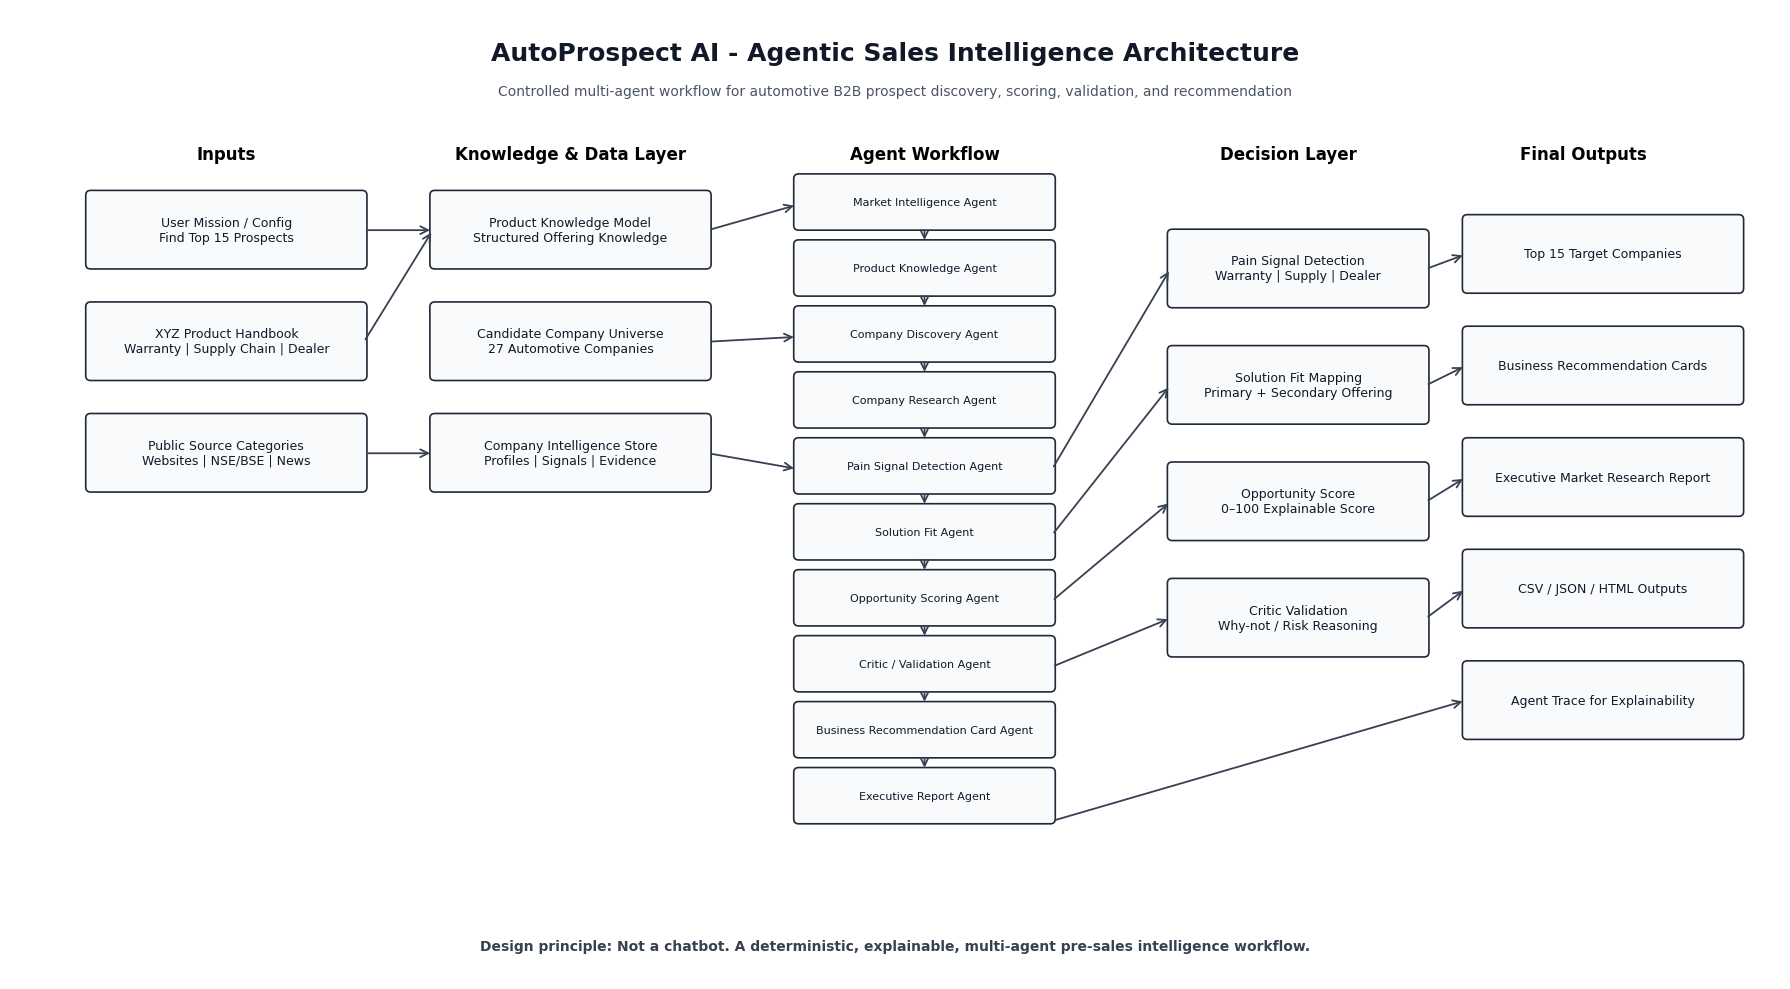

Architecture diagram generated: outputs/architecture_diagram.png


In [44]:
# ============================================================
# Architecture Diagram Generator - Clean Version
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def add_arch_box(ax, x, y, w, h, text, fontsize=9):
    """Add a clean rounded architecture box."""
    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.03,rounding_size=0.05",
        linewidth=1.2,
        edgecolor="#1f2937",
        facecolor="#f8fafc"
    )
    ax.add_patch(box)
    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        wrap=True,
        color="#111827"
    )

def add_arch_arrow(ax, x1, y1, x2, y2):
    """Add a clean directional arrow."""
    arrow = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="->",
        mutation_scale=14,
        linewidth=1.3,
        color="#374151"
    )
    ax.add_patch(arrow)

def generate_architecture_diagram(output_path: str):
    """
    Generate a clean architecture diagram for AutoProspect AI.
    """

    fig, ax = plt.subplots(figsize=(18, 10))
    ax.set_xlim(0, 18)
    ax.set_ylim(0, 10)
    ax.axis("off")

    # Title
    ax.text(
        9,
        9.55,
        "AutoProspect AI - Agentic Sales Intelligence Architecture",
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold",
        color="#111827"
    )

    ax.text(
        9,
        9.15,
        "Controlled multi-agent workflow for automotive B2B prospect discovery, scoring, validation, and recommendation",
        ha="center",
        va="center",
        fontsize=10,
        color="#4b5563"
    )

    # Column headers
    ax.text(2.2, 8.45, "Inputs", ha="center", fontsize=12, fontweight="bold")
    ax.text(5.7, 8.45, "Knowledge & Data Layer", ha="center", fontsize=12, fontweight="bold")
    ax.text(9.3, 8.45, "Agent Workflow", ha="center", fontsize=12, fontweight="bold")
    ax.text(13.0, 8.45, "Decision Layer", ha="center", fontsize=12, fontweight="bold")
    ax.text(16.0, 8.45, "Final Outputs", ha="center", fontsize=12, fontweight="bold")

    # Inputs
    add_arch_box(ax, 0.8, 7.35, 2.8, 0.75, "User Mission / Config\nFind Top 15 Prospects")
    add_arch_box(ax, 0.8, 6.2, 2.8, 0.75, "XYZ Product Handbook\nWarranty | Supply Chain | Dealer")
    add_arch_box(ax, 0.8, 5.05, 2.8, 0.75, "Public Source Categories\nWebsites | NSE/BSE | News")

    # Knowledge & data layer
    add_arch_box(ax, 4.3, 7.35, 2.8, 0.75, "Product Knowledge Model\nStructured Offering Knowledge")
    add_arch_box(ax, 4.3, 6.2, 2.8, 0.75, "Candidate Company Universe\n27 Automotive Companies")
    add_arch_box(ax, 4.3, 5.05, 2.8, 0.75, "Company Intelligence Store\nProfiles | Signals | Evidence")

    # Agent workflow
    agent_x = 8.0
    agent_w = 2.6
    agent_h = 0.52
    agent_start_y = 7.75
    gap = 0.68

    agent_names = [
        "Market Intelligence Agent",
        "Product Knowledge Agent",
        "Company Discovery Agent",
        "Company Research Agent",
        "Pain Signal Detection Agent",
        "Solution Fit Agent",
        "Opportunity Scoring Agent",
        "Critic / Validation Agent",
        "Business Recommendation Card Agent",
        "Executive Report Agent"
    ]

    agent_positions = []
    for i, agent_name in enumerate(agent_names):
        y = agent_start_y - i * gap
        add_arch_box(ax, agent_x, y, agent_w, agent_h, agent_name, fontsize=8)
        agent_positions.append((agent_x, y, agent_w, agent_h))

    # Decision layer
    add_arch_box(ax, 11.8, 6.95, 2.6, 0.75, "Pain Signal Detection\nWarranty | Supply | Dealer")
    add_arch_box(ax, 11.8, 5.75, 2.6, 0.75, "Solution Fit Mapping\nPrimary + Secondary Offering")
    add_arch_box(ax, 11.8, 4.55, 2.6, 0.75, "Opportunity Score\n0–100 Explainable Score")
    add_arch_box(ax, 11.8, 3.35, 2.6, 0.75, "Critic Validation\nWhy-not / Risk Reasoning")

    # Outputs
    add_arch_box(ax, 14.8, 7.1, 2.8, 0.75, "Top 15 Target Companies")
    add_arch_box(ax, 14.8, 5.95, 2.8, 0.75, "Business Recommendation Cards")
    add_arch_box(ax, 14.8, 4.8, 2.8, 0.75, "Executive Market Research Report")
    add_arch_box(ax, 14.8, 3.65, 2.8, 0.75, "CSV / JSON / HTML Outputs")
    add_arch_box(ax, 14.8, 2.5, 2.8, 0.75, "Agent Trace for Explainability")

    # Arrows: inputs to knowledge/data
    add_arch_arrow(ax, 3.6, 7.72, 4.3, 7.72)
    add_arch_arrow(ax, 3.6, 6.57, 4.3, 7.72)
    add_arch_arrow(ax, 3.6, 5.42, 4.3, 5.42)

    # Knowledge/data to agent workflow
    add_arch_arrow(ax, 7.1, 7.72, 8.0, 7.98)
    add_arch_arrow(ax, 7.1, 6.57, 8.0, 6.62)
    add_arch_arrow(ax, 7.1, 5.42, 8.0, 5.26)

    # Agent workflow vertical arrows
    for i in range(len(agent_positions) - 1):
        x, y, w, h = agent_positions[i]
        x2, y2, w2, h2 = agent_positions[i + 1]
        add_arch_arrow(ax, x + w / 2, y, x2 + w2 / 2, y2 + h2)

    # Agent workflow to decision layer
    add_arch_arrow(ax, 10.6, 5.26, 11.8, 7.32)
    add_arch_arrow(ax, 10.6, 4.58, 11.8, 6.12)
    add_arch_arrow(ax, 10.6, 3.90, 11.8, 4.92)
    add_arch_arrow(ax, 10.6, 3.22, 11.8, 3.72)

    # Decision layer to outputs
    add_arch_arrow(ax, 14.4, 7.32, 14.8, 7.47)
    add_arch_arrow(ax, 14.4, 6.12, 14.8, 6.32)
    add_arch_arrow(ax, 14.4, 4.92, 14.8, 5.17)
    add_arch_arrow(ax, 14.4, 3.72, 14.8, 4.02)
    add_arch_arrow(ax, 10.6, 1.63, 14.8, 2.87)

    # Footer
    ax.text(
        9,
        0.3,
        "Design principle: Not a chatbot. A deterministic, explainable, multi-agent pre-sales intelligence workflow.",
        ha="center",
        fontsize=10,
        color="#374151",
        fontweight="bold"
    )

    plt.tight_layout()
    fig.savefig(output_path, dpi=220, bbox_inches="tight")
    plt.show()

    return output_path


architecture_diagram_path = os.path.join(CONFIG["output_dir"], "architecture_diagram.png")
generate_architecture_diagram(architecture_diagram_path)

print(f"Architecture diagram generated: {architecture_diagram_path}")

In [45]:
# ============================================================
# Architecture Summary Documentation
# ============================================================
#
# This markdown artifact explains the production architecture in reviewer-friendly
# language. It is exported to outputs/architecture_summary.md.
# ============================================================

architecture_summary_md = f"""
# AutoProspect AI Architecture Summary

## Architecture Pattern

AutoProspect AI uses a controlled, lightweight multi-agent orchestration pattern implemented inside a Google Colab notebook.

The system is designed for:

- Reproducibility
- Transparency
- Explainable scoring
- Controlled live public-source enrichment
- Safe LLM usage without hardcoded API keys

## End-to-End Flow

Product Handbook
→ Company Universe
→ Public Source Register
→ Live Web Research Agent
→ Evidence Enrichment Agent
→ Market Intelligence Agent
→ Product Knowledge Agent
→ Company Discovery Agent
→ Company Research Agent
→ Pain Signal Detection Agent
→ Solution Fit Agent
→ Opportunity Scoring Agent
→ Critic / Validation Agent
→ Business Recommendation Card Agent
→ Executive Market Research Report Agent
→ Source Intelligence Agent
→ GPT-4o mini Narrative Enhancement Agent
→ Executive Report + Outputs

## Main Components

1. **Configuration Layer**
   Defines target industry, target company count, output folder, live web settings, and LLM model configuration.

2. **Product Knowledge Layer**
   Converts the XYZ Analytics Consulting Product & Solutions Handbook into a structured product knowledge base covering Warranty Analytics, Supply Chain Risk Prediction, and Dealer & Field Service Intelligence.

3. **Company Universe Layer**
   Starts from a curated seed universe of Indian automotive OEMs, EV OEMs, Tier-1 suppliers, and component manufacturers.

4. **Public Source Register**
   Documents the public-source categories expected by the hackathon: company websites, LinkedIn, NSE/BSE, Moneycontrol, Screener, IBEF, SIAM, ACMA, Economic Times Auto, Autocar Professional, Google News, and the Product Handbook.

5. **Live Web Research Layer**
   Performs controlled live fetching from official company websites and Google News RSS. Requests are protected with timeout, user-agent, exception handling, and fallback logic.

6. **Evidence Enrichment Layer**
   Converts live website/news snippets into company-level evidence keywords, recent headline summaries, and evidence notes.

7. **Agent Workflow Layer**
   Runs specialized agents for market understanding, product validation, company research, pain detection, solution fit, scoring, validation, report generation, and LLM narrative enhancement.

8. **Decision Layer**
   Uses deterministic scoring for opportunity ranking so that Top 15 decisions are explainable and not dependent on the LLM.

9. **LLM Narrative Layer**
   Uses GPT-4o mini for executive pitch, business justification, personalized outreach angle, discovery questions, and source-validation guidance. The notebook captures request IDs and token usage as runtime proof.

10. **Output Layer**
   Generates CSV, JSON, HTML, Markdown, and PNG artifacts for review and GitHub packaging.

## Design Rationale

The architecture avoids a generic chatbot design. It behaves like an autonomous pre-sales intelligence workflow: source registration, live evidence gathering, profile enrichment, scoring, validation, recommendation, LLM-enhanced narrative, and final reporting.

## Reproducibility and Safety

- No API key is hardcoded.
- GPT-4o mini is used only when OPENAI_API_KEY is available in Colab Secrets.
- Live web research failures are captured as status rows and do not fail the notebook.
- Ranking remains deterministic and explainable.
- The final runtime verification checks live evidence, LLM request proof, output artifacts, and agent trace.

Generated on: {current_timestamp()}
""".strip()

display(Markdown(architecture_summary_md))


# AutoProspect AI Architecture Summary

## Architecture Pattern

AutoProspect AI uses a controlled, lightweight multi-agent orchestration pattern implemented inside a Google Colab notebook.

The system is designed for:

- Reproducibility
- Transparency
- Explainable scoring
- Controlled live public-source enrichment
- Safe LLM usage without hardcoded API keys

## End-to-End Flow

Product Handbook  
→ Company Universe  
→ Public Source Register  
→ Live Web Research Agent  
→ Evidence Enrichment Agent  
→ Market Intelligence Agent  
→ Product Knowledge Agent  
→ Company Discovery Agent  
→ Company Research Agent  
→ Pain Signal Detection Agent  
→ Solution Fit Agent  
→ Opportunity Scoring Agent  
→ Critic / Validation Agent  
→ Business Recommendation Card Agent  
→ Executive Market Research Report Agent  
→ Source Intelligence Agent  
→ GPT-4o mini Narrative Enhancement Agent  
→ Executive Report + Outputs

## Main Components

1. **Configuration Layer**  
   Defines target industry, target company count, output folder, live web settings, and LLM model configuration.

2. **Product Knowledge Layer**  
   Converts the XYZ Analytics Consulting Product & Solutions Handbook into a structured product knowledge base covering Warranty Analytics, Supply Chain Risk Prediction, and Dealer & Field Service Intelligence.

3. **Company Universe Layer**  
   Starts from a curated seed universe of Indian automotive OEMs, EV OEMs, Tier-1 suppliers, and component manufacturers.

4. **Public Source Register**  
   Documents the public-source categories expected by the hackathon: company websites, LinkedIn, NSE/BSE, Moneycontrol, Screener, IBEF, SIAM, ACMA, Economic Times Auto, Autocar Professional, Google News, and the Product Handbook.

5. **Live Web Research Layer**  
   Performs controlled live fetching from official company websites and Google News RSS. Requests are protected with timeout, user-agent, exception handling, and fallback logic.

6. **Evidence Enrichment Layer**  
   Converts live website/news snippets into company-level evidence keywords, recent headline summaries, and evidence notes.

7. **Agent Workflow Layer**  
   Runs specialized agents for market understanding, product validation, company research, pain detection, solution fit, scoring, validation, report generation, and LLM narrative enhancement.

8. **Decision Layer**  
   Uses deterministic scoring for opportunity ranking so that Top 15 decisions are explainable and not dependent on the LLM.

9. **LLM Narrative Layer**  
   Uses GPT-4o mini for executive pitch, business justification, personalized outreach angle, discovery questions, and source-validation guidance. The notebook captures request IDs and token usage as runtime proof.

10. **Output Layer**  
   Generates CSV, JSON, HTML, Markdown, and PNG artifacts for review and GitHub packaging.

## Design Rationale

The architecture avoids a generic chatbot design. It behaves like an autonomous pre-sales intelligence workflow: source registration, live evidence gathering, profile enrichment, scoring, validation, recommendation, LLM-enhanced narrative, and final reporting.

## Reproducibility and Safety

- No API key is hardcoded.
- GPT-4o mini is used only when OPENAI_API_KEY is available in Colab Secrets.
- Live web research failures are captured as status rows and do not fail the notebook.
- Ranking remains deterministic and explainable.
- The final runtime verification checks live evidence, LLM request proof, output artifacts, and agent trace.

Generated on: 2026-07-04 05:16:10

In [46]:
# ============================================================
# Final Submission Summary Object
# ============================================================

final_submission_summary = {
    "project_name": CONFIG["project_name"],
    "hackathon": CONFIG["hackathon"],
    "client_company": CONFIG["client_company"],
    "industry_focus": CONFIG["industry_focus"],
    "run_mode": CONFIG["run_mode"],
    "llm_enabled": CONFIG["use_llm"],
    "model_name": CONFIG["model_name"],
    "candidate_companies_analyzed": len(company_universe_df),
    "top_target_companies": CONFIG["target_company_count"],
    "agents_executed": len(agent_state["agent_trace"]),
    "agent_orchestration": "Custom lightweight multi-agent orchestration implemented in Python",
    "live_web_research_enabled": CONFIG.get("use_live_web_research", False),
    "final_outputs": [
        "product_knowledge.json",
        "company_universe.csv",
        "company_universe.json",
        "public_source_register.csv",
        "live_web_research_evidence.csv",
        "company_live_evidence_summary.csv",
        "web_scraping_status_report.csv",
        "opportunity_pipeline_all_companies.csv",
        "top15_target_companies.csv",
        "top15_recommendation_cards.csv",
        "top15_recommendation_cards.html",
        "executive_market_research_report.md",
        "executive_market_research_report.html",
        "architecture_diagram.png",
        "architecture_summary.md",
        "agent_trace_step9.json"
    ],
    "status": "Step 9 completed - executive report and architecture generated"
}

pd.DataFrame([final_submission_summary])


,project_name,hackathon,client_company,industry_focus,run_mode,llm_enabled,model_name,candidate_companies_analyzed,top_target_companies,agents_executed,agent_orchestration,live_web_research_enabled,final_outputs,status
0,AutoProspect AI,INTTRVU AI Innovation Hackathon 2026,XYZ Analytics Consulting,Indian Automotive Industry,DEMO,False,gpt-4o-mini,27,15,13,Custom lightweight multi-agent orchestration i...,True,"[product_knowledge.json, company_universe.csv,...",Step 9 completed - executive report and archit...


In [47]:
# ============================================================
# Export Executive Report, Architecture, and Final Summary
# ============================================================

os.makedirs(CONFIG["output_dir"], exist_ok=True)

executive_report_md_path = os.path.join(CONFIG["output_dir"], "executive_market_research_report.md")
executive_report_html_path = os.path.join(CONFIG["output_dir"], "executive_market_research_report.html")
architecture_summary_path = os.path.join(CONFIG["output_dir"], "architecture_summary.md")
final_submission_summary_path = os.path.join(CONFIG["output_dir"], "final_submission_summary.json")
agent_trace_step9_path = os.path.join(CONFIG["output_dir"], "agent_trace_step9.json")

# Markdown report
with open(executive_report_md_path, "w", encoding="utf-8") as f:
    f.write(agent_state["executive_market_research_report_md"])

# Basic HTML report
executive_report_html = f"""
<html>
<head>
    <meta charset="utf-8">
    <title>AutoProspect AI - Executive Market Research Report</title>
    <style>
        body {{
            font-family: Arial, sans-serif;
            margin: 40px;
            line-height: 1.55;
            color: #1f2937;
        }}
        h1, h2, h3 {{
            color: #111827;
        }}
        table {{
            border-collapse: collapse;
            width: 100%;
            margin: 16px 0;
        }}
        th, td {{
            border: 1px solid #d1d5db;
            padding: 8px;
            text-align: left;
        }}
        th {{
            background-color: #f3f4f6;
        }}
        code {{
            background-color: #f3f4f6;
            padding: 2px 4px;
        }}
    </style>
</head>
<body>
<pre style="white-space: pre-wrap; font-family: Arial, sans-serif;">
{agent_state["executive_market_research_report_md"]}
</pre>
</body>
</html>
"""

with open(executive_report_html_path, "w", encoding="utf-8") as f:
    f.write(executive_report_html)

# Architecture summary
with open(architecture_summary_path, "w", encoding="utf-8") as f:
    f.write(architecture_summary_md)

# Final submission summary
with open(final_submission_summary_path, "w", encoding="utf-8") as f:
    json.dump(final_submission_summary, f, indent=4, ensure_ascii=False)

# Agent trace
with open(agent_trace_step9_path, "w", encoding="utf-8") as f:
    json.dump(agent_state["agent_trace"], f, indent=4, ensure_ascii=False)

print(f"Executive report Markdown exported to: {executive_report_md_path}")
print(f"Executive report HTML exported to: {executive_report_html_path}")
print(f"Architecture diagram available at: {architecture_diagram_path}")
print(f"Architecture summary exported to: {architecture_summary_path}")
print(f"Final submission summary exported to: {final_submission_summary_path}")
print(f"Agent trace exported to: {agent_trace_step9_path}")

Executive report Markdown exported to: outputs/executive_market_research_report.md
Executive report HTML exported to: outputs/executive_market_research_report.html
Architecture diagram available at: outputs/architecture_diagram.png
Architecture summary exported to: outputs/architecture_summary.md
Final submission summary exported to: outputs/final_submission_summary.json
Agent trace exported to: outputs/agent_trace_step9.json


### Step 9 Completion Notes

The Executive Market Research Report Agent and Architecture Diagram Generator complete the core final deliverables.

Generated outputs include:

- Executive Market Research Report
- Architecture Diagram
- Architecture Summary
- Final Submission Summary
- Updated Agent Trace

At this point, the notebook contains the core hackathon solution:

Product Knowledge → Company Universe → Agent Workflow → Scoring → Validation → Recommendation Cards → Executive Report → Architecture Diagram

The next step will focus on final notebook quality checks, README preparation, and GitHub packaging.

## 9.5 Source Mapping, GPT-4o mini LLM Enhancement, and Runtime Proof

This section adds the final AI and submission-readiness layer.

It performs:

1. Company-wise source mapping for the Top 15 target companies
2. Safe GPT-4o mini setup using Google Colab Secrets
3. Fresh LLM narrative enhancement for each Top 15 recommendation
4. Runtime proof that GPT-4o mini was actually called
5. Request ID and token usage capture
6. Updated executive report, architecture, exports, and final submission summary

Important design principle:

- Deterministic scoring decides the ranking.
- GPT-4o mini enhances business narrative and sales intelligence.
- The notebook captures request IDs and token counts to prove fresh API execution during each full run.


In [48]:
# ============================================================
# Source Register Validation for LLM Enhancement Stage
# ============================================================

if "public_source_register_df" not in globals():
    raise RuntimeError("public_source_register_df is not available. Please run Section 5.5 before Step 9.5.")

print(f"Public source register available with {len(public_source_register_df)} source categories.")
display(public_source_register_df)

if "live_web_research_evidence_df" in agent_state:
    print(f"Live web evidence rows available: {len(agent_state['live_web_research_evidence_df'])}")
else:
    print("Live web evidence is not yet available in agent_state. Run the Agent Workflow section first.")


Public source register available with 13 source categories.


,source_name,source_type,usage,example_url,used_in_solution
0,Official Company Websites,Company Information,"Company overview, products, manufacturing foot...",Company-specific official website,Yes - used for live website evidence enrichment
1,LinkedIn Company Pages,Company Information,"Company profile, employee strength, business u...",Company-specific LinkedIn page,Mapped as recommended enrichment source; not s...
2,NSE India,Financial Information,Listed company financial and market informatio...,https://www.nseindia.com,Mapped as financial validation source
3,BSE India,Financial Information,Listed company financial and market informatio...,https://www.bseindia.com,Mapped as financial validation source
4,Moneycontrol,Financial Information,"Financial highlights, market profile, business...",https://www.moneycontrol.com,Mapped as financial and business validation so...
5,Screener,Financial Information,"Company financial ratios, filings, and listed ...",https://www.screener.in,Mapped as financial validation source
6,IBEF,Industry Research,"Indian automotive industry context, sector gro...",https://www.ibef.org/industry/india-automobiles,Mapped as industry research source
7,SIAM,Industry Research,"Automotive industry structure, OEM context, pr...",https://www.siam.in,Mapped as automotive OEM industry source
8,ACMA,Industry Research,"Auto component industry context, component man...",https://www.acma.in,Mapped as component industry source
9,Economic Times Auto,Business News,"Automotive business news, growth initiatives, ...",https://auto.economictimes.indiatimes.com,Mapped as business news validation source


Live web evidence rows available: 54


In [49]:
# ============================================================
# Company Source Mapping for Top 15 Recommendations
# ============================================================

def map_sources_for_company(company_name: str) -> Dict[str, Any]:
    """Map recommended research sources for a company."""

    company_info = get_company_info(company_name)
    segment = company_info.get("segment", "")
    website = company_info.get("website", "")

    if "OEM" in segment:
        industry_sources = ["SIAM", "IBEF", "Economic Times Auto", "Autocar Professional", "Google News"]
    elif "Tier-1" in segment or "Component" in segment:
        industry_sources = ["ACMA", "IBEF", "Economic Times Auto", "Autocar Professional", "Google News"]
    else:
        industry_sources = ["IBEF", "Economic Times Auto", "Autocar Professional", "Google News"]

    financial_sources = ["NSE India", "BSE India", "Moneycontrol", "Screener"]

    source_usage_note = (
        "Use official website for company profile and product footprint; "
        "use financial portals for listed-company validation where applicable; "
        "use industry sources for sector context; "
        "use business news sources for recent trigger events; "
        "use XYZ handbook for product-solution mapping."
    )

    return {
        "company_name": company_name,
        "official_website": website,
        "company_profile_sources": ["Official Company Website", "LinkedIn Company Page"],
        "financial_validation_sources": financial_sources,
        "industry_research_sources": industry_sources,
        "business_news_sources": ["Economic Times Auto", "Autocar Professional", "Google News"],
        "product_knowledge_source": "XYZ Product & Solutions Handbook",
        "source_usage_note": source_usage_note
    }


company_source_mapping_rows = []

for _, row in agent_state["recommendation_cards_df"].iterrows():
    company_source_mapping_rows.append(map_sources_for_company(row["company_name"]))

company_source_mapping_df = pd.DataFrame(company_source_mapping_rows)
agent_state["company_source_mapping_df"] = company_source_mapping_df

display(company_source_mapping_df)

,company_name,official_website,company_profile_sources,financial_validation_sources,industry_research_sources,business_news_sources,product_knowledge_source,source_usage_note
0,Ather Energy,https://www.atherenergy.com,"[Official Company Website, LinkedIn Company Page]","[NSE India, BSE India, Moneycontrol, Screener]","[SIAM, IBEF, Economic Times Auto, Autocar Prof...","[Economic Times Auto, Autocar Professional, Go...",XYZ Product & Solutions Handbook,Use official website for company profile and p...
1,Hero MotoCorp,https://www.heromotocorp.com,"[Official Company Website, LinkedIn Company Page]","[NSE India, BSE India, Moneycontrol, Screener]","[SIAM, IBEF, Economic Times Auto, Autocar Prof...","[Economic Times Auto, Autocar Professional, Go...",XYZ Product & Solutions Handbook,Use official website for company profile and p...
2,Ola Electric,https://www.olaelectric.com,"[Official Company Website, LinkedIn Company Page]","[NSE India, BSE India, Moneycontrol, Screener]","[SIAM, IBEF, Economic Times Auto, Autocar Prof...","[Economic Times Auto, Autocar Professional, Go...",XYZ Product & Solutions Handbook,Use official website for company profile and p...
3,TVS Motor Company,https://www.tvsmotor.com,"[Official Company Website, LinkedIn Company Page]","[NSE India, BSE India, Moneycontrol, Screener]","[SIAM, IBEF, Economic Times Auto, Autocar Prof...","[Economic Times Auto, Autocar Professional, Go...",XYZ Product & Solutions Handbook,Use official website for company profile and p...
4,Bajaj Auto,https://www.bajajauto.com,"[Official Company Website, LinkedIn Company Page]","[NSE India, BSE India, Moneycontrol, Screener]","[SIAM, IBEF, Economic Times Auto, Autocar Prof...","[Economic Times Auto, Autocar Professional, Go...",XYZ Product & Solutions Handbook,Use official website for company profile and p...
5,Hyundai Motor India,https://www.hyundai.com/in,"[Official Company Website, LinkedIn Company Page]","[NSE India, BSE India, Moneycontrol, Screener]","[SIAM, IBEF, Economic Times Auto, Autocar Prof...","[Economic Times Auto, Autocar Professional, Go...",XYZ Product & Solutions Handbook,Use official website for company profile and p...
6,Tata Motors,https://www.tatamotors.com,"[Official Company Website, LinkedIn Company Page]","[NSE India, BSE India, Moneycontrol, Screener]","[SIAM, IBEF, Economic Times Auto, Autocar Prof...","[Economic Times Auto, Autocar Professional, Go...",XYZ Product & Solutions Handbook,Use official website for company profile and p...
7,Ashok Leyland,https://www.ashokleyland.com,"[Official Company Website, LinkedIn Company Page]","[NSE India, BSE India, Moneycontrol, Screener]","[SIAM, IBEF, Economic Times Auto, Autocar Prof...","[Economic Times Auto, Autocar Professional, Go...",XYZ Product & Solutions Handbook,Use official website for company profile and p...
8,Sona BLW Precision Forgings,https://sonacomstar.com,"[Official Company Website, LinkedIn Company Page]","[NSE India, BSE India, Moneycontrol, Screener]","[ACMA, IBEF, Economic Times Auto, Autocar Prof...","[Economic Times Auto, Autocar Professional, Go...",XYZ Product & Solutions Handbook,Use official website for company profile and p...
9,JBM Auto,https://www.jbmgroup.com,"[Official Company Website, LinkedIn Company Page]","[NSE India, BSE India, Moneycontrol, Screener]","[SIAM, IBEF, Economic Times Auto, Autocar Prof...","[Economic Times Auto, Autocar Professional, Go...",XYZ Product & Solutions Handbook,Use official website for company profile and p...


In [50]:
# ============================================================
# Safe GPT-4o mini Setup using Colab Secrets
# ============================================================

import sys
import subprocess
import importlib.util

# Install OpenAI package if not available.
if importlib.util.find_spec("openai") is None:
    print("Installing OpenAI Python package...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "openai"])

from openai import OpenAI

def get_colab_secret(secret_name: str) -> Optional[str]:
    """
    Safely retrieve secret from Google Colab.
    Falls back to environment variable if not running in Colab.
    """
    secret_value = None

    try:
        from google.colab import userdata
        secret_value = userdata.get(secret_name)
    except Exception:
        secret_value = os.environ.get(secret_name)

    return secret_value


OPENAI_API_KEY = get_colab_secret("OPENAI_API_KEY")

LLM_AVAILABLE = OPENAI_API_KEY is not None and len(str(OPENAI_API_KEY).strip()) > 0

if LLM_AVAILABLE:
    openai_client = OpenAI(api_key=OPENAI_API_KEY)
    CONFIG["use_llm"] = True
    CONFIG["llm_provider"] = "OpenAI"
    CONFIG["model_name"] = "gpt-4o-mini"
    print("GPT-4o mini setup completed successfully using Colab Secrets.")
else:
    openai_client = None
    CONFIG["use_llm"] = False
    print("OPENAI_API_KEY not found. LLM enhancement will use safe fallback text.")
    print("For final submission run, add OPENAI_API_KEY in Colab Secrets and rerun Step 9.5.")

print("LLM Available:", LLM_AVAILABLE)
print("Configured Model:", CONFIG["model_name"])

GPT-4o mini setup completed successfully using Colab Secrets.
LLM Available: True
Configured Model: gpt-4o-mini


In [51]:
# ============================================================
# GPT-4o mini Prompt, JSON Parsing, and Runtime Proof Helpers
# ============================================================
#
# Production behavior:
# - Each notebook Run All creates a fresh LLM runtime session ID.
# - Each Top 15 recommendation triggers one GPT-4o mini API call when
#   OPENAI_API_KEY is available.
# - Request ID, model, token usage, company name, and timestamp are captured.
# - If the key is missing, the notebook falls back safely, but final submission
#   should use GPT-4o mini mode.
# ============================================================

import uuid

LLM_CALL_LOGS: List[Dict[str, Any]] = []
LLM_RUNTIME_SESSION_ID = f"not_started_{uuid.uuid4().hex[:8]}"


def utc_now_iso() -> str:
    """Return a UTC timestamp in ISO-like format for runtime proof."""
    return datetime.datetime.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ")


def safe_json_loads(text: str) -> Dict[str, Any]:
    """
    Parse JSON returned by the LLM.

    GPT-4o mini is requested to return JSON. This fallback keeps the notebook
    robust if a provider response contains non-JSON text.
    """
    try:
        return json.loads(text)
    except Exception:
        return {
            "executive_pitch": text,
            "enhanced_business_justification": (
                "LLM returned non-JSON text. Use executive_pitch as the narrative output."
            ),
            "personalized_outreach_angle": "Validate in discovery call.",
            "discovery_questions": [
                "What is the current business priority?",
                "Which operational data sources are available?",
                "What KPI improvement would justify a pilot?"
            ],
            "data_sources_to_validate": [
                "Official company website",
                "Financial portals",
                "Business news sources"
            ],
            "caution_note": "LLM response could not be parsed as JSON."
        }


def build_llm_enhancement_prompt(row: pd.Series, source_mapping: Dict[str, Any]) -> str:
    """
    Build a controlled, context-grounded prompt for GPT-4o mini.

    The prompt deliberately instructs the model not to invent facts, financial
    numbers, or news. It can only transform the structured evidence already
    generated by the deterministic agents.
    """

    prompt_payload = {
        "company_name": row["company_name"],
        "segment": row["segment"],
        "category": row["category"],
        "company_overview": row["company_overview"],
        "primary_solution": row["primary_solution"],
        "secondary_solution": row["secondary_solution"],
        "opportunity_score": int(row["opportunity_score"]),
        "priority": row["priority"],
        "confidence": row["confidence"],
        "why_selected": row["why_selected"],
        "business_challenges": row["business_challenges"],
        "recommended_solution_rationale": row["recommended_solution_rationale"],
        "expected_business_value": row["expected_business_value"],
        "relevant_kpis": row["relevant_kpis"],
        "suggested_stakeholders": row["suggested_stakeholders"],
        "why_not_risk": row["why_not_risk"],
        "source_mapping": source_mapping
    }

    return f"""
You are a senior B2B pre-sales strategist for an automotive analytics consulting company.

Use ONLY the provided context. Do not invent facts, financial numbers, customers, or news.
If something needs validation, mention it as a validation point.

Create a concise sales-intelligence enhancement for the company below.

Return ONLY valid JSON with these keys:
- executive_pitch
- enhanced_business_justification
- personalized_outreach_angle
- discovery_questions
- data_sources_to_validate
- caution_note

Context:
{json.dumps(prompt_payload, indent=2, ensure_ascii=False)}
""".strip()


def log_llm_call(
    company_name: str,
    status: str,
    execution_mode: str,
    request_id: Optional[str] = None,
    model: Optional[str] = None,
    prompt_tokens: Optional[int] = 0,
    completion_tokens: Optional[int] = 0,
    total_tokens: Optional[int] = 0,
    error: str = ""
) -> None:
    """Append one LLM call record to the runtime proof log."""
    LLM_CALL_LOGS.append({
        "runtime_session_id": LLM_RUNTIME_SESSION_ID,
        "generated_at_utc": utc_now_iso(),
        "company_name": company_name,
        "llm_execution_mode": execution_mode,
        "request_id": request_id,
        "model": model or CONFIG.get("model_name"),
        "prompt_tokens": int(prompt_tokens or 0),
        "completion_tokens": int(completion_tokens or 0),
        "total_tokens": int(total_tokens or 0),
        "status": status,
        "error": error[:500] if error else ""
    })


def call_gpt4o_mini_for_json(prompt: str, company_name: str = "Unknown") -> Dict[str, Any]:
    """
    Call GPT-4o mini and return parsed JSON plus runtime proof.

    This function is the single controlled gateway for LLM calls in the notebook.
    The final verification step checks the log generated here.
    """

    if not LLM_AVAILABLE or openai_client is None:
        log_llm_call(
            company_name=company_name,
            status="Fallback",
            execution_mode="Fallback - API key not available",
            request_id=None,
            model=CONFIG["model_name"],
            error="OPENAI_API_KEY was not available in Colab Secrets."
        )

        return {
            "executive_pitch": "LLM enhancement not executed because OPENAI_API_KEY was not available.",
            "enhanced_business_justification": (
                "Fallback output generated from deterministic agents. "
                "Add OPENAI_API_KEY in Colab Secrets for GPT-4o mini enhancement."
            ),
            "personalized_outreach_angle": "Use deterministic recommendation card for initial outreach.",
            "discovery_questions": [
                "Which operational pain area is most urgent today?",
                "What data sources are available for a pilot?",
                "Which KPI improvement would justify a consulting engagement?"
            ],
            "data_sources_to_validate": [
                "Official company website",
                "Financial portals",
                "Business news sources"
            ],
            "caution_note": "Fallback mode. LLM was not executed."
        }

    try:
        response = openai_client.chat.completions.create(
            model=CONFIG["model_name"],
            messages=[
                {
                    "role": "system",
                    "content": (
                        "You are a precise enterprise sales-intelligence assistant. "
                        "Use only provided context. Do not hallucinate. Return valid JSON only."
                    )
                },
                {
                    "role": "user",
                    "content": prompt
                }
            ],
            temperature=0.2,
            response_format={"type": "json_object"}
        )

        usage = response.usage

        log_llm_call(
            company_name=company_name,
            status="Completed",
            execution_mode="GPT-4o mini",
            request_id=response.id,
            model=response.model,
            prompt_tokens=usage.prompt_tokens if usage else 0,
            completion_tokens=usage.completion_tokens if usage else 0,
            total_tokens=usage.total_tokens if usage else 0
        )

        content = response.choices[0].message.content
        return safe_json_loads(content)

    except Exception as exc:
        # Fail closed for the company-level narrative while preserving the full run.
        log_llm_call(
            company_name=company_name,
            status="Failed",
            execution_mode="GPT-4o mini - failed",
            request_id=None,
            model=CONFIG["model_name"],
            error=str(exc)
        )

        return {
            "executive_pitch": f"LLM call failed for {company_name}. Use deterministic recommendation card.",
            "enhanced_business_justification": "LLM call failed; deterministic recommendation remains available.",
            "personalized_outreach_angle": "Validate with standard sales discovery.",
            "discovery_questions": [
                "Which operational pain area is most urgent today?",
                "What data sources are available for a pilot?",
                "Which KPI improvement would justify a consulting engagement?"
            ],
            "data_sources_to_validate": [
                "Official company website",
                "Financial portals",
                "Business news sources"
            ],
            "caution_note": f"LLM call failed: {str(exc)[:200]}"
        }


print("GPT-4o mini helper functions loaded with runtime proof logging.")


GPT-4o mini helper functions loaded with runtime proof logging.


In [52]:
# ============================================================
# LLM Narrative Enhancement Agent
# ============================================================
#
# This agent turns deterministic recommendation cards into business-ready
# executive narratives. It does not modify the ranking or scoring.
# ============================================================

def llm_narrative_enhancement_agent(state: Dict[str, Any]) -> Dict[str, Any]:
    """
    Enhance the Top 15 recommendation cards using GPT-4o mini.

    Output is stored in:
    - state["llm_enhanced_recommendations_df"]
    - state["llm_usage_log_df"]
    """

    recommendation_df = state["recommendation_cards_df"].copy()
    source_mapping_df = state["company_source_mapping_df"].copy()

    enhanced_rows = []

    for _, row in recommendation_df.iterrows():
        company_name = row["company_name"]

        source_row = source_mapping_df[source_mapping_df["company_name"] == company_name]
        source_mapping = source_row.iloc[0].to_dict() if not source_row.empty else {}

        prompt = build_llm_enhancement_prompt(row, source_mapping)
        llm_output = call_gpt4o_mini_for_json(prompt, company_name=company_name)

        # Capture the latest LLM call log for this company so proof columns travel
        # with the recommendation output.
        latest_log = next(
            (log for log in reversed(LLM_CALL_LOGS) if log["company_name"] == company_name),
            {}
        )

        enhanced_row = row.to_dict()
        enhanced_row.update({
            "llm_executive_pitch": llm_output.get("executive_pitch", ""),
            "llm_business_justification": llm_output.get("enhanced_business_justification", ""),
            "llm_personalized_outreach_angle": llm_output.get("personalized_outreach_angle", ""),
            "llm_discovery_questions": llm_output.get("discovery_questions", []),
            "llm_data_sources_to_validate": llm_output.get("data_sources_to_validate", []),
            "llm_caution_note": llm_output.get("caution_note", ""),
            "llm_model_used": latest_log.get("model", CONFIG["model_name"]),
            "llm_execution_mode": latest_log.get(
                "llm_execution_mode",
                "GPT-4o mini" if LLM_AVAILABLE else "Fallback - API key not available"
            ),
            "llm_runtime_session_id": latest_log.get("runtime_session_id", LLM_RUNTIME_SESSION_ID),
            "llm_generated_at_utc": latest_log.get("generated_at_utc", ""),
            "llm_request_id": latest_log.get("request_id", ""),
            "llm_prompt_tokens": latest_log.get("prompt_tokens", 0),
            "llm_completion_tokens": latest_log.get("completion_tokens", 0),
            "llm_total_tokens": latest_log.get("total_tokens", 0),
            "llm_call_status": latest_log.get("status", "")
        })

        enhanced_rows.append(enhanced_row)

    llm_enhanced_recommendations_df = pd.DataFrame(enhanced_rows)
    llm_usage_log_df = pd.DataFrame(LLM_CALL_LOGS)

    state["llm_enhanced_recommendations_df"] = llm_enhanced_recommendations_df
    state["llm_usage_log_df"] = llm_usage_log_df

    completed_calls = int((llm_usage_log_df["status"] == "Completed").sum()) if not llm_usage_log_df.empty else 0
    total_tokens = int(llm_usage_log_df["total_tokens"].sum()) if not llm_usage_log_df.empty else 0

    status_text = (
        f"GPT-4o mini completed calls: {completed_calls}, total tokens: {total_tokens}"
        if LLM_AVAILABLE else
        "Fallback used because API key was unavailable"
    )

    return add_agent_trace(
        state=state,
        agent_name="LLM Narrative Enhancement Agent",
        action="Enhance Top 15 recommendations using GPT-4o mini narrative generation",
        input_summary="Recommendation cards, source mapping, product knowledge, scoring output, and live evidence",
        output_summary=(
            f"Generated LLM-enhanced narratives for {len(llm_enhanced_recommendations_df)} companies. "
            f"{status_text}."
        )
    )


In [53]:
# ============================================================
# Run Source Intelligence and LLM Narrative Enhancement Agents
# ============================================================
#
# Fresh-run rule:
# - Every time this cell runs, the runtime session ID and LLM call log are reset.
# - When OPENAI_API_KEY is available, the next 15 recommendation narratives are
#   generated through fresh GPT-4o mini API calls.
# ============================================================

LLM_CALL_LOGS = []
LLM_RUNTIME_SESSION_ID = f"llm_run_{datetime.datetime.utcnow().strftime('%Y%m%dT%H%M%SZ')}_{uuid.uuid4().hex[:8]}"

# Remove previous Step 9.5 trace entries if this cell is re-run.
agent_state["agent_trace"] = [
    entry for entry in agent_state["agent_trace"]
    if entry["agent_name"] not in ["Source Intelligence Agent", "LLM Narrative Enhancement Agent"]
]

agent_state = source_intelligence_agent(agent_state)
agent_state["company_source_mapping_df"] = company_source_mapping_df
agent_state = llm_narrative_enhancement_agent(agent_state)

llm_usage_log_df = agent_state.get("llm_usage_log_df", pd.DataFrame())
completed_llm_calls = int((llm_usage_log_df["status"] == "Completed").sum()) if not llm_usage_log_df.empty else 0
total_llm_tokens = int(llm_usage_log_df["total_tokens"].sum()) if not llm_usage_log_df.empty else 0

print("Step 9.5 Source Intelligence and LLM Enhancement completed.")
print("LLM Available:", LLM_AVAILABLE)
print("LLM Runtime Session ID:", LLM_RUNTIME_SESSION_ID)
print("Completed GPT-4o mini calls:", completed_llm_calls)
print("Total GPT-4o mini tokens captured:", total_llm_tokens)
print("Agents executed so far:", len(agent_state["agent_trace"]))
print("LLM enhanced recommendation rows:", len(agent_state["llm_enhanced_recommendations_df"]))


/tmp/ipykernel_588/1062209321.py:12: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  LLM_RUNTIME_SESSION_ID = f"llm_run_{datetime.datetime.utcnow().strftime('%Y%m%dT%H%M%SZ')}_{uuid.uuid4().hex[:8]}"
/tmp/ipykernel_588/1325048756.py:22: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.datetime.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ")


Step 9.5 Source Intelligence and LLM Enhancement completed.
LLM Available: True
LLM Runtime Session ID: llm_run_20260704T051613Z_041383f3
Completed GPT-4o mini calls: 15
Total GPT-4o mini tokens captured: 17711
Agents executed so far: 14
LLM enhanced recommendation rows: 15


In [54]:
# ============================================================
# GPT-4o mini Runtime Proof
# ============================================================
#
# Reviewer check:
# - request_id must be populated for each company
# - status must be Completed
# - total_tokens must be greater than 0
# - runtime_session_id should change after every fresh Run All
# ============================================================

llm_usage_log_df = agent_state.get("llm_usage_log_df", pd.DataFrame()).copy()

if llm_usage_log_df.empty:
    print("❌ No LLM usage log found. Run the previous LLM enhancement cell first.")
else:
    display(llm_usage_log_df)

    completed_calls = int((llm_usage_log_df["status"] == "Completed").sum())
    request_ids_captured = int(llm_usage_log_df["request_id"].fillna("").astype(str).str.len().gt(0).sum())
    total_tokens = int(llm_usage_log_df["total_tokens"].sum())
    runtime_sessions = llm_usage_log_df["runtime_session_id"].dropna().unique().tolist()

    print("GPT-4o mini runtime proof")
    print("Runtime session ID(s):", runtime_sessions)
    print("Completed GPT-4o mini calls:", completed_calls)
    print("Request IDs captured:", request_ids_captured)
    print("Total tokens captured:", total_tokens)

    if completed_calls == CONFIG["target_company_count"] and request_ids_captured == CONFIG["target_company_count"] and total_tokens > 0:
        print("✅ PASS: Fresh GPT-4o mini calls are confirmed for all Top 15 companies.")
    else:
        print("⚠️ REVIEW: LLM proof is incomplete. Check OPENAI_API_KEY and rerun Section 9.5.")


,runtime_session_id,generated_at_utc,company_name,llm_execution_mode,request_id,model,prompt_tokens,completion_tokens,total_tokens,status,error
0,llm_run_20260704T051613Z_041383f3,2026-07-04T05:16:20Z,Ather Energy,GPT-4o mini,chatcmpl-Dxn1cchlgfAva2rd0HSPb7EpW30Oj,gpt-4o-mini-2024-07-18,810,387,1197,Completed,
1,llm_run_20260704T051613Z_041383f3,2026-07-04T05:16:24Z,Hero MotoCorp,GPT-4o mini,chatcmpl-Dxn1hVSDbz8PsUdnz5IODkfdg1BaS,gpt-4o-mini-2024-07-18,793,325,1118,Completed,
2,llm_run_20260704T051613Z_041383f3,2026-07-04T05:16:28Z,Ola Electric,GPT-4o mini,chatcmpl-Dxn1krsT8sz6hXgn8zKaxpukT7aOa,gpt-4o-mini-2024-07-18,811,376,1187,Completed,
3,llm_run_20260704T051613Z_041383f3,2026-07-04T05:16:32Z,TVS Motor Company,GPT-4o mini,chatcmpl-Dxn1o1Qydb7I2aHkqdbFSAASacov7,gpt-4o-mini-2024-07-18,814,365,1179,Completed,
4,llm_run_20260704T051613Z_041383f3,2026-07-04T05:16:36Z,Bajaj Auto,GPT-4o mini,chatcmpl-Dxn1tdHOwpTO12ZCA2OP5ZcDE6RnZ,gpt-4o-mini-2024-07-18,808,363,1171,Completed,
5,llm_run_20260704T051613Z_041383f3,2026-07-04T05:16:41Z,Hyundai Motor India,GPT-4o mini,chatcmpl-Dxn1wiCzKVKwnmcX1ZdEFxHbzqOqr,gpt-4o-mini-2024-07-18,795,381,1176,Completed,
6,llm_run_20260704T051613Z_041383f3,2026-07-04T05:16:46Z,Tata Motors,GPT-4o mini,chatcmpl-Dxn213FuQQwjpmESWVL2OqqFedyF1,gpt-4o-mini-2024-07-18,819,377,1196,Completed,
7,llm_run_20260704T051613Z_041383f3,2026-07-04T05:16:50Z,Ashok Leyland,GPT-4o mini,chatcmpl-Dxn26TjkkzehF1WFyjDrBqbvCK3xC,gpt-4o-mini-2024-07-18,801,382,1183,Completed,
8,llm_run_20260704T051613Z_041383f3,2026-07-04T05:16:56Z,Sona BLW Precision Forgings,GPT-4o mini,chatcmpl-Dxn2BfmSPCznq3UTtTBr43hFXaJV1,gpt-4o-mini-2024-07-18,805,419,1224,Completed,
9,llm_run_20260704T051613Z_041383f3,2026-07-04T05:17:01Z,JBM Auto,GPT-4o mini,chatcmpl-Dxn2G0EfWYT8dPKzcBgBPUE6im1vC,gpt-4o-mini-2024-07-18,811,360,1171,Completed,


GPT-4o mini runtime proof
Runtime session ID(s): ['llm_run_20260704T051613Z_041383f3']
Completed GPT-4o mini calls: 15
Request IDs captured: 15
Total tokens captured: 17711
✅ PASS: Fresh GPT-4o mini calls are confirmed for all Top 15 companies.


In [55]:
# ============================================================
# Display LLM Enhanced Recommendations
# ============================================================
#
# This view combines recommendation quality with LLM runtime proof columns so
# reviewers can see that the business narrative was produced by GPT-4o mini.
# ============================================================

llm_enhanced_recommendations_df = agent_state["llm_enhanced_recommendations_df"].copy()

llm_display_columns = [
    "rank",
    "company_name",
    "primary_solution",
    "priority",
    "opportunity_score",
    "llm_execution_mode",
    "llm_request_id",
    "llm_total_tokens",
    "llm_executive_pitch",
    "llm_personalized_outreach_angle",
    "llm_discovery_questions"
]

available_llm_display_columns = [
    col for col in llm_display_columns
    if col in llm_enhanced_recommendations_df.columns
]

llm_display_df = llm_enhanced_recommendations_df[available_llm_display_columns].copy()

if "llm_discovery_questions" in llm_display_df.columns:
    llm_display_df["llm_discovery_questions"] = llm_display_df["llm_discovery_questions"].apply(
        lambda x: "; ".join(x) if isinstance(x, list) else x
    )

display(llm_display_df)


,rank,company_name,primary_solution,priority,opportunity_score,llm_execution_mode,llm_request_id,llm_total_tokens,llm_executive_pitch,llm_personalized_outreach_angle,llm_discovery_questions
0,1,Ather Energy,Warranty Analytics,Hot,83,GPT-4o mini,chatcmpl-Dxn1cchlgfAva2rd0HSPb7EpW30Oj,1197,"Ather Energy, a leader in the electric two-whe...",Engage Ather Energy by highlighting how our an...,What current challenges do you face in warrant...
1,2,Hero MotoCorp,Dealer & Field Service Intelligence,Hot,83,GPT-4o mini,chatcmpl-Dxn1hVSDbz8PsUdnz5IODkfdg1BaS,1118,"Hero MotoCorp, a leading two-wheeler manufactu...",Highlight how our solutions can specifically e...,What current analytics capabilities do you hav...
2,3,Ola Electric,Warranty Analytics,Hot,83,GPT-4o mini,chatcmpl-Dxn1krsT8sz6hXgn8zKaxpukT7aOa,1187,"Ola Electric, a leader in electric two-wheeler...",Engage Ola Electric by highlighting how our an...,What current challenges are you facing with wa...
3,4,TVS Motor Company,Dealer & Field Service Intelligence,Hot,83,GPT-4o mini,chatcmpl-Dxn1o1Qydb7I2aHkqdbFSAASacov7,1179,TVS Motor Company is a leading manufacturer in...,Highlight the potential for improved dealer pe...,What current analytics capabilities do you hav...
4,5,Bajaj Auto,Supply Chain Risk Prediction,Hot,83,GPT-4o mini,chatcmpl-Dxn1tdHOwpTO12ZCA2OP5ZcDE6RnZ,1171,"Bajaj Auto, a leading OEM in the two-wheeler a...",Highlight the potential for Bajaj Auto to leve...,What current challenges are you facing in your...
5,6,Hyundai Motor India,Supply Chain Risk Prediction,Hot,83,GPT-4o mini,chatcmpl-Dxn1wiCzKVKwnmcX1ZdEFxHbzqOqr,1176,"Hyundai Motor India, a leading OEM in the pass...",Highlight the potential for reducing warranty ...,What current challenges are you facing in mana...
6,7,Tata Motors,Warranty Analytics,Hot,81,GPT-4o mini,chatcmpl-Dxn213FuQQwjpmESWVL2OqqFedyF1,1196,"Tata Motors, a leading Indian automotive OEM, ...",Engage with Tata Motors by highlighting our ex...,What current analytics capabilities do you hav...
7,8,Ashok Leyland,Dealer & Field Service Intelligence,Warm,79,GPT-4o mini,chatcmpl-Dxn26TjkkzehF1WFyjDrBqbvCK3xC,1183,"Ashok Leyland, a leading manufacturer in the c...",Engage with Ashok Leyland by highlighting how ...,What current analytics capabilities do you hav...
8,9,Sona BLW Precision Forgings,Supply Chain Risk Prediction,Warm,78,GPT-4o mini,chatcmpl-Dxn2BfmSPCznq3UTtTBr43hFXaJV1,1224,Sona BLW Precision Forgings is at the forefron...,Engage with Sona BLW by highlighting our exper...,What current challenges are you facing in mana...
9,10,JBM Auto,Warranty Analytics,Warm,78,GPT-4o mini,chatcmpl-Dxn2G0EfWYT8dPKzcBgBPUE6im1vC,1171,JBM Auto is positioned at the forefront of ele...,Engage JBM Auto by highlighting how our analyt...,What current challenges are you facing with wa...


In [56]:
# ============================================================
# Update Executive Report with Source Intelligence, Live Evidence, and LLM Addendum
# ============================================================

source_register_md = public_source_register_df.to_markdown(index=False)

source_mapping_display_df = company_source_mapping_df.copy()

for col in [
    "company_profile_sources",
    "financial_validation_sources",
    "industry_research_sources",
    "business_news_sources"
]:
    source_mapping_display_df[col] = source_mapping_display_df[col].apply(
        lambda x: ", ".join(x) if isinstance(x, list) else x
    )

source_mapping_md = source_mapping_display_df[
    [
        "company_name",
        "official_website",
        "financial_validation_sources",
        "industry_research_sources",
        "business_news_sources",
        "product_knowledge_source"
    ]
].to_markdown(index=False)

web_status_df = agent_state.get("web_scraping_status_report_df", pd.DataFrame())
web_status_md = web_status_df.to_markdown(index=False) if not web_status_df.empty else "No web scraping status available."

live_summary_df = agent_state.get("company_live_evidence_summary_df", pd.DataFrame()).copy()
if not live_summary_df.empty:
    live_summary_display_df = live_summary_df[
        ["company_name", "live_evidence_available", "successful_sources", "evidence_keywords"]
    ].copy()
    live_summary_display_df["evidence_keywords"] = live_summary_display_df["evidence_keywords"].apply(
        lambda x: ", ".join(x) if isinstance(x, list) else x
    )
    live_summary_md = live_summary_display_df.head(15).to_markdown(index=False)
else:
    live_summary_md = "No live evidence summary available."

llm_addendum_table = llm_enhanced_recommendations_df[
    [
        "rank",
        "company_name",
        "primary_solution",
        "priority",
        "llm_execution_mode",
        "llm_executive_pitch"
    ]
].copy()

llm_addendum_md = llm_addendum_table.to_markdown(index=False)

llm_status_text = "GPT-4o mini was used through OpenAI API via Colab Secrets." if LLM_AVAILABLE else "LLM enhancement fallback was used because OPENAI_API_KEY was not available."

step_9_5_report_addendum = f"""

---

## 16. Public Source Intelligence Register

The solution aligns with the public data-source categories suggested in the hackathon guideline.

{source_register_md}

---

## 17. Live Web Research Evidence

AutoProspect AI performs controlled live web research from official company websites and Google News RSS. The live research layer is intentionally implemented with timeout, error handling, and fallback logic to maintain Google Colab reliability.

### Live Web Research Status

{web_status_md}

### Company Live Evidence Summary

{live_summary_md}

---

## 18. Company Source Mapping for Top 15 Prospects

For each selected prospect, AutoProspect AI maps recommended source categories for company profile validation, financial validation, industry research, business news, and product-solution mapping.

{source_mapping_md}

---

## 19. GPT-4o mini LLM Narrative Enhancement

AutoProspect AI uses deterministic scoring for ranking and GPT-4o mini for business narrative enhancement.

**LLM Status:** {llm_status_text}

The LLM is not used to decide the final ranking. It is used to enhance:

- Executive sales pitch
- Business justification
- Personalized outreach angle
- Discovery questions
- Data-source validation guidance

{llm_addendum_md}

---

## 20. Final Technology Positioning

AutoProspect AI uses:

- Google Colab as the mandatory development and execution environment
- Custom lightweight multi-agent orchestration implemented in Python
- Structured product knowledge from XYZ Product & Solutions Handbook
- Public source register and company-source mapping
- Controlled live web research using official websites and Google News RSS
- Deterministic opportunity scoring for explainability
- GPT-4o mini for LLM-powered business narrative enhancement
- CSV, JSON, HTML, Markdown, and PNG outputs for final submission

""".strip()

# Avoid duplicate addendum if this cell is re-run.
base_report = agent_state["executive_market_research_report_md"].split("\n---\n\n## 16. Public Source Intelligence Register")[0]

agent_state["executive_market_research_report_md"] = base_report.strip() + "\n\n" + step_9_5_report_addendum

display(Markdown("Executive report updated with Source Intelligence, Live Web Research Evidence, and GPT-4o mini LLM Enhancement addendum."))


Executive report updated with Source Intelligence, Live Web Research Evidence, and GPT-4o mini LLM Enhancement addendum.

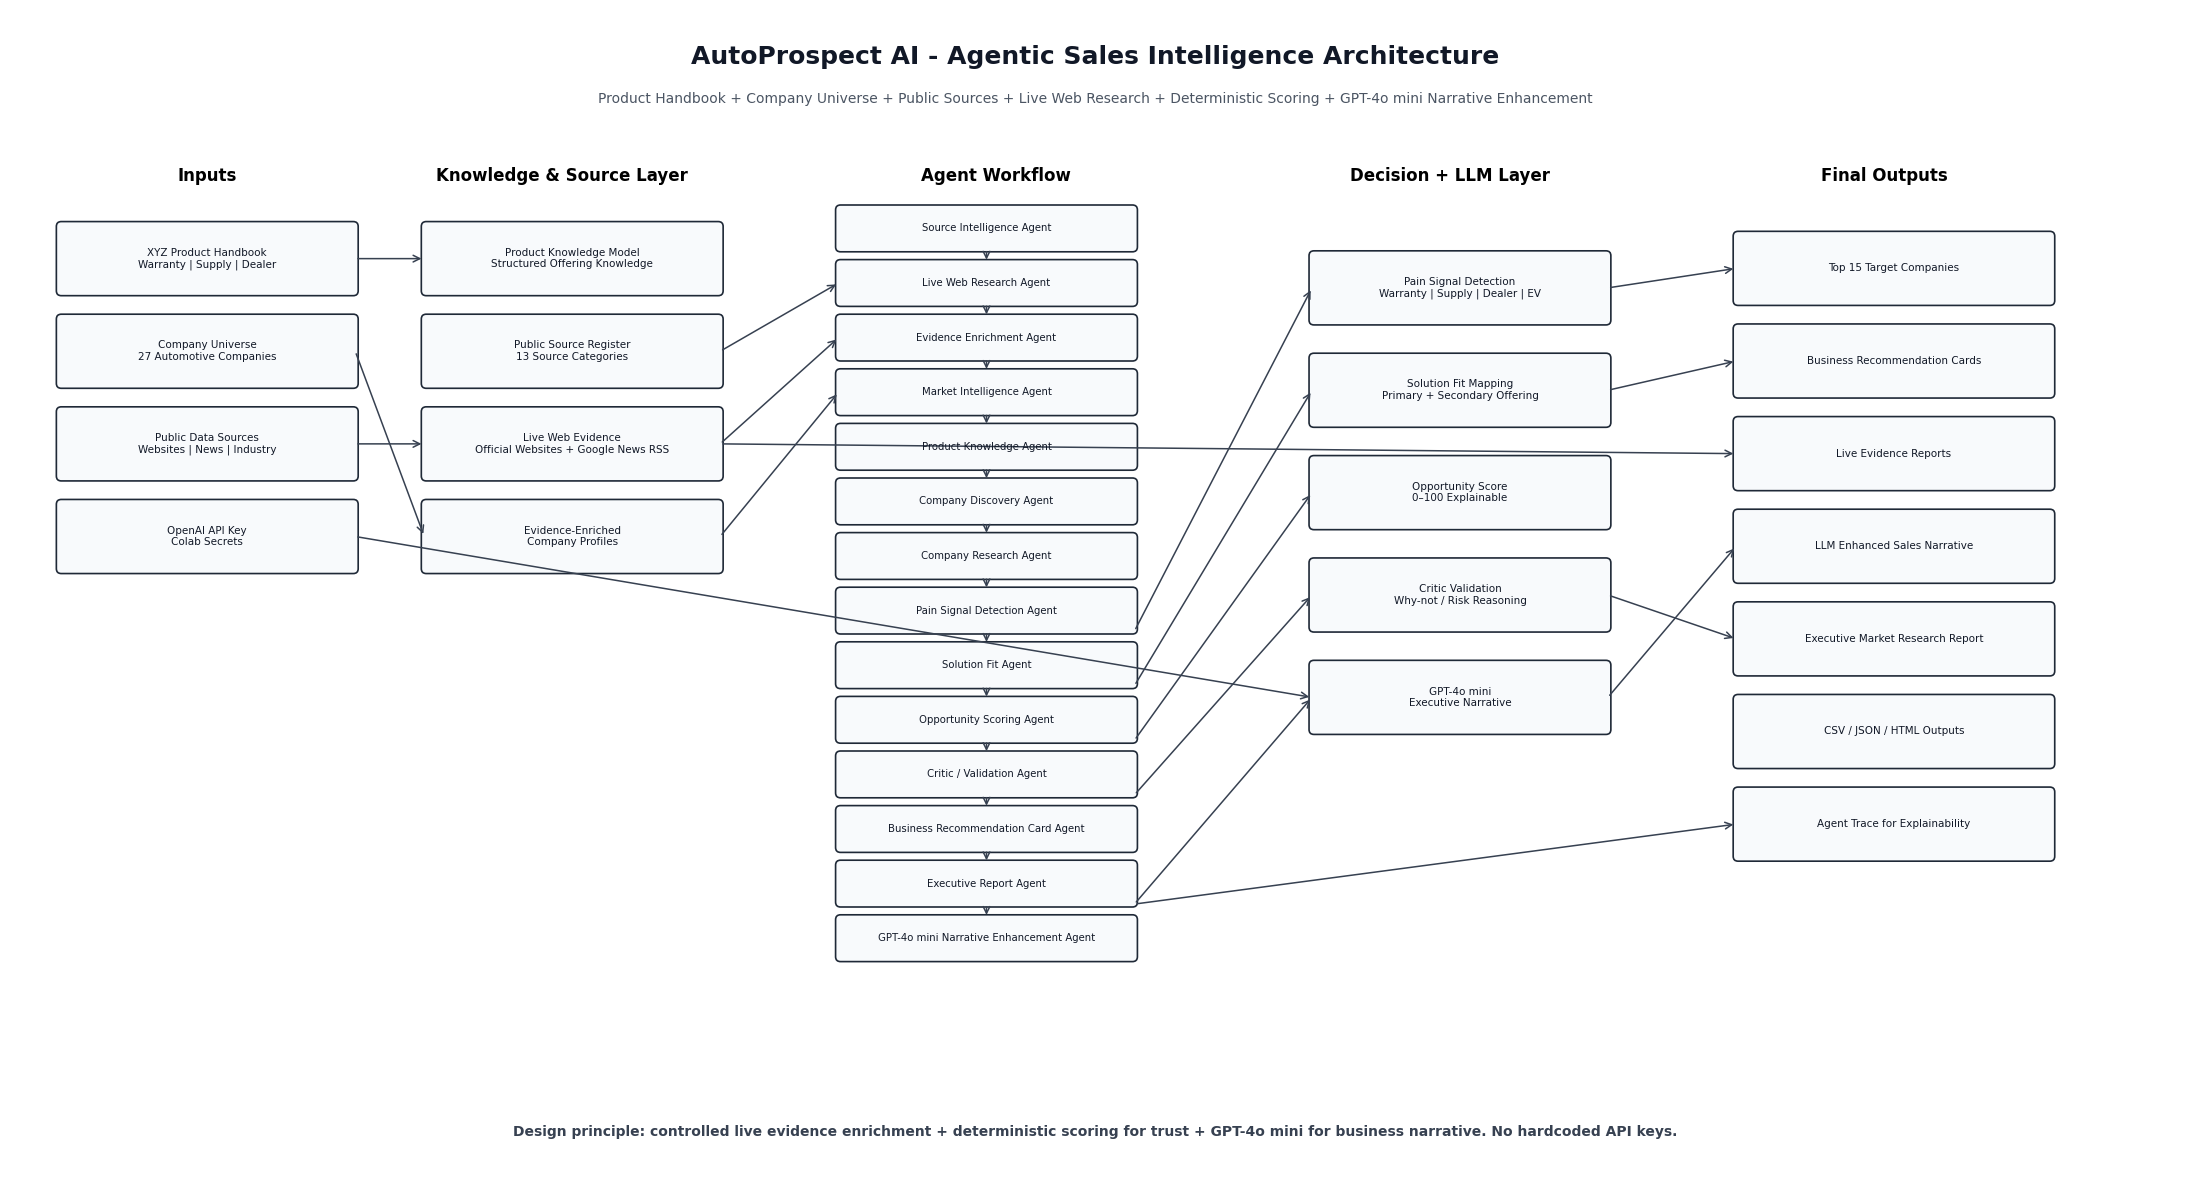

Updated architecture diagram generated: outputs/architecture_diagram.png


In [57]:
# ============================================================
# Updated Architecture Diagram with Live Web Research and GPT-4o mini
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def add_arch_box_v3(ax, x, y, w, h, text, fontsize=7.5):
    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.03,rounding_size=0.05",
        linewidth=1.2,
        edgecolor="#1f2937",
        facecolor="#f8fafc"
    )
    ax.add_patch(box)
    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        wrap=True,
        color="#111827"
    )

def add_arch_arrow_v3(ax, x1, y1, x2, y2):
    arrow = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="->",
        mutation_scale=12,
        linewidth=1.1,
        color="#374151"
    )
    ax.add_patch(arrow)

def generate_final_architecture_diagram(output_path: str):
    fig, ax = plt.subplots(figsize=(22, 12))
    ax.set_xlim(0, 22)
    ax.set_ylim(0, 12)
    ax.axis("off")

    ax.text(
        11,
        11.45,
        "AutoProspect AI - Agentic Sales Intelligence Architecture",
        ha="center",
        fontsize=18,
        fontweight="bold",
        color="#111827"
    )

    ax.text(
        11,
        11.05,
        "Product Handbook + Company Universe + Public Sources + Live Web Research + Deterministic Scoring + GPT-4o mini Narrative Enhancement",
        ha="center",
        fontsize=10,
        color="#4b5563"
    )

    # Headers
    ax.text(2.0, 10.25, "Inputs", ha="center", fontsize=12, fontweight="bold")
    ax.text(5.6, 10.25, "Knowledge & Source Layer", ha="center", fontsize=12, fontweight="bold")
    ax.text(10.0, 10.25, "Agent Workflow", ha="center", fontsize=12, fontweight="bold")
    ax.text(14.6, 10.25, "Decision + LLM Layer", ha="center", fontsize=12, fontweight="bold")
    ax.text(19.0, 10.25, "Final Outputs", ha="center", fontsize=12, fontweight="bold")

    # Inputs
    add_arch_box_v3(ax, 0.5, 9.1, 3.0, 0.7, "XYZ Product Handbook\nWarranty | Supply | Dealer")
    add_arch_box_v3(ax, 0.5, 8.15, 3.0, 0.7, "Company Universe\n27 Automotive Companies")
    add_arch_box_v3(ax, 0.5, 7.2, 3.0, 0.7, "Public Data Sources\nWebsites | News | Industry")
    add_arch_box_v3(ax, 0.5, 6.25, 3.0, 0.7, "OpenAI API Key\nColab Secrets")

    # Knowledge/source layer
    add_arch_box_v3(ax, 4.2, 9.1, 3.0, 0.7, "Product Knowledge Model\nStructured Offering Knowledge")
    add_arch_box_v3(ax, 4.2, 8.15, 3.0, 0.7, "Public Source Register\n13 Source Categories")
    add_arch_box_v3(ax, 4.2, 7.2, 3.0, 0.7, "Live Web Evidence\nOfficial Websites + Google News RSS")
    add_arch_box_v3(ax, 4.2, 6.25, 3.0, 0.7, "Evidence-Enriched\nCompany Profiles")

    # Agents
    agent_x = 8.4
    agent_w = 3.0
    agent_h = 0.42
    start_y = 9.55
    gap = 0.56

    agents = [
        "Source Intelligence Agent",
        "Live Web Research Agent",
        "Evidence Enrichment Agent",
        "Market Intelligence Agent",
        "Product Knowledge Agent",
        "Company Discovery Agent",
        "Company Research Agent",
        "Pain Signal Detection Agent",
        "Solution Fit Agent",
        "Opportunity Scoring Agent",
        "Critic / Validation Agent",
        "Business Recommendation Card Agent",
        "Executive Report Agent",
        "GPT-4o mini Narrative Enhancement Agent"
    ]

    agent_positions = []
    for i, name in enumerate(agents):
        y = start_y - i * gap
        add_arch_box_v3(ax, agent_x, y, agent_w, agent_h, name, fontsize=7.3)
        agent_positions.append((agent_x, y, agent_w, agent_h))

    # Decision layer
    add_arch_box_v3(ax, 13.2, 8.8, 3.0, 0.7, "Pain Signal Detection\nWarranty | Supply | Dealer | EV")
    add_arch_box_v3(ax, 13.2, 7.75, 3.0, 0.7, "Solution Fit Mapping\nPrimary + Secondary Offering")
    add_arch_box_v3(ax, 13.2, 6.7, 3.0, 0.7, "Opportunity Score\n0–100 Explainable")
    add_arch_box_v3(ax, 13.2, 5.65, 3.0, 0.7, "Critic Validation\nWhy-not / Risk Reasoning")
    add_arch_box_v3(ax, 13.2, 4.6, 3.0, 0.7, "GPT-4o mini\nExecutive Narrative")

    # Outputs
    add_arch_box_v3(ax, 17.5, 9.0, 3.2, 0.7, "Top 15 Target Companies")
    add_arch_box_v3(ax, 17.5, 8.05, 3.2, 0.7, "Business Recommendation Cards")
    add_arch_box_v3(ax, 17.5, 7.1, 3.2, 0.7, "Live Evidence Reports")
    add_arch_box_v3(ax, 17.5, 6.15, 3.2, 0.7, "LLM Enhanced Sales Narrative")
    add_arch_box_v3(ax, 17.5, 5.2, 3.2, 0.7, "Executive Market Research Report")
    add_arch_box_v3(ax, 17.5, 4.25, 3.2, 0.7, "CSV / JSON / HTML Outputs")
    add_arch_box_v3(ax, 17.5, 3.3, 3.2, 0.7, "Agent Trace for Explainability")

    # Input to knowledge/source arrows
    add_arch_arrow_v3(ax, 3.5, 9.45, 4.2, 9.45)
    add_arch_arrow_v3(ax, 3.5, 8.5, 4.2, 6.6)
    add_arch_arrow_v3(ax, 3.5, 7.55, 4.2, 7.55)
    add_arch_arrow_v3(ax, 3.5, 6.6, 13.2, 4.95)

    # Knowledge/source to agent workflow
    add_arch_arrow_v3(ax, 7.2, 8.5, 8.4, 9.2)
    add_arch_arrow_v3(ax, 7.2, 7.55, 8.4, 8.64)
    add_arch_arrow_v3(ax, 7.2, 6.6, 8.4, 8.08)

    # Vertical agent workflow
    for i in range(len(agent_positions) - 1):
        x, y, w, h = agent_positions[i]
        x2, y2, w2, h2 = agent_positions[i + 1]
        add_arch_arrow_v3(ax, x + w / 2, y, x2 + w2 / 2, y2 + h2)

    # Agents to decision layer
    add_arch_arrow_v3(ax, 11.4, 5.63, 13.2, 9.15)
    add_arch_arrow_v3(ax, 11.4, 5.07, 13.2, 8.1)
    add_arch_arrow_v3(ax, 11.4, 4.51, 13.2, 7.05)
    add_arch_arrow_v3(ax, 11.4, 3.95, 13.2, 6.0)
    add_arch_arrow_v3(ax, 11.4, 2.83, 13.2, 4.95)

    # Decision to outputs
    add_arch_arrow_v3(ax, 16.2, 9.15, 17.5, 9.35)
    add_arch_arrow_v3(ax, 16.2, 8.1, 17.5, 8.4)
    add_arch_arrow_v3(ax, 7.2, 7.55, 17.5, 7.45)
    add_arch_arrow_v3(ax, 16.2, 4.95, 17.5, 6.5)
    add_arch_arrow_v3(ax, 16.2, 6.0, 17.5, 5.55)
    add_arch_arrow_v3(ax, 11.4, 2.83, 17.5, 3.65)

    ax.text(
        11,
        0.45,
        "Design principle: controlled live evidence enrichment + deterministic scoring for trust + GPT-4o mini for business narrative. No hardcoded API keys.",
        ha="center",
        fontsize=10,
        fontweight="bold",
        color="#374151"
    )

    plt.tight_layout()
    fig.savefig(output_path, dpi=220, bbox_inches="tight")
    plt.show()

    return output_path


architecture_diagram_path = os.path.join(CONFIG["output_dir"], "architecture_diagram.png")
generate_final_architecture_diagram(architecture_diagram_path)

print(f"Updated architecture diagram generated: {architecture_diagram_path}")


In [58]:
# ============================================================
# Export Source Intelligence, Live Evidence, LLM Proof, and Final Reports
# ============================================================
#
# This export cell writes all final Step 9.5 / Step 9.6 artifacts, including
# both the LLM-enhanced recommendations and the runtime proof log.
# ============================================================

os.makedirs(CONFIG["output_dir"], exist_ok=True)

source_register_csv_path = os.path.join(CONFIG["output_dir"], "public_source_register.csv")
company_source_mapping_csv_path = os.path.join(CONFIG["output_dir"], "company_source_mapping_top15.csv")
llm_enhanced_csv_path = os.path.join(CONFIG["output_dir"], "top15_llm_enhanced_recommendations.csv")
llm_enhanced_json_path = os.path.join(CONFIG["output_dir"], "top15_llm_enhanced_recommendations.json")
llm_runtime_proof_csv_path = os.path.join(CONFIG["output_dir"], "llm_runtime_proof.csv")
llm_runtime_proof_json_path = os.path.join(CONFIG["output_dir"], "llm_runtime_proof.json")
executive_report_md_path = os.path.join(CONFIG["output_dir"], "executive_market_research_report.md")
executive_report_html_path = os.path.join(CONFIG["output_dir"], "executive_market_research_report.html")
agent_trace_step9_5_path = os.path.join(CONFIG["output_dir"], "agent_trace_step9_5.json")
agent_trace_step9_6_path = os.path.join(CONFIG["output_dir"], "agent_trace_step9_6.json")
final_submission_summary_path = os.path.join(CONFIG["output_dir"], "final_submission_summary.json")

# Export source register.
public_source_register_df.to_csv(source_register_csv_path, index=False)

# Export company-source mapping in CSV-friendly format.
company_source_mapping_export_df = company_source_mapping_df.copy()

for col in [
    "company_profile_sources",
    "financial_validation_sources",
    "industry_research_sources",
    "business_news_sources"
]:
    if col in company_source_mapping_export_df.columns:
        company_source_mapping_export_df[col] = company_source_mapping_export_df[col].apply(
            lambda x: "; ".join(x) if isinstance(x, list) else x
        )

company_source_mapping_export_df.to_csv(company_source_mapping_csv_path, index=False)

# Export LLM enhanced recommendations.
llm_export_df = llm_enhanced_recommendations_df.copy()

list_like_columns = [
    "business_challenges",
    "key_xyz_capabilities",
    "relevant_kpis",
    "suggested_stakeholders",
    "llm_discovery_questions",
    "llm_data_sources_to_validate"
]

for col in list_like_columns:
    if col in llm_export_df.columns:
        llm_export_df[col] = llm_export_df[col].apply(
            lambda x: "; ".join(x) if isinstance(x, list) else x
        )

llm_export_df.to_csv(llm_enhanced_csv_path, index=False)

with open(llm_enhanced_json_path, "w", encoding="utf-8") as f:
    json.dump(llm_enhanced_recommendations_df.to_dict(orient="records"), f, indent=4, ensure_ascii=False)

# Export LLM runtime proof.
llm_usage_log_df = agent_state.get("llm_usage_log_df", pd.DataFrame()).copy()
llm_usage_log_df.to_csv(llm_runtime_proof_csv_path, index=False)

with open(llm_runtime_proof_json_path, "w", encoding="utf-8") as f:
    json.dump(llm_usage_log_df.to_dict(orient="records"), f, indent=4, ensure_ascii=False)

# Export updated executive report.
with open(executive_report_md_path, "w", encoding="utf-8") as f:
    f.write(agent_state["executive_market_research_report_md"])

executive_report_html = f"""
<html>
<head>
    <meta charset="utf-8">
    <title>AutoProspect AI - Executive Market Research Report</title>
    <style>
        body {{
            font-family: Arial, sans-serif;
            margin: 40px;
            line-height: 1.55;
            color: #1f2937;
        }}
        h1, h2, h3 {{
            color: #111827;
        }}
        table {{
            border-collapse: collapse;
            width: 100%;
            margin: 16px 0;
        }}
        th, td {{
            border: 1px solid #d1d5db;
            padding: 8px;
            text-align: left;
        }}
        th {{
            background-color: #f3f4f6;
        }}
        pre {{
            white-space: pre-wrap;
            font-family: Arial, sans-serif;
        }}
    </style>
</head>
<body>
<pre>{agent_state["executive_market_research_report_md"]}</pre>
</body>
</html>
"""

with open(executive_report_html_path, "w", encoding="utf-8") as f:
    f.write(executive_report_html)

completed_llm_calls = int((llm_usage_log_df["status"] == "Completed").sum()) if not llm_usage_log_df.empty else 0
total_llm_tokens = int(llm_usage_log_df["total_tokens"].sum()) if not llm_usage_log_df.empty else 0
llm_runtime_session_id = (
    llm_usage_log_df["runtime_session_id"].dropna().iloc[0]
    if not llm_usage_log_df.empty and "runtime_session_id" in llm_usage_log_df.columns
    else LLM_RUNTIME_SESSION_ID
)

# Update final submission summary.
final_submission_summary.update({
    "llm_enabled": LLM_AVAILABLE,
    "llm_provider": "OpenAI",
    "model_name": CONFIG["model_name"],
    "llm_runtime_session_id": llm_runtime_session_id,
    "llm_completed_calls": completed_llm_calls,
    "llm_total_tokens": total_llm_tokens,
    "agent_orchestration": "Custom lightweight multi-agent orchestration implemented in Python",
    "agents_executed": len(agent_state["agent_trace"]),
    "source_register_created": True,
    "company_source_mapping_created": True,
    "live_web_research_enabled": CONFIG.get("use_live_web_research", False),
    "live_web_evidence_rows": len(agent_state.get("live_web_research_evidence_df", pd.DataFrame())),
    "llm_enhancement_output_created": True,
    "llm_runtime_proof_created": True,
    "architecture_diagram_updated_for_llm": os.path.exists(architecture_diagram_path),
    "agent_trace_file": "agent_trace_step9_6.json",
    "status": "Final run completed with live web research, evidence enrichment, GPT-4o mini enhancement, runtime proof, and 14-agent trace."
})

additional_outputs = [
    "public_source_register.csv",
    "company_source_mapping_top15.csv",
    "live_web_research_evidence.csv",
    "company_live_evidence_summary.csv",
    "web_scraping_status_report.csv",
    "top15_llm_enhanced_recommendations.csv",
    "top15_llm_enhanced_recommendations.json",
    "llm_runtime_proof.csv",
    "llm_runtime_proof.json",
    "agent_trace_step9_5.json",
    "agent_trace_step9_6.json"
]

for output_name in additional_outputs:
    if output_name not in final_submission_summary["final_outputs"]:
        final_submission_summary["final_outputs"].append(output_name)

with open(final_submission_summary_path, "w", encoding="utf-8") as f:
    json.dump(final_submission_summary, f, indent=4, ensure_ascii=False)

# Export full 14-agent trace under both names:
# - Step 9.5 name is kept for backward compatibility.
# - Step 9.6 name is the final production trace name.
with open(agent_trace_step9_5_path, "w", encoding="utf-8") as f:
    json.dump(agent_state["agent_trace"], f, indent=4, ensure_ascii=False)

with open(agent_trace_step9_6_path, "w", encoding="utf-8") as f:
    json.dump(agent_state["agent_trace"], f, indent=4, ensure_ascii=False)

print(f"Public source register exported to: {source_register_csv_path}")
print(f"Company source mapping exported to: {company_source_mapping_csv_path}")
print(f"LLM enhanced CSV exported to: {llm_enhanced_csv_path}")
print(f"LLM enhanced JSON exported to: {llm_enhanced_json_path}")
print(f"LLM runtime proof CSV exported to: {llm_runtime_proof_csv_path}")
print(f"LLM runtime proof JSON exported to: {llm_runtime_proof_json_path}")
print(f"Updated executive report Markdown exported to: {executive_report_md_path}")
print(f"Updated executive report HTML exported to: {executive_report_html_path}")
print(f"Updated architecture diagram available at: {architecture_diagram_path}")
print(f"Final submission summary updated at: {final_submission_summary_path}")
print(f"Agent trace exported to: {agent_trace_step9_6_path}")


Public source register exported to: outputs/public_source_register.csv
Company source mapping exported to: outputs/company_source_mapping_top15.csv
LLM enhanced CSV exported to: outputs/top15_llm_enhanced_recommendations.csv
LLM enhanced JSON exported to: outputs/top15_llm_enhanced_recommendations.json
LLM runtime proof CSV exported to: outputs/llm_runtime_proof.csv
LLM runtime proof JSON exported to: outputs/llm_runtime_proof.json
Updated executive report Markdown exported to: outputs/executive_market_research_report.md
Updated executive report HTML exported to: outputs/executive_market_research_report.html
Updated architecture diagram available at: outputs/architecture_diagram.png
Final submission summary updated at: outputs/final_submission_summary.json
Agent trace exported to: outputs/agent_trace_step9_6.json


### Step 9.5 Completion Notes

This section closes the main hackathon compliance gaps.

The solution now includes:

- Public data source register aligned with the hackathon guideline
- Controlled live web research from official company websites and Google News RSS
- Evidence enrichment of company profiles before scoring
- Company-wise source mapping for Top 15 prospects
- Safe GPT-4o mini integration using Colab Secrets
- LLM Narrative Enhancement Agent
- LLM-enhanced sales intelligence output
- Updated executive report
- Updated live-evidence and LLM-aware architecture diagram
- Updated final submission summary

The solution uses deterministic scoring for transparent ranking and GPT-4o mini for business narrative enhancement.


## 10. Final Quality Check

This section validates that the notebook has generated all key hackathon deliverables.

The final quality check verifies:

- Product knowledge output
- Company universe output
- Public source register
- Live web research evidence
- Company live evidence summary
- Company source mapping
- Opportunity scoring output
- Top 15 target companies
- Business recommendation cards
- GPT-4o mini enhanced recommendations
- Executive market research report
- Architecture diagram
- Final submission summary
- Agent trace for explainability

The notebook uses Google Colab, custom lightweight multi-agent orchestration, controlled live web research, safe OpenAI API key handling through Colab Secrets, deterministic scoring, and GPT-4o mini narrative enhancement.


In [59]:
# ============================================================
# Final Output File Validation
# ============================================================
#
# This validation is intentionally file-based because hackathon reviewers will
# inspect generated artifacts from the outputs/ folder and GitHub repository.
# ============================================================

required_output_files = [
    "product_knowledge.json",
    "company_universe.csv",
    "company_universe.json",
    "public_source_register.csv",
    "live_web_research_evidence.csv",
    "company_live_evidence_summary.csv",
    "web_scraping_status_report.csv",
    "company_source_mapping_top15.csv",
    "opportunity_pipeline_all_companies.csv",
    "top15_target_companies.csv",
    "critic_validation_output.csv",
    "top15_recommendation_cards.csv",
    "top15_recommendation_cards.json",
    "top15_recommendation_cards.html",
    "top15_llm_enhanced_recommendations.csv",
    "top15_llm_enhanced_recommendations.json",
    "llm_runtime_proof.csv",
    "llm_runtime_proof.json",
    "executive_market_research_report.md",
    "executive_market_research_report.html",
    "architecture_diagram.png",
    "architecture_summary.md",
    "final_submission_summary.json",
    "agent_trace_step9_6.json"
]

file_check_rows = []

for file_name in required_output_files:
    file_path = os.path.join(CONFIG["output_dir"], file_name)
    file_check_rows.append({
        "file_name": file_name,
        "expected_path": file_path,
        "exists": os.path.exists(file_path),
        "file_size_bytes": os.path.getsize(file_path) if os.path.exists(file_path) else 0
    })

final_file_check_df = pd.DataFrame(file_check_rows)

display(final_file_check_df)

missing_files = final_file_check_df[final_file_check_df["exists"] == False]

if missing_files.empty:
    print("✅ All required output files are present.")
else:
    print("❌ Missing files detected:")
    display(missing_files)


,file_name,expected_path,exists,file_size_bytes
0,product_knowledge.json,outputs/product_knowledge.json,True,6838
1,company_universe.csv,outputs/company_universe.csv,True,17943
2,company_universe.json,outputs/company_universe.json,True,36275
3,public_source_register.csv,outputs/public_source_register.csv,True,2539
4,live_web_research_evidence.csv,outputs/live_web_research_evidence.csv,True,61491
5,company_live_evidence_summary.csv,outputs/company_live_evidence_summary.csv,True,40331
6,web_scraping_status_report.csv,outputs/web_scraping_status_report.csv,True,132
7,company_source_mapping_top15.csv,outputs/company_source_mapping_top15.csv,True,8667
8,opportunity_pipeline_all_companies.csv,outputs/opportunity_pipeline_all_companies.csv,True,48209
9,top15_target_companies.csv,outputs/top15_target_companies.csv,True,27117


✅ All required output files are present.


In [60]:
# ============================================================
# Final Solution Quality Summary
# ============================================================
#
# This summarizes the final run in a single reviewer-friendly table.
# ============================================================

llm_rows = len(agent_state.get("llm_enhanced_recommendations_df", pd.DataFrame()))
llm_execution_modes = []

if "llm_enhanced_recommendations_df" in agent_state:
    llm_execution_modes = (
        agent_state["llm_enhanced_recommendations_df"]["llm_execution_mode"]
        .dropna()
        .unique()
        .tolist()
    )

llm_usage_log_df = agent_state.get("llm_usage_log_df", pd.DataFrame())
llm_completed_calls = int((llm_usage_log_df["status"] == "Completed").sum()) if not llm_usage_log_df.empty else 0
llm_total_tokens = int(llm_usage_log_df["total_tokens"].sum()) if not llm_usage_log_df.empty else 0
llm_request_ids = int(llm_usage_log_df["request_id"].fillna("").astype(str).str.len().gt(0).sum()) if not llm_usage_log_df.empty else 0
llm_runtime_sessions = (
    ", ".join(llm_usage_log_df["runtime_session_id"].dropna().unique().tolist())
    if not llm_usage_log_df.empty and "runtime_session_id" in llm_usage_log_df.columns
    else ""
)

live_evidence_rows = len(agent_state.get("live_web_research_evidence_df", pd.DataFrame()))
live_evidence_companies = 0
if "company_live_evidence_summary_df" in agent_state and not agent_state["company_live_evidence_summary_df"].empty:
    live_evidence_companies = int(agent_state["company_live_evidence_summary_df"]["live_evidence_available"].sum())

final_quality_summary = {
    "project_name": CONFIG["project_name"],
    "run_mode": CONFIG["run_mode"],
    "candidate_companies_analyzed": len(company_universe_df),
    "product_solutions_loaded": len(product_knowledge),
    "public_source_categories_registered": len(public_source_register_df),
    "live_web_research_enabled": CONFIG.get("use_live_web_research", False),
    "live_web_evidence_rows": live_evidence_rows,
    "companies_with_live_evidence": live_evidence_companies,
    "company_source_mappings_created": len(company_source_mapping_df),
    "agents_executed": len(agent_state["agent_trace"]),
    "top15_companies_generated": len(agent_state["recommendation_cards_df"]),
    "llm_enabled": CONFIG["use_llm"],
    "llm_model": CONFIG["model_name"],
    "llm_enhanced_rows": llm_rows,
    "llm_execution_modes": ", ".join(llm_execution_modes),
    "llm_runtime_session_id": llm_runtime_sessions,
    "llm_completed_calls": llm_completed_calls,
    "llm_request_ids_captured": llm_request_ids,
    "llm_total_tokens": llm_total_tokens,
    "hot_prospects": len(agent_state["recommendation_cards_df"][agent_state["recommendation_cards_df"]["priority"] == "Hot"]),
    "warm_prospects": len(agent_state["recommendation_cards_df"][agent_state["recommendation_cards_df"]["priority"] == "Warm"]),
    "executive_report_generated": "executive_market_research_report_md" in agent_state,
    "architecture_diagram_generated": os.path.exists(os.path.join(CONFIG["output_dir"], "architecture_diagram.png")),
    "notebook_status": "Ready for final review and GitHub packaging"
}

final_quality_df = pd.DataFrame([final_quality_summary])
display(final_quality_df)


,project_name,run_mode,candidate_companies_analyzed,product_solutions_loaded,public_source_categories_registered,live_web_research_enabled,live_web_evidence_rows,companies_with_live_evidence,company_source_mappings_created,agents_executed,...,llm_execution_modes,llm_runtime_session_id,llm_completed_calls,llm_request_ids_captured,llm_total_tokens,hot_prospects,warm_prospects,executive_report_generated,architecture_diagram_generated,notebook_status
0,AutoProspect AI,DEMO,27,3,13,True,54,27,15,14,...,GPT-4o mini,llm_run_20260704T051613Z_041383f3,15,15,17711,7,8,True,True,Ready for final review and GitHub packaging


In [61]:
# ============================================================
# Final Hackathon Deliverable Checklist
# ============================================================

deliverable_checklist = [
    {
        "deliverable": "Working AI Agent Demonstration",
        "status": "Completed",
        "evidence": "Notebook executes 14-agent workflow with agent trace"
    },
    {
        "deliverable": "Google Colab Notebook",
        "status": "Completed",
        "evidence": "AutoProspect_AI_Hackathon.ipynb"
    },
    {
        "deliverable": "Product Knowledge Handbook Usage",
        "status": "Completed",
        "evidence": "Structured product_knowledge.json with Warranty, Supply Chain, Dealer Intelligence"
    },
    {
        "deliverable": "Public Data Source Usage",
        "status": "Completed",
        "evidence": "public_source_register.csv and company_source_mapping_top15.csv"
    },
    {
        "deliverable": "Live Web Research Evidence",
        "status": "Completed",
        "evidence": "live_web_research_evidence.csv, company_live_evidence_summary.csv, web_scraping_status_report.csv"
    },
    {
        "deliverable": "LLM Usage",
        "status": "Completed",
        "evidence": "GPT-4o mini used for 15 recommendation narratives with request IDs and token proof in llm_runtime_proof.csv"
    },
    {
        "deliverable": "Agentic AI Workflow",
        "status": "Completed",
        "evidence": "Custom lightweight multi-agent orchestration with 14 agents and trace in agent_trace_step9_6.json"
    },
    {
        "deliverable": "Market Research Report",
        "status": "Completed",
        "evidence": "executive_market_research_report.md and .html"
    },
    {
        "deliverable": "Top 10–15 Target Companies",
        "status": "Completed",
        "evidence": "top15_target_companies.csv"
    },
    {
        "deliverable": "Business Recommendations",
        "status": "Completed",
        "evidence": "top15_recommendation_cards.csv / .html"
    },
    {
        "deliverable": "LLM Enhanced Sales Narrative",
        "status": "Completed",
        "evidence": "top15_llm_enhanced_recommendations.csv / .json"
    },
    {
        "deliverable": "Architecture Diagram",
        "status": "Completed",
        "evidence": "architecture_diagram.png"
    },
    {
        "deliverable": "No Hardcoded API Keys",
        "status": "Completed",
        "evidence": "OpenAI API key read through Colab Secrets"
    },
    {
        "deliverable": "README Documentation",
        "status": "Pending GitHub packaging",
        "evidence": "Will be updated in Step 10B"
    }
]

deliverable_checklist_df = pd.DataFrame(deliverable_checklist)
deliverable_checklist_df


,deliverable,status,evidence
0,Working AI Agent Demonstration,Completed,Notebook executes 14-agent workflow with agent...
1,Google Colab Notebook,Completed,AutoProspect_AI_Hackathon.ipynb
2,Product Knowledge Handbook Usage,Completed,Structured product_knowledge.json with Warrant...
3,Public Data Source Usage,Completed,public_source_register.csv and company_source_...
4,Live Web Research Evidence,Completed,"live_web_research_evidence.csv, company_live_e..."
5,LLM Usage,Completed,GPT-4o mini used for 15 recommendation narrati...
6,Agentic AI Workflow,Completed,Custom lightweight multi-agent orchestration w...
7,Market Research Report,Completed,executive_market_research_report.md and .html
8,Top 10–15 Target Companies,Completed,top15_target_companies.csv
9,Business Recommendations,Completed,top15_recommendation_cards.csv / .html


In [62]:
# ============================================================
# Export Final QA Summary
# ============================================================

os.makedirs(CONFIG["output_dir"], exist_ok=True)

final_quality_summary_path = os.path.join(CONFIG["output_dir"], "final_quality_summary.json")
deliverable_checklist_path = os.path.join(CONFIG["output_dir"], "final_deliverable_checklist.csv")

with open(final_quality_summary_path, "w", encoding="utf-8") as f:
    json.dump(final_quality_summary, f, indent=4, ensure_ascii=False)

deliverable_checklist_df.to_csv(deliverable_checklist_path, index=False)

print(f"Final quality summary exported to: {final_quality_summary_path}")
print(f"Final deliverable checklist exported to: {deliverable_checklist_path}")

Final quality summary exported to: outputs/final_quality_summary.json
Final deliverable checklist exported to: outputs/final_deliverable_checklist.csv


### Final Quality Check Notes

The notebook has generated the complete hackathon solution:

Product Knowledge → Company Universe → Public Source Register → Live Web Research → Evidence Enrichment → Agent Workflow → Opportunity Scoring → Critic Validation → Recommendation Cards → GPT-4o mini Narrative Enhancement → Runtime Proof → Executive Report → Architecture Diagram → Final Quality Check

The solution is ready for final run, review, and GitHub packaging.

Key design principles:

- Google Colab-first implementation
- Controlled live web research with timeout and fallback logic
- Safe OpenAI API handling through Colab Secrets
- Custom lightweight multi-agent orchestration
- Deterministic scoring for explainability
- GPT-4o mini for executive narrative enhancement
- Runtime proof through request IDs, token usage, and session ID
- Public data-source mapping aligned with hackathon guidelines
- Output files generated in CSV, JSON, HTML, Markdown, and PNG formats


In [63]:
# ============================================================
# Final Runtime Verification: Live Web + GPT-4o mini + Outputs
# ============================================================
#
# Run this cell after Runtime -> Run all.
#
# PASS means:
# - live web evidence was generated
# - GPT-4o mini completed 15 fresh calls
# - request IDs and token usage were captured
# - all final artifacts exist
# - the final 14-agent trace is available
# ============================================================

import os
import json
import pandas as pd
from datetime import datetime

print("=" * 80)
print("AUTOPROSPECT AI - FINAL RUNTIME VERIFICATION")
print("=" * 80)

# ------------------------------------------------------------
# 1. Check final output files
# ------------------------------------------------------------

verification_files = {
    "Live Web Evidence": "live_web_research_evidence.csv",
    "Company Live Evidence Summary": "company_live_evidence_summary.csv",
    "Web Scraping Status Report": "web_scraping_status_report.csv",
    "Top 15 Target Companies": "top15_target_companies.csv",
    "LLM Enhanced Recommendations": "top15_llm_enhanced_recommendations.csv",
    "LLM Runtime Proof CSV": "llm_runtime_proof.csv",
    "LLM Runtime Proof JSON": "llm_runtime_proof.json",
    "Executive Market Research Report": "executive_market_research_report.md",
    "Architecture Diagram": "architecture_diagram.png",
    "Final Quality Summary": "final_quality_summary.json",
    "Final Submission Summary": "final_submission_summary.json",
    "Agent Trace Step 9.6": "agent_trace_step9_6.json",
}

file_rows = []

for label, file_name in verification_files.items():
    path = os.path.join(CONFIG["output_dir"], file_name)
    exists = os.path.exists(path)
    file_rows.append({
        "artifact": label,
        "file_name": file_name,
        "exists": exists,
        "size_bytes": os.path.getsize(path) if exists else 0,
        "last_modified": datetime.fromtimestamp(os.path.getmtime(path)).strftime("%Y-%m-%d %H:%M:%S") if exists else None
    })

file_verification_df = pd.DataFrame(file_rows)
display(file_verification_df)

# ------------------------------------------------------------
# 2. Check live web research evidence
# ------------------------------------------------------------

live_evidence_path = os.path.join(CONFIG["output_dir"], "live_web_research_evidence.csv")
evidence_summary_path = os.path.join(CONFIG["output_dir"], "company_live_evidence_summary.csv")
scraping_status_path = os.path.join(CONFIG["output_dir"], "web_scraping_status_report.csv")

live_web_confirmed = False

if os.path.exists(live_evidence_path):
    live_evidence_df_check = pd.read_csv(live_evidence_path)
    live_web_confirmed = len(live_evidence_df_check) > 0

    print("\nLIVE WEB RESEARCH CHECK")
    print("Live evidence rows:", len(live_evidence_df_check))
    print("Unique companies in live evidence:", live_evidence_df_check["company_name"].nunique() if "company_name" in live_evidence_df_check.columns else "Column missing")
    display(live_evidence_df_check.head(10))
else:
    live_evidence_df_check = pd.DataFrame()
    print("\n❌ live_web_research_evidence.csv not found")

if os.path.exists(evidence_summary_path):
    evidence_summary_df_check = pd.read_csv(evidence_summary_path)
    print("\nEVIDENCE SUMMARY CHECK")
    print("Company evidence summary rows:", len(evidence_summary_df_check))
    display(evidence_summary_df_check.head(10))
else:
    evidence_summary_df_check = pd.DataFrame()
    print("\n❌ company_live_evidence_summary.csv not found")

if os.path.exists(scraping_status_path):
    scraping_status_df_check = pd.read_csv(scraping_status_path)
    print("\nWEB SCRAPING STATUS CHECK")
    print("Scraping status rows:", len(scraping_status_df_check))
    display(scraping_status_df_check.head(10))
else:
    scraping_status_df_check = pd.DataFrame()
    print("\n❌ web_scraping_status_report.csv not found")

# ------------------------------------------------------------
# 3. Check GPT-4o mini enhanced recommendation output
# ------------------------------------------------------------

llm_output_path = os.path.join(CONFIG["output_dir"], "top15_llm_enhanced_recommendations.csv")
llm_runtime_proof_path = os.path.join(CONFIG["output_dir"], "llm_runtime_proof.csv")

llm_output_confirmed = False
llm_runtime_confirmed = False

if os.path.exists(llm_output_path):
    llm_output_df_check = pd.read_csv(llm_output_path)

    print("\nGPT-4o mini OUTPUT CHECK")
    print("LLM enhanced rows:", len(llm_output_df_check))

    if "llm_execution_mode" in llm_output_df_check.columns:
        print("LLM execution modes:", llm_output_df_check["llm_execution_mode"].dropna().unique().tolist())
    else:
        print("❌ llm_execution_mode column missing")

    required_llm_columns = [
        "llm_executive_pitch",
        "llm_business_justification",
        "llm_personalized_outreach_angle",
        "llm_discovery_questions",
        "llm_execution_mode",
        "llm_request_id",
        "llm_total_tokens"
    ]

    missing_llm_columns = [col for col in required_llm_columns if col not in llm_output_df_check.columns]

    if not missing_llm_columns:
        non_empty_pitch_count = llm_output_df_check["llm_executive_pitch"].fillna("").str.len().gt(20).sum()
        rows_with_request_id = llm_output_df_check["llm_request_id"].fillna("").astype(str).str.len().gt(0).sum()
        total_tokens_from_output = int(llm_output_df_check["llm_total_tokens"].fillna(0).sum())

        print("Rows with non-empty LLM executive pitch:", non_empty_pitch_count)
        print("Rows with captured request ID:", rows_with_request_id)
        print("Total tokens from LLM output:", total_tokens_from_output)

        llm_output_confirmed = (
            len(llm_output_df_check) == CONFIG["target_company_count"]
            and "GPT-4o mini" in llm_output_df_check["llm_execution_mode"].dropna().unique().tolist()
            and non_empty_pitch_count == CONFIG["target_company_count"]
            and rows_with_request_id == CONFIG["target_company_count"]
            and total_tokens_from_output > 0
        )

        display(llm_output_df_check[
            [
                "rank",
                "company_name",
                "primary_solution",
                "llm_execution_mode",
                "llm_request_id",
                "llm_total_tokens",
                "llm_executive_pitch"
            ]
        ].head(5))
    else:
        print("❌ Missing LLM columns:", missing_llm_columns)
else:
    llm_output_df_check = pd.DataFrame()
    print("\n❌ top15_llm_enhanced_recommendations.csv not found")

# ------------------------------------------------------------
# 4. Check GPT-4o mini runtime proof log
# ------------------------------------------------------------

if os.path.exists(llm_runtime_proof_path):
    llm_runtime_df_check = pd.read_csv(llm_runtime_proof_path)

    print("\nGPT-4o mini RUNTIME PROOF CHECK")
    print("Runtime proof rows:", len(llm_runtime_df_check))

    if not llm_runtime_df_check.empty:
        runtime_sessions = llm_runtime_df_check["runtime_session_id"].dropna().unique().tolist()
        completed_calls = int((llm_runtime_df_check["status"] == "Completed").sum())
        request_ids_captured = int(llm_runtime_df_check["request_id"].fillna("").astype(str).str.len().gt(0).sum())
        total_tokens_runtime = int(llm_runtime_df_check["total_tokens"].fillna(0).sum())

        print("Runtime session ID(s):", runtime_sessions)
        print("Completed GPT-4o mini calls:", completed_calls)
        print("Request IDs captured:", request_ids_captured)
        print("Total tokens captured:", total_tokens_runtime)

        llm_runtime_confirmed = (
            completed_calls == CONFIG["target_company_count"]
            and request_ids_captured == CONFIG["target_company_count"]
            and total_tokens_runtime > 0
        )

        display(llm_runtime_df_check)
else:
    llm_runtime_df_check = pd.DataFrame()
    print("\n❌ llm_runtime_proof.csv not found")

# ------------------------------------------------------------
# 5. Check agent trace
# ------------------------------------------------------------

agent_trace_path = os.path.join(CONFIG["output_dir"], "agent_trace_step9_6.json")
agent_trace_confirmed = False

if os.path.exists(agent_trace_path):
    with open(agent_trace_path, "r", encoding="utf-8") as f:
        trace_data = json.load(f)

    agent_names = [entry.get("agent_name", "") for entry in trace_data]

    print("\nAGENT TRACE CHECK")
    print("Agent trace file:", agent_trace_path)
    print("Total agents in trace:", len(agent_names))
    print("Agent names:")
    for agent_name in agent_names:
        print("-", agent_name)

    expected_agents = [
        "Source Intelligence Agent",
        "Live Web Research Agent",
        "Evidence Enrichment Agent",
        "Market Intelligence Agent",
        "Product Knowledge Agent",
        "Company Discovery Agent",
        "Company Research Agent",
        "Pain Signal Detection Agent",
        "Solution Fit Agent",
        "Opportunity Scoring Agent",
        "Critic / Validation Agent",
        "Business Recommendation Card Agent",
        "Executive Market Research Report Agent",
        "LLM Narrative Enhancement Agent"
    ]

    missing_agents = [agent for agent in expected_agents if agent not in agent_names]
    agent_trace_confirmed = len(missing_agents) == 0 and len(agent_names) >= 14

    if agent_trace_confirmed:
        print("✅ Live web, scoring, report, and LLM agents are present in trace.")
    else:
        print("❌ Missing expected agents:", missing_agents)
else:
    print("\n❌ agent_trace_step9_6.json not found")

# ------------------------------------------------------------
# 6. Final pass/fail summary
# ------------------------------------------------------------

print("\nCONFIG CHECK")
print("CONFIG use_llm:", CONFIG.get("use_llm"))
print("CONFIG model_name:", CONFIG.get("model_name"))

all_core_files_exist = file_verification_df["exists"].all()

print("\nFINAL VERIFICATION RESULT")
print("All core files exist:", all_core_files_exist)
print("Live web confirmed:", live_web_confirmed)
print("LLM output confirmed:", llm_output_confirmed)
print("LLM runtime proof confirmed:", llm_runtime_confirmed)
print("Agent trace confirmed:", agent_trace_confirmed)

if all_core_files_exist and live_web_confirmed and llm_output_confirmed and llm_runtime_confirmed and agent_trace_confirmed:
    print("✅ PASS: Notebook generated live web evidence, fresh GPT-4o mini enhanced output, runtime proof, 14-agent trace, and final artifacts.")
else:
    print("⚠️ REVIEW NEEDED: One or more final checks did not pass. Review the booleans above.")


AUTOPROSPECT AI - FINAL RUNTIME VERIFICATION


,artifact,file_name,exists,size_bytes,last_modified
0,Live Web Evidence,live_web_research_evidence.csv,True,61491,2026-07-04 05:16:02
1,Company Live Evidence Summary,company_live_evidence_summary.csv,True,40331,2026-07-04 05:16:02
2,Web Scraping Status Report,web_scraping_status_report.csv,True,132,2026-07-04 05:16:02
3,Top 15 Target Companies,top15_target_companies.csv,True,27117,2026-07-04 05:16:03
4,LLM Enhanced Recommendations,top15_llm_enhanced_recommendations.csv,True,78671,2026-07-04 05:17:29
5,LLM Runtime Proof CSV,llm_runtime_proof.csv,True,2681,2026-07-04 05:17:29
6,LLM Runtime Proof JSON,llm_runtime_proof.json,True,7085,2026-07-04 05:17:29
7,Executive Market Research Report,executive_market_research_report.md,True,36210,2026-07-04 05:17:29
8,Architecture Diagram,architecture_diagram.png,True,647594,2026-07-04 05:17:28
9,Final Quality Summary,final_quality_summary.json,True,903,2026-07-04 05:17:29



LIVE WEB RESEARCH CHECK
Live evidence rows: 54
Unique companies in live evidence: 27


,company_name,source_name,source_url,source_type,fetch_status,http_status,page_title,meta_description,headings,evidence_snippet,evidence_keywords,error
0,Maruti Suzuki India,Official Company Website,https://www.marutisuzuki.com,Company Information,Success,200.0,Maruti Suzuki India Corporate - Discover Arena...,Explore Maruti Suzuki India and get exclusive ...,Maruti Suzuki India Business Channels | More f...,Maruti Suzuki India Corporate - Discover Arena...,[],NaN
1,Ashok Leyland,Official Company Website,https://www.ashokleyland.com,Company Information,Failed,403.0,NaN,NaN,NaN,NaN,[],HTTP status 403
2,Mahindra & Mahindra,Official Company Website,https://www.mahindra.com,Company Information,Success,200.0,The Mahindra Group Official Website | Together...,"A technology & innovation-led, global, federat...","Purpose Led, Performance Driven, Future Ready ...",The Mahindra Group Official Website | Together...,"['dealer', 'electric', 'mobility', 'service']",NaN
3,Maruti Suzuki India,Google News RSS,https://news.google.com/rss/search?q=%22Maruti...,Business News,Success,200.0,Google News RSS results for Maruti Suzuki India,NaN,Top 10 selling cars in June: Tata dominates wi...,Top 10 selling cars in June: Tata dominates wi...,[],NaN
4,Mahindra & Mahindra,Google News RSS,https://news.google.com/rss/search?q=%22Mahind...,Business News,Success,200.0,Google News RSS results for Mahindra & Mahindra,NaN,"Mahindra Auto clocks 60,393 SUVs, a growth of ...","Mahindra Auto clocks 60,393 SUVs, a growth of ...",['dealer'],NaN
5,Ashok Leyland,Google News RSS,https://news.google.com/rss/search?q=%22Ashok+...,Business News,Success,200.0,Google News RSS results for Ashok Leyland,NaN,Ashok Leyland launches India’s first air suspe...,Ashok Leyland launches India’s first air suspe...,"['battery', 'dealer', 'ev']",NaN
6,Bajaj Auto,Google News RSS,https://news.google.com/rss/search?q=%22Bajaj+...,Business News,Success,200.0,Google News RSS results for Bajaj Auto,NaN,Bajaj Auto domestic sales rise 11% in June to ...,Bajaj Auto domestic sales rise 11% in June to ...,['manufacturing'],NaN
7,Tata Motors,Google News RSS,https://news.google.com/rss/search?q=%22Tata+M...,Business News,Success,200.0,Google News RSS results for Tata Motors,NaN,Tata Motors CV Sales Grow 27% in Q1 FY27; June...,Tata Motors CV Sales Grow 27% in Q1 FY27; June...,['ev'],NaN
8,TVS Motor Company,Google News RSS,https://news.google.com/rss/search?q=%22TVS+Mo...,Business News,Success,200.0,Google News RSS results for TVS Motor Company,NaN,TVS Motor Company hits record quarterly sales ...,TVS Motor Company hits record quarterly sales ...,"['electric', 'manufacturing']",NaN
9,Tata Motors,Official Company Website,https://www.tatamotors.com,Company Information,Success,200.0,"Tata Motors – Largest Automobile Manufacturer,...",NaN,From Vision to Velocity | Welcome to Tata Moto...,"Tata Motors – Largest Automobile Manufacturer,...","['commercial vehicle', 'customer', 'electric',...",NaN



EVIDENCE SUMMARY CHECK
Company evidence summary rows: 27


...


GPT-4o mini OUTPUT CHECK
LLM enhanced rows: 15
LLM execution modes: ['GPT-4o mini']
Rows with non-empty LLM executive pitch: 15
Rows with captured request ID: 15
Total tokens from LLM output: 17711


,rank,company_name,primary_solution,llm_execution_mode,llm_request_id,llm_total_tokens,llm_executive_pitch
0,1,Ather Energy,Warranty Analytics,GPT-4o mini,chatcmpl-Dxn1cchlgfAva2rd0HSPb7EpW30Oj,1197,"Ather Energy, a leader in the electric two-whe..."
1,2,Hero MotoCorp,Dealer & Field Service Intelligence,GPT-4o mini,chatcmpl-Dxn1hVSDbz8PsUdnz5IODkfdg1BaS,1118,"Hero MotoCorp, a leading two-wheeler manufactu..."
2,3,Ola Electric,Warranty Analytics,GPT-4o mini,chatcmpl-Dxn1krsT8sz6hXgn8zKaxpukT7aOa,1187,"Ola Electric, a leader in electric two-wheeler..."
3,4,TVS Motor Company,Dealer & Field Service Intelligence,GPT-4o mini,chatcmpl-Dxn1o1Qydb7I2aHkqdbFSAASacov7,1179,TVS Motor Company is a leading manufacturer in...
4,5,Bajaj Auto,Supply Chain Risk Prediction,GPT-4o mini,chatcmpl-Dxn1tdHOwpTO12ZCA2OP5ZcDE6RnZ,1171,"Bajaj Auto, a leading OEM in the two-wheeler a..."



GPT-4o mini RUNTIME PROOF CHECK
Runtime proof rows: 15
Runtime session ID(s): ['llm_run_20260704T051613Z_041383f3']
Completed GPT-4o mini calls: 15
Request IDs captured: 15
Total tokens captured: 17711


,runtime_session_id,generated_at_utc,company_name,llm_execution_mode,request_id,model,prompt_tokens,completion_tokens,total_tokens,status,error
0,llm_run_20260704T051613Z_041383f3,2026-07-04T05:16:20Z,Ather Energy,GPT-4o mini,chatcmpl-Dxn1cchlgfAva2rd0HSPb7EpW30Oj,gpt-4o-mini-2024-07-18,810,387,1197,Completed,NaN
1,llm_run_20260704T051613Z_041383f3,2026-07-04T05:16:24Z,Hero MotoCorp,GPT-4o mini,chatcmpl-Dxn1hVSDbz8PsUdnz5IODkfdg1BaS,gpt-4o-mini-2024-07-18,793,325,1118,Completed,NaN
2,llm_run_20260704T051613Z_041383f3,2026-07-04T05:16:28Z,Ola Electric,GPT-4o mini,chatcmpl-Dxn1krsT8sz6hXgn8zKaxpukT7aOa,gpt-4o-mini-2024-07-18,811,376,1187,Completed,NaN
3,llm_run_20260704T051613Z_041383f3,2026-07-04T05:16:32Z,TVS Motor Company,GPT-4o mini,chatcmpl-Dxn1o1Qydb7I2aHkqdbFSAASacov7,gpt-4o-mini-2024-07-18,814,365,1179,Completed,NaN
4,llm_run_20260704T051613Z_041383f3,2026-07-04T05:16:36Z,Bajaj Auto,GPT-4o mini,chatcmpl-Dxn1tdHOwpTO12ZCA2OP5ZcDE6RnZ,gpt-4o-mini-2024-07-18,808,363,1171,Completed,NaN
5,llm_run_20260704T051613Z_041383f3,2026-07-04T05:16:41Z,Hyundai Motor India,GPT-4o mini,chatcmpl-Dxn1wiCzKVKwnmcX1ZdEFxHbzqOqr,gpt-4o-mini-2024-07-18,795,381,1176,Completed,NaN
6,llm_run_20260704T051613Z_041383f3,2026-07-04T05:16:46Z,Tata Motors,GPT-4o mini,chatcmpl-Dxn213FuQQwjpmESWVL2OqqFedyF1,gpt-4o-mini-2024-07-18,819,377,1196,Completed,NaN
7,llm_run_20260704T051613Z_041383f3,2026-07-04T05:16:50Z,Ashok Leyland,GPT-4o mini,chatcmpl-Dxn26TjkkzehF1WFyjDrBqbvCK3xC,gpt-4o-mini-2024-07-18,801,382,1183,Completed,NaN
8,llm_run_20260704T051613Z_041383f3,2026-07-04T05:16:56Z,Sona BLW Precision Forgings,GPT-4o mini,chatcmpl-Dxn2BfmSPCznq3UTtTBr43hFXaJV1,gpt-4o-mini-2024-07-18,805,419,1224,Completed,NaN
9,llm_run_20260704T051613Z_041383f3,2026-07-04T05:17:01Z,JBM Auto,GPT-4o mini,chatcmpl-Dxn2G0EfWYT8dPKzcBgBPUE6im1vC,gpt-4o-mini-2024-07-18,811,360,1171,Completed,NaN



AGENT TRACE CHECK
Agent trace file: outputs/agent_trace_step9_6.json
Total agents in trace: 14
Agent names:
- Live Web Research Agent
- Evidence Enrichment Agent
- Market Intelligence Agent
- Product Knowledge Agent
- Company Discovery Agent
- Company Research Agent
- Pain Signal Detection Agent
- Solution Fit Agent
- Opportunity Scoring Agent
- Critic / Validation Agent
- Business Recommendation Card Agent
- Executive Market Research Report Agent
- Source Intelligence Agent
- LLM Narrative Enhancement Agent
✅ Live web, scoring, report, and LLM agents are present in trace.

CONFIG CHECK
CONFIG use_llm: True
CONFIG model_name: gpt-4o-mini

FINAL VERIFICATION RESULT
All core files exist: True
Live web confirmed: True
LLM output confirmed: True
LLM runtime proof confirmed: True
Agent trace confirmed: True
✅ PASS: Notebook generated live web evidence, fresh GPT-4o mini enhanced output, runtime proof, 14-agent trace, and final artifacts.
